In [1]:
import json
import os
import torch
import torch.nn as nn
import torchvision.transforms as transforms
from sklearn.metrics import accuracy_score, classification_report
from transformers import AutoModel, AutoTokenizer, get_scheduler
from torch.utils.data import Dataset, DataLoader, RandomSampler, SequentialSampler
from torch.optim import AdamW
from tqdm.notebook import tqdm, trange
from time import perf_counter
from PIL import Image
import pandas as pd
from PIL import Image
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt
import pickle

print("Done.")

Done.


In [2]:
# set random seeds for repeatability
import numpy as np
import random

def set_seed(seed_val):
    random.seed(seed_val)
    np.random.seed(seed_val)
    torch.manual_seed(seed_val)
    torch.cuda.manual_seed_all(seed_val)

In [20]:
num_classes = 7 # number of classes in clustering
params = ["Ua","Ui","Ga","Gi","Da","Di","Ba"] # feature parameters to use
colors = ["red","green","blue","purple","orange","black","pink"] # colors for each class
num_PCA_components = 3 # number of PCA components to use

seed_val = 42
set_seed(seed_val)

pd.set_option('display.max_columns', None)

In [4]:
with open("data/unclassified_features_39517_KM_classes_7_s42.pkl", 'rb') as f:
  feats_df_large = pickle.load(f) # deserialize using load()

print(feats_df_large.shape)

# these unclassified images are from the proper parameter range
with open("data/unclassified_features_33770.pkl", 'rb') as f:
  df_narrow = pickle.load(f)

print(df_narrow.shape)

(39517, 114)
(33770, 111)


In [5]:
feats_df = feats_df_large[feats_df_large["path"].isin(df_narrow["path"].unique())]
feats_df.reset_index(inplace = True, drop = True)

print(feats_df.shape)
feats_df.head()

(33770, 114)


,Ua,Ui,Ga,Gi,Ba,Da,Di,pattern,noise,path,seed,dir,feat_bool,num_spots,Mean,Median,Area_mean,Area_std,X_mean,X_std,Y_mean,Y_std,Perim._mean,Perim._std,BX_mean,BX_std,BY_mean,BY_std,Width_mean,Width_std,Height_mean,Height_std,Major_mean,Major_std,Minor_mean,Minor_std,Angle_mean,Angle_std,Circ._mean,Circ._std,Feret_mean,Feret_std,IntDen_mean,IntDen_std,%Area_mean,%Area_std,RawIntDen_mean,RawIntDen_std,FeretX_mean,FeretX_std,FeretY_mean,FeretY_std,FeretAngle_mean,FeretAngle_std,MinFeret_mean,MinFeret_std,AR_mean,AR_std,Round_mean,Round_std,Solidity_mean,Solidity_std,num_spots_inverted,Mean_inverted,Median_inverted,Area_inverted_mean,Area_inverted_std,X_inverted_mean,X_inverted_std,Y_inverted_mean,Y_inverted_std,Perim._inverted_mean,Perim._inverted_std,BX_inverted_mean,BX_inverted_std,BY_inverted_mean,BY_inverted_std,Width_inverted_mean,Width_inverted_std,Height_inverted_mean,Height_inverted_std,Major_inverted_mean,Major_inverted_std,Minor_inverted_mean,Minor_inverted_std,Angle_inverted_mean,Angle_inverted_std,Circ._inverted_mean,Circ._inverted_std,Feret_inverted_mean,Feret_inverted_std,IntDen_inverted_mean,IntDen_inverted_std,%Area_inverted_mean,%Area_inverted_std,RawIntDen_inverted_mean,RawIntDen_inverted_std,FeretX_inverted_mean,FeretX_inverted_std,FeretY_inverted_mean,FeretY_inverted_std,FeretAngle_inverted_mean,FeretAngle_inverted_std,MinFeret_inverted_mean,MinFeret_inverted_std,AR_inverted_mean,AR_inverted_std,Round_inverted_mean,Round_inverted_std,Solidity_inverted_mean,Solidity_inverted_std,pc1,pc2,cluster
0,0.025122,0.063822,0.071957,0.106327,-0.113131,0.009186,0.611871,1,2,1.png,1,/content/Images3/,1,70,5.489,0,12.300000,2.548669,99.395943,58.506181,97.530229,58.913237,12.282143,1.400962,97.371429,58.453442,95.528571,58.843551,4.071429,0.723512,4.057143,0.753766,4.245571,0.439294,3.664200,0.511781,55.108900,57.413924,0.958686,0.069883,4.926700,0.412294,3136.500000,649.910626,100.0,0.0,3136.500000,649.910626,97.942857,58.572760,96.014286,58.843981,120.129000,30.775307,3.653171,0.564778,1.177686,0.183575,0.866686,0.115368,0.879486,0.067138,1,249.511,255,39139.0,0.0,99.998,0.0,100.022,0.0,811.882,0.0,0.0,0.0,0.0,0.0,200.0,0.0,200.0,0.0,223.351,0.0,223.117,0.0,38.796,0.0,0.746,0.0,282.843,0.0,9980445.0,0.0,100.0,0.0,9980445.0,0.0,0.0,0.0,200.0,0.0,45.0,0.0,200.0,0.0,1.001,0.0,0.999,0.0,0.979,0.0,3.426621,5.976980,0
1,0.034475,0.059956,0.080798,0.10037,-0.132577,0.008852,0.854084,1,2,3.png,3,/content/Images3/,1,63,4.921,0,12.253968,2.569468,101.800571,59.297600,99.451270,58.953924,11.663270,1.365051,99.968254,59.323693,97.619048,58.964458,3.666667,0.534522,3.666667,0.534522,4.237317,0.401713,3.661714,0.572434,56.049556,60.605082,0.999619,0.003000,4.908365,0.491745,3124.761905,655.214389,100.0,0.0,3124.761905,655.214389,100.158730,59.330446,98.079365,59.017431,120.191190,32.406426,3.476190,0.613529,1.185032,0.226780,0.867667,0.127976,0.954905,0.046408,1,250.078,255,39228.0,0.0,99.992,0.0,100.015,0.0,809.255,0.0,0.0,0.0,0.0,0.0,200.0,0.0,200.0,0.0,223.524,0.0,223.451,0.0,72.380,0.0,0.753,0.0,282.843,0.0,10003140.0,0.0,100.0,0.0,10003140.0,0.0,0.0,0.0,0.0,0.0,135.0,0.0,200.0,0.0,1.000,0.0,1.000,0.0,0.981,0.0,2.593979,6.079593,6
2,0.028367,0.057912,0.073998,0.080784,-0.133789,0.008512,0.534244,1,2,7.png,7,/content/Images3/,1,77,4.692,0,9.558442,1.427863,100.557675,58.022388,98.103338,59.633687,10.379961,1.091819,98.870130,58.006796,96.519481,59.576560,3.402597,0.564300,3.194805,0.559196,3.806623,0.403173,3.196818,0.352550,29.220831,46.845042,0.992974,0.032896,4.416805,0.320359,2437.402597,364.105032,100.0,0.0,2437.402597,364.105032,98.961039,57.996292,96.753247,59.526521,133.450130,23.616781,2.961039,0.375951,1.209857,0.220792,0.849429,0.129524,0.946805,0.050966,1,250.308,255,39264.0,0.0,99.987,0.0,100.001,0.0,808.326,0.0,0.0,0.0,0.0,0.0,200.0,0.0,200.0,0.0,223.626,0.0,223.554,0.0,5.766,0.0,0.755,0.0,282.843,0.0,10012320.0,0.0,100.0,0.0,10012320.0,0.0,0.0,0.0,200.0,0.0,45.0,0.0,200.0,0.0,1.000,0.0,1.000,0.0,0.982,0.0,2.872217,5.81

In [7]:
classes = np.arange(0,num_classes)# list of unique clusters

class_dfs = [] # list of dfs for each cluster

feats_df = feats_df.copy()
for i in ["Ua","Ui","Ga","Gi","Da","Di","Ba"]:
    feats_df[i] = feats_df[i].astype(float)

for i in classes:
    df = feats_df[feats_df["cluster"] == i]
    df.reset_index(inplace = True, drop = True)
    class_dfs.append(df)

    print(class_dfs[i].shape)

(2396, 114)
(10644, 114)
(942, 114)
(9399, 114)
(833, 114)
(982, 114)
(8574, 114)


In [9]:
feats_df[feats_df.columns[13:111]].columns

Index(['num_spots', 'Mean', 'Median', 'Area_mean', 'Area_std', 'X_mean',
       'X_std', 'Y_mean', 'Y_std', 'Perim._mean', 'Perim._std', 'BX_mean',
       'BX_std', 'BY_mean', 'BY_std', 'Width_mean', 'Width_std', 'Height_mean',
       'Height_std', 'Major_mean', 'Major_std', 'Minor_mean', 'Minor_std',
       'Angle_mean', 'Angle_std', 'Circ._mean', 'Circ._std', 'Feret_mean',
       'Feret_std', 'IntDen_mean', 'IntDen_std', '%Area_mean', '%Area_std',
       'RawIntDen_mean', 'RawIntDen_std', 'FeretX_mean', 'FeretX_std',
       'FeretY_mean', 'FeretY_std', 'FeretAngle_mean', 'FeretAngle_std',
       'MinFeret_mean', 'MinFeret_std', 'AR_mean', 'AR_std', 'Round_mean',
       'Round_std', 'Solidity_mean', 'Solidity_std', 'num_spots_inverted',
       'Mean_inverted', 'Median_inverted', 'Area_inverted_mean',
       'Area_inverted_std', 'X_inverted_mean', 'X_inverted_std',
       'Y_inverted_mean', 'Y_inverted_std', 'Perim._inverted_mean',
       'Perim._inverted_std', 'BX_inverted_mean', 'BX_

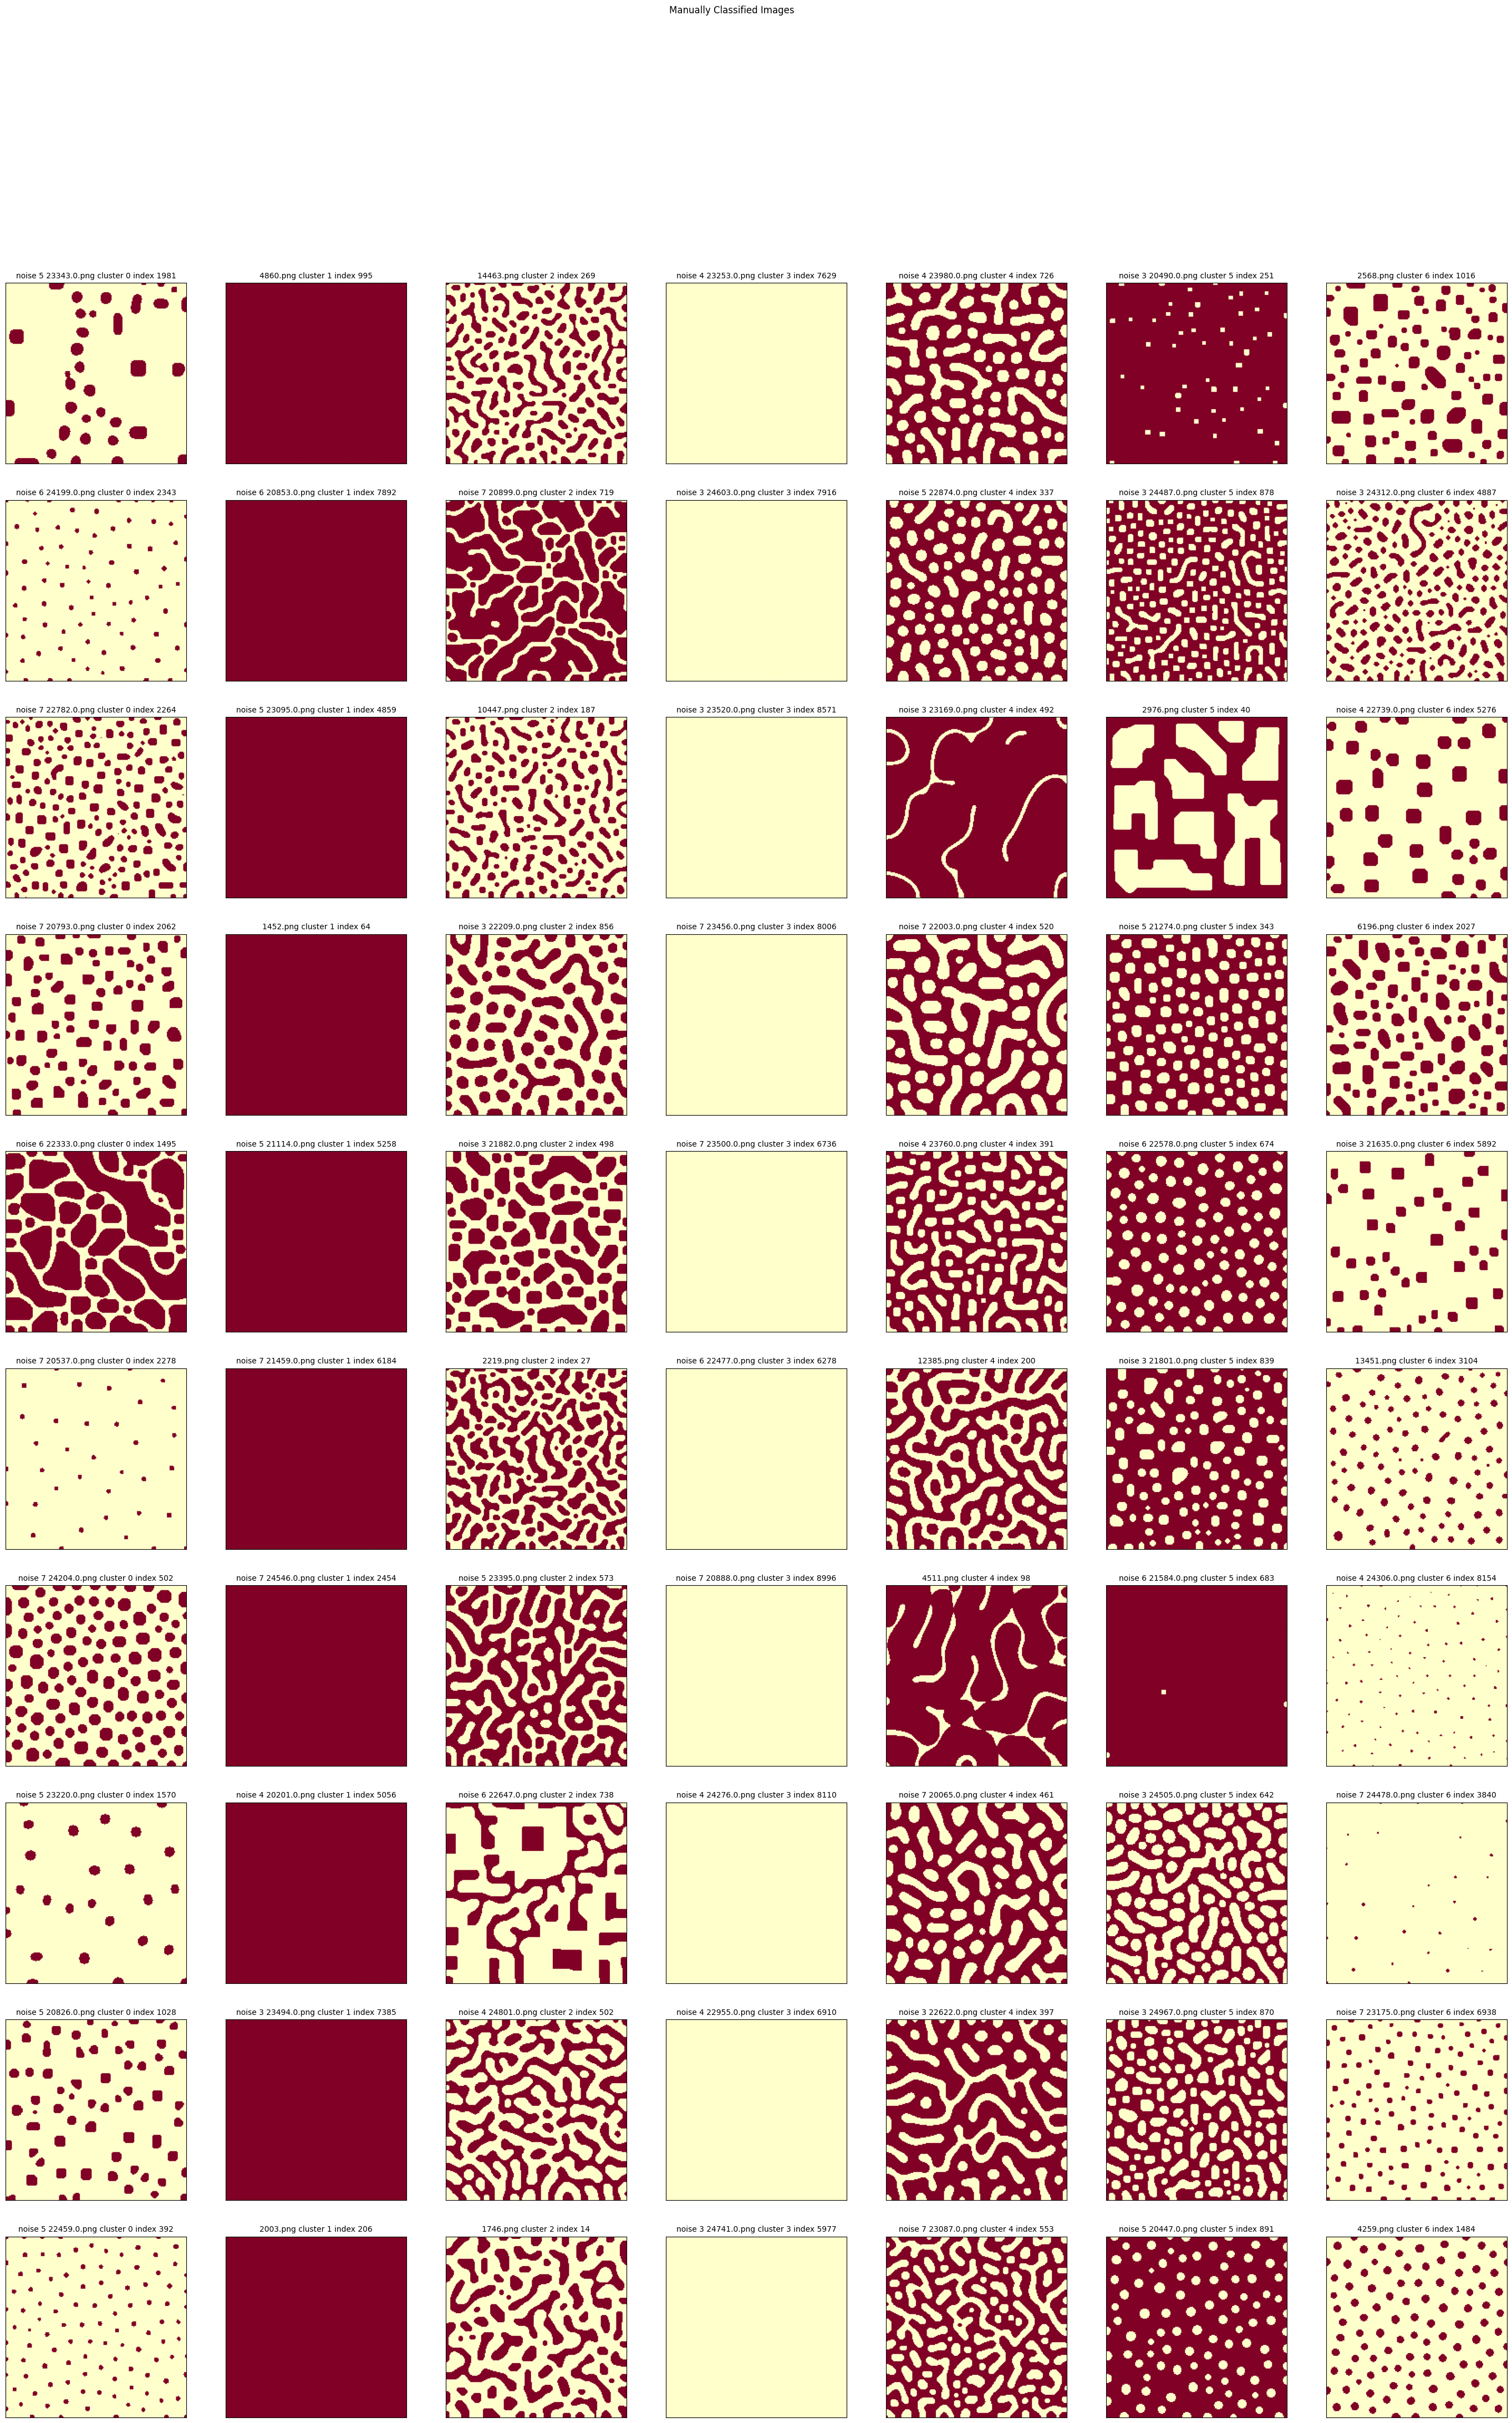

In [ ]:
num_imgs = 10

fig, ax = plt.subplots(num_imgs, len(class_dfs))
fig.suptitle('Manually Classified Images', fontsize=24)

for i in range(num_imgs):
  for j in range(len(class_dfs)):
    df = class_dfs[j]
    if df.shape[0] == 0:
      continue
    num = np.random.randint(low = 0, high= df.shape[0], size=1, dtype=int)[0]
    image_path = df["dir"][num] + df["path"][num]
    img = np.array(Image.open(image_path[1:]))
    ax[i][j].imshow(img, cmap = "YlOrRd", vmin = 0, vmax = 255)
    ax[i][j].set_title(df["path"][num] + " cluster " + str(j) + " index " + str(num), fontsize = 10)
    ax[i][j].get_xaxis().set_visible(False)
    ax[i][j].get_yaxis().set_visible(False)

fig.set_figwidth(5*len(class_dfs))
fig.set_figheight(5 * num_imgs)
plt.show()

In [13]:
# PCA on feat arrays

# scaling data
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()

# feat_array_scaled contain only features (no image data)
feat_array_scaled = pd.DataFrame(sc.fit_transform(feats_df[feats_df.columns[13:111]]))
print(feat_array_scaled.shape)

# Applying PCA function on training and testing set of X component
from sklearn.decomposition import PCA

pca = PCA(n_components = num_PCA_components)

pca_data = pca.fit_transform(feat_array_scaled)

explained_variance = pca.explained_variance_ratio_
print(explained_variance)

for j in range(num_PCA_components):
    feats_df["pc"+str(j+1)] = pca_data[:,j]

class_dfs = class_dfs.copy()
for i in range(num_classes):
    class_subset = feats_df[feats_df["cluster"] == i]
    for j in range(num_PCA_components):
        class_dfs[i]["pc" + str(j+1)] = class_subset["pc" + str(j+1)].values

# PCA components (loadings)
loadings = pd.DataFrame(pca.components_.T,
                        columns=[f'PC{i+1}' for i in range(len(pca.components_))],
                        index=feat_array_scaled.columns)

print("PCA Loadings:")
print(loadings)

# Find top features for each principal component
top_features = {}
for pc in loadings.columns:
    top_features[pc] = loadings[pc].abs().nlargest(3).index.tolist()  # Top 3 contributing features
print("\nTop Contributing Features per Principal Component:")
print(top_features)

for j in range(num_PCA_components):
    print("PC" + str(j+1)+ ":")
    for feat in top_features["PC"+str(j+1)]:
        print(f"----{feats_df.columns[feat + 13]}")


(33770, 98)
[0.40836246 0.25400039 0.08434093]
PCA Loadings:
         PC1       PC2       PC3
0   0.069040  0.144322  0.008581
1  -0.017278 -0.115261 -0.017555
2  -0.018570 -0.135003 -0.031067
3  -0.114576 -0.135845  0.016355
4   0.087308 -0.073634 -0.201826
..       ...       ...       ...
93  0.092078 -0.086008 -0.049677
94 -0.122192  0.105278  0.019828
95  0.124340 -0.112480  0.020556
96 -0.100587 -0.072567  0.016435
97  0.122978 -0.088004  0.071344

[98 rows x 3 columns]

Top Contributing Features per Principal Component:
{'PC1': [26, 45, 52], 'PC2': [25, 9, 58], 'PC3': [53, 79, 83]}
PC1:
----Circ._std
----Round_mean
----Area_inverted_mean
PC2:
----Circ._mean
----Perim._mean
----Perim._inverted_mean
PC3:
----Area_inverted_std
----IntDen_inverted_std
----RawIntDen_inverted_std


/var/folders/2l/987jsx797pb9xrgxhcngwht40000gn/T/ipykernel_30477/879248579.py:28: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  class_dfs[i]["pc" + str(j+1)] = class_subset["pc" + str(j+1)].values


In [ ]:
# will show PCA columns added to feats_df
feats_df.head()

,Ua,Ui,Ga,Gi,Ba,Da,Di,pattern,noise,path,seed,dir,feat_bool,num_spots,Mean,Median,Area_mean,Area_std,X_mean,X_std,Y_mean,Y_std,Perim._mean,Perim._std,BX_mean,BX_std,BY_mean,BY_std,Width_mean,Width_std,Height_mean,Height_std,Major_mean,Major_std,Minor_mean,Minor_std,Angle_mean,Angle_std,Circ._mean,Circ._std,Feret_mean,Feret_std,IntDen_mean,IntDen_std,%Area_mean,%Area_std,RawIntDen_mean,RawIntDen_std,FeretX_mean,FeretX_std,FeretY_mean,FeretY_std,FeretAngle_mean,FeretAngle_std,MinFeret_mean,MinFeret_std,AR_mean,AR_std,Round_mean,Round_std,Solidity_mean,Solidity_std,num_spots_inverted,Mean_inverted,Median_inverted,Area_inverted_mean,Area_inverted_std,X_inverted_mean,X_inverted_std,Y_inverted_mean,Y_inverted_std,Perim._inverted_mean,Perim._inverted_std,BX_inverted_mean,BX_inverted_std,BY_inverted_mean,BY_inverted_std,Width_inverted_mean,Width_inverted_std,Height_inverted_mean,Height_inverted_std,Major_inverted_mean,Major_inverted_std,Minor_inverted_mean,Minor_inverted_std,Angle_inverted_mean,Angle_inverted_std,Circ._inverted_mean,Circ._inverted_std,Feret_inverted_mean,Feret_inverted_std,IntDen_inverted_mean,IntDen_inverted_std,%Area_inverted_mean,%Area_inverted_std,RawIntDen_inverted_mean,RawIntDen_inverted_std,FeretX_inverted_mean,FeretX_inverted_std,FeretY_inverted_mean,FeretY_inverted_std,FeretAngle_inverted_mean,FeretAngle_inverted_std,MinFeret_inverted_mean,MinFeret_inverted_std,AR_inverted_mean,AR_inverted_std,Round_inverted_mean,Round_inverted_std,Solidity_inverted_mean,Solidity_inverted_std,pc1,pc2,cluster,pc3
0,0.025122,0.063822,0.071957,0.106327,-0.113131,0.009186,0.611871,1,2,1.png,1,/content/Images3/,1,70,5.489,0,12.300000,2.548669,99.395943,58.506181,97.530229,58.913237,12.282143,1.400962,97.371429,58.453442,95.528571,58.843551,4.071429,0.723512,4.057143,0.753766,4.245571,0.439294,3.664200,0.511781,55.108900,57.413924,0.958686,0.069883,4.926700,0.412294,3136.500000,649.910626,100.0,0.0,3136.500000,649.910626,97.942857,58.572760,96.014286,58.843981,120.129000,30.775307,3.653171,0.564778,1.177686,0.183575,0.866686,0.115368,0.879486,0.067138,1,249.511,255,39139.0,0.0,99.998,0.0,100.022,0.0,811.882,0.0,0.0,0.0,0.0,0.0,200.0,0.0,200.0,0.0,223.351,0.0,223.117,0.0,38.796,0.0,0.746,0.0,282.843,0.0,9980445.0,0.0,100.0,0.0,9980445.0,0.0,0.0,0.0,200.0,0.0,45.0,0.0,200.0,0.0,1.001,0.0,0.999,0.0,0.979,0.0,3.196009,6.000280,0,-0.583533
1,0.034475,0.059956,0.080798,0.100370,-0.132577,0.008852,0.854084,1,2,3.png,3,/content/Images3/,1,63,4.921,0,12.253968,2.569468,101.800571,59.297600,99.451270,58.953924,11.663270,1.365051,99.968254,59.323693,97.619048,58.964458,3.666667,0.534522,3.666667,0.534522,4.237317,0.401713,3.661714,0.572434,56.049556,60.605082,0.999619,0.003000,4.908365,0.491745,3124.761905,655.214389,100.0,0.0,3124.761905,655.214389,100.158730,59.330446,98.079365,59.017431,120.191190,32.406426,3.476190,0.613529,1.185032,0.226780,0.867667,0.127976,0.954905,0.046408,1,250.078,255,39228.0,0.0,99.992,0.0,100.015,0.0,809.255,0.0,0.0,0.0,0.0,0.0,200.0,0.0,200.0,0.0,223.524,0.0,223.451,0.0,72.380,0.0,0.753,0.0,282.843,0.0,10003140.0,0.0,100.0,0.0,10003140.0,0.0,0.0,0.0,0.0,0.0,135.0,0.0,200.0,0.0,1.000,0.0,1.000,0.0,0.981,0.0,2.398773,6.018919,6,-0.435916
2,0.028367,0.057912,0.073998,0.080784,-0.133789,0.008512,0.534244,1,2,7.png,7,/content/Images3/,1,77,4.692,0,9.558442,1.427863,100.557675,58.022388,98.103338,59.633687,10.379961,1.091819,98.870130,58.006796,96.519481,59.576560,3.402597,0.564300,3.194805,0.559196,3.806623,0.403173,3.196818,0.352550,29.220831,46.845042,0.992974,0.032896,4.416805,0.320359,2437.402597,364.105032,100.0,0.0,2437.402597,364.105032,98.961039,57.996292,96.753247,59.526521,133.450130,23.616781,2.961039,0.375951,1.209857,0.220792,0.849429,0.129524,0.946805,0.050966,1,250.308,255,39264.0,0.0,99.987,0.0,100.001,0.0,808.326,0.0,0.0,0.0,0.0,0.0,200.0,0.0,200.0,0.0,223.626,0.0,223.554,0.0,5.766,0.0,0.755,0.0,282.843,0.0,10012320.0,0.0,100.0,0.0,10012320.0,0.0,0.0,0.0,200.0,0.0,45.0,0.0,200.0,0.0,1.000,0.0,1.000,0.

In [ ]:
# plot the model predicted class in feature space
import plotly.graph_objects as go

feat_1 = "pc1"
feat_2 = "pc2"

alpha = [1,1,1,1,1,1,1]

if num_PCA_components == 2:
  fig, ax = plt.subplots()
  for j in classes:
    df = class_dfs[j]
    ax.scatter(df[feat_1], df[feat_2], c = colors[j], label = "class " + str(j), alpha = alpha[j])


  leg = ax.legend(loc="upper left")

  ax.set(xlabel = "PC1", ylabel = "PC2", title = "")
  plt.show()


if num_PCA_components == 3:
  class_dfs = [] # list of dfs for each cluster

  for i in classes:
    df = feats_df[feats_df["cluster"] == i]
    df.reset_index(inplace = True, drop = True)
    class_dfs.append(df)

  feat_3 = "pc3"

  traces = []

  for i, df in enumerate(class_dfs):
    color = colors[i]
    cur_alpha = alpha[i]
    
    trace = go.Scatter3d(x=df[feat_1],y=df[feat_2],z=df[feat_3], mode='markers',
        marker=dict(
            size=5,
            color=color,
            opacity=cur_alpha
        )
    )
    traces.append(trace)


  fig = go.Figure(data=traces)
  fig.update_layout(margin=dict(l=5, r=5, b=5, t=5))
  fig.update_layout(scene=dict(
          xaxis_title='PC1',
          yaxis_title='PC2',
          zaxis_title='PC3'
      ))
  fig.show()



Exploration of combos of points in 2D and 3D

In [ ]:
# plot the model predicted class in feature space

def plotter(feat_1,feat_2):
  fig, ax = plt.subplots()

  alpha = [1,1,1,1,1,1,0] # opacity of points
  for j in classes:
    df = class_dfs[j]
    ax.scatter(df[feat_1], df[feat_2], c = colors[j], label = "class " + str(j), alpha = alpha[j])


  leg = ax.legend(loc="upper left")

  ax.set(xlabel = feat_1, ylabel = feat_2)
  plt.show()

  return

seen_pair = []
for p1 in params:
  for p2 in params:
    if p1 != p2:
      if (p1,p2) in seen_pair or (p2,p1) in seen_pair:
        continue
      else:
        seen_pair.append((p1,p2))
        plotter(p1,p2)

In [ ]:
# do clusters in 3 parameters in 3D
from itertools import combinations

def threeD_plotter(feat_1,feat_2,feat_3):
    # Creating 3D figure
    fig = plt.figure(figsize=(8, 8))
    ax = plt.axes(projection='3d')

    alpha = [1,1,1,1,1,1,0]
    for j in classes:
      df = class_dfs[j]
      ax.scatter3D(df[feat_1], df[feat_2], df[feat_3], c = colors[j], label = "class " + str(j), alpha = alpha[j])


    leg = ax.legend(loc="upper left")

    ax.set(xlabel = feat_1, ylabel = feat_2, zlabel = feat_3)

    # 360 Degree view
    ax.view_init(30, 90)
    plt.show()

for p1,p2,p3 in combinations(params, 3):
  threeD_plotter(p1,p2,p3)

In [22]:
# plot ratios of params

def ratio_plotter(feat_1,feat_2):
  for p in range(num_classes):
    class_subset = feats_df[feats_df["cluster"] == p]
    for i in range(len(params)):
      for j in range(i,len(params)):
        for k in range(len(params)):
          for l in range(k,len(params)):
            p0 = params[i]
            p1 = params[j]
            p2 = params[k]
            p3 = params[l]
            if p0 != p1 and p1 != p2 and p2 != p3 and p1 != p3 and p0 != p3:
              class_dfs[p][p0 + "/" + p1] = class_subset[p0 + "/" + p1].values
              class_dfs[p][p2 + "/" + p3] = class_subset[p2 + "/" + p3].values

  fig, ax = plt.subplots()

  alpha = [1,0,1,1,1,1,0]
  for j in classes:
    df = class_dfs[j]
    ax.scatter(df[feat_1], df[feat_2], c = colors[j], label = "class " + str(j), alpha = alpha[j])


  leg = ax.legend(loc="upper left")

  ax.set(xlabel = feat_1, ylabel = feat_2)
  plt.show()

  return

plot=1
counter = 0
for i in range(len(params)):
  for j in range(i,len(params)):
    for k in range(len(params)):
      for l in range(k,len(params)):
        p0 = params[i]
        p1 = params[j]
        p2 = params[k]
        p3 = params[l]

        if p0 != p1 and p1 != p2 and p2 != p3 and p1 != p3 and p0 != p3:
          ratio_1 = np.array(feats_df[p0]) / np.array(feats_df[p1])
          feats_df[p0 + "/" + p1] = ratio_1

          ratio_2 = np.array(feats_df[p2]) / np.array(feats_df[p3])
          feats_df[p2 + "/" + p3] = ratio_2
          if plot:
            ratio_plotter(p0 + "/" + p1, p2 + "/" + p3)
          counter += 1
print(counter)

/var/folders/2l/987jsx797pb9xrgxhcngwht40000gn/T/ipykernel_30477/3738761266.py:15: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

/var/folders/2l/987jsx797pb9xrgxhcngwht40000gn/T/ipykernel_30477/3738761266.py:16: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



KeyError: 'Ua/Gi'

In [158]:
feats_df.columns[116:137]

Index(['Ua/Ga', 'Ua/Gi', 'Ua/Da', 'Ua/Di', 'Ua/Ba', 'Ga/Gi', 'Ga/Da', 'Ga/Di',
       'Ga/Ba', 'Gi/Da', 'Gi/Di', 'Gi/Ba', 'Da/Di', 'Da/Ba', 'Di/Ba', 'Ui/Gi',
       'Ui/Da', 'Ui/Di', 'Ui/Ba', 'Ui/Ga'],
      dtype='object')

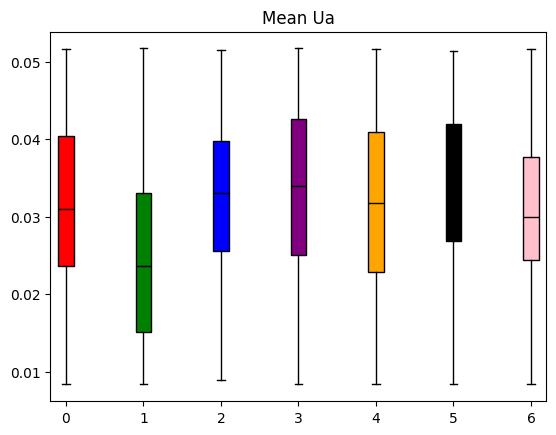

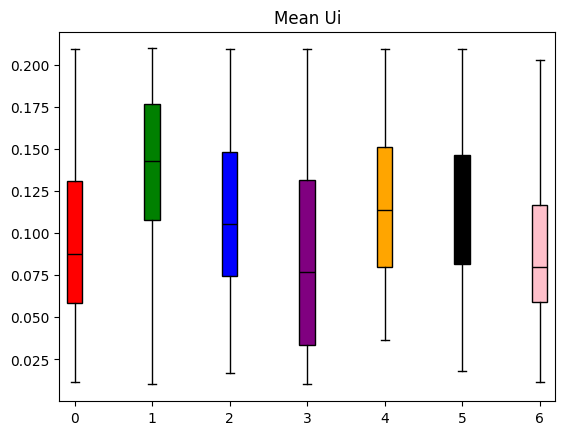

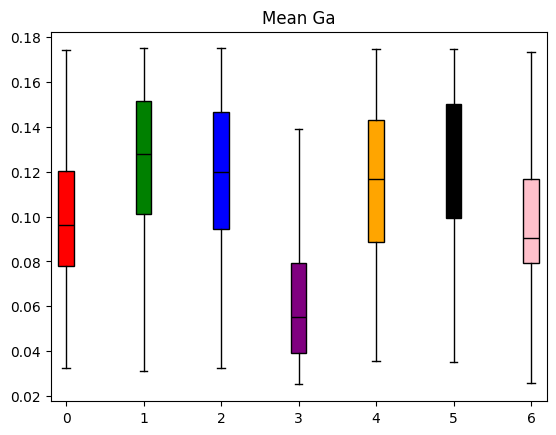

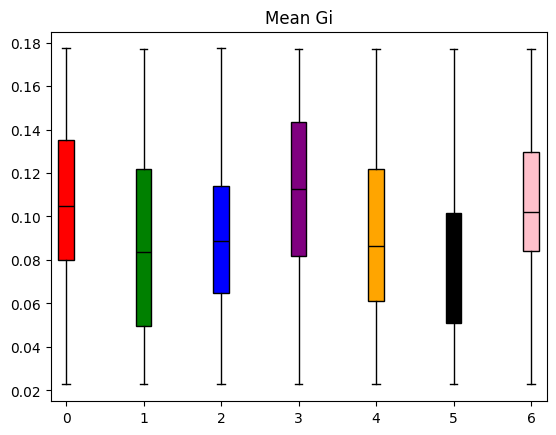

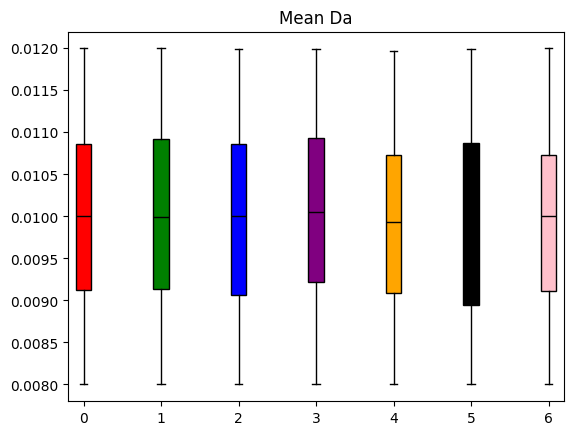

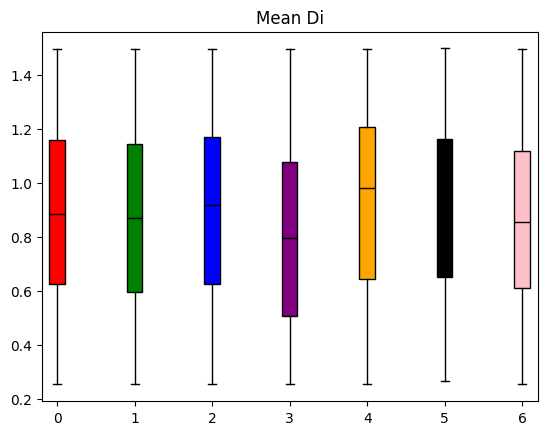

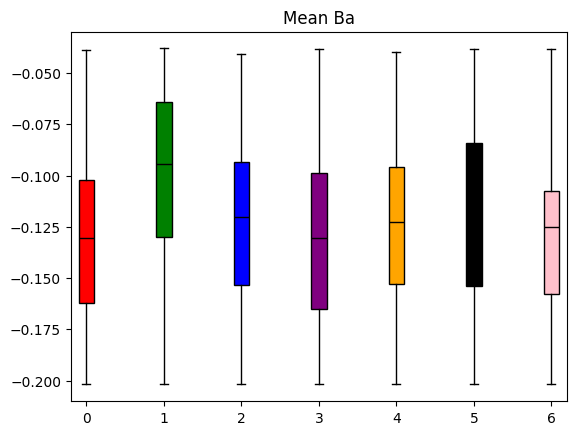

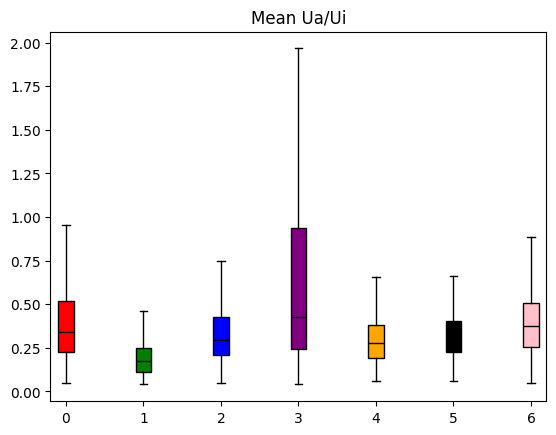

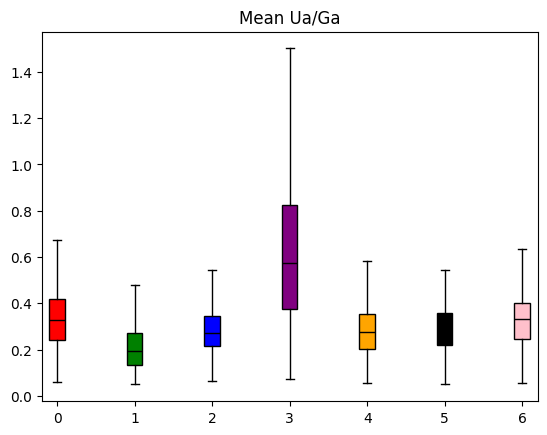

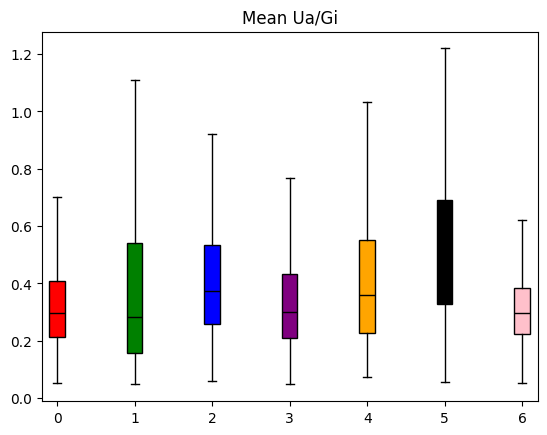

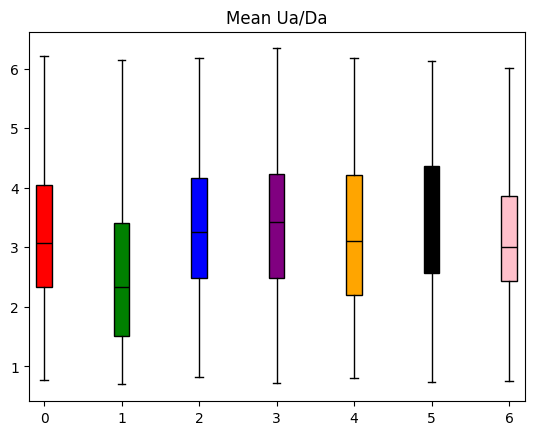

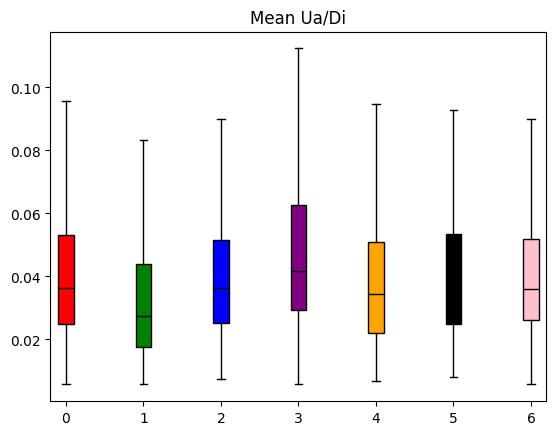

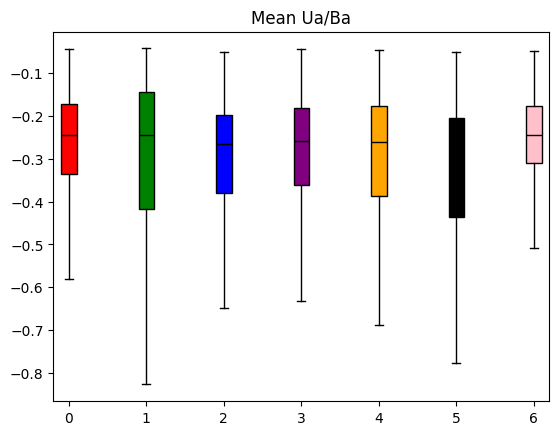

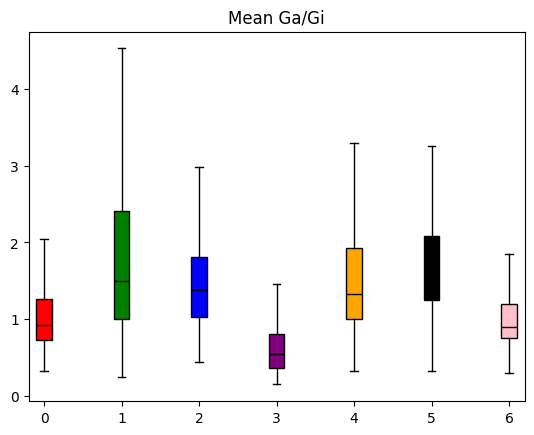

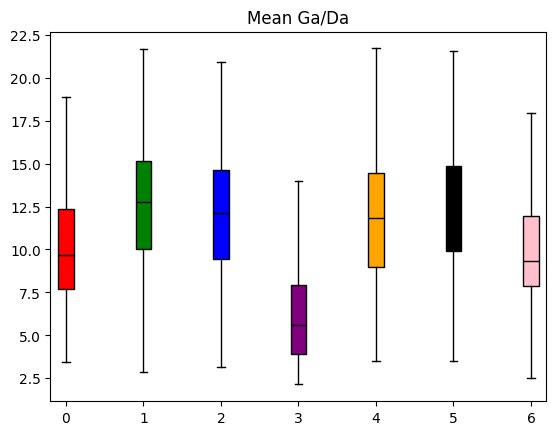

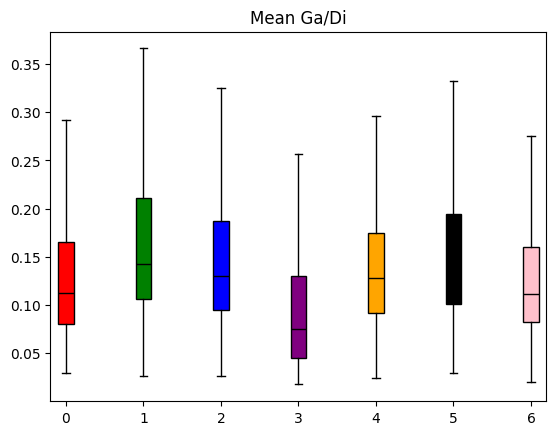

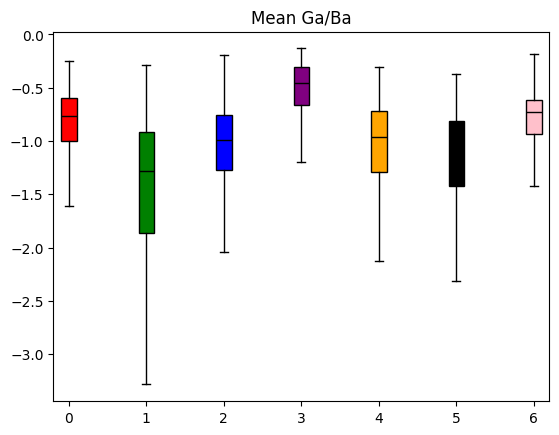

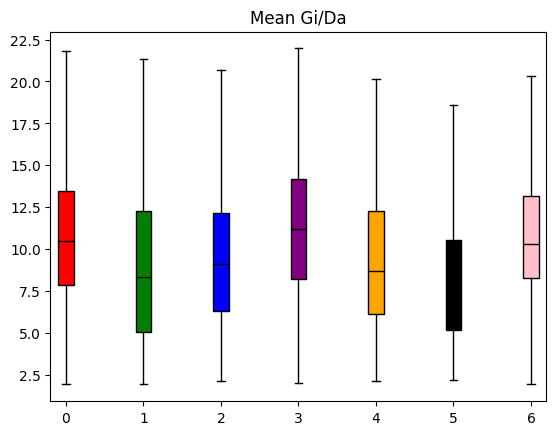

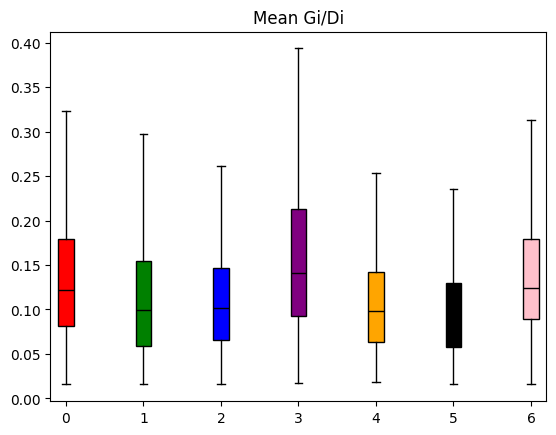

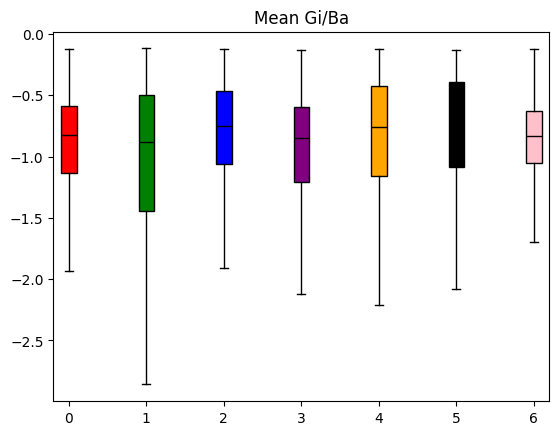

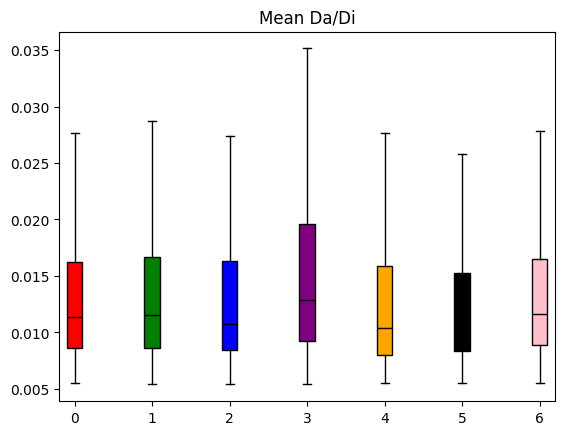

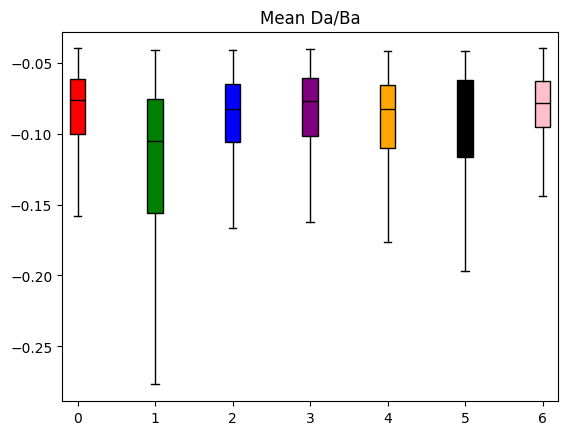

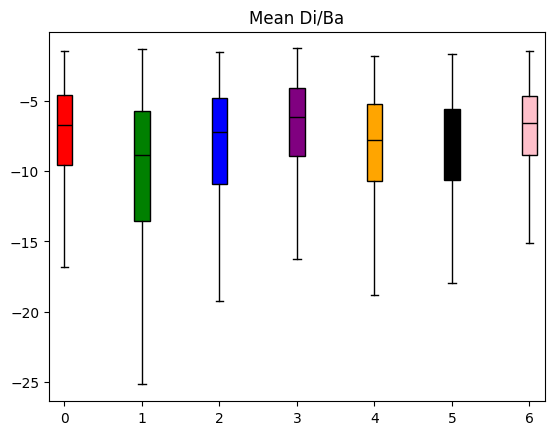

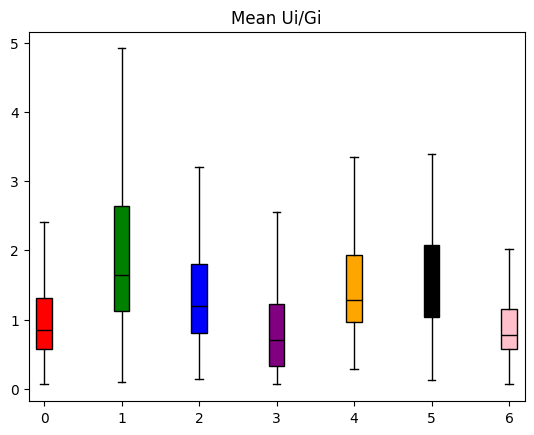

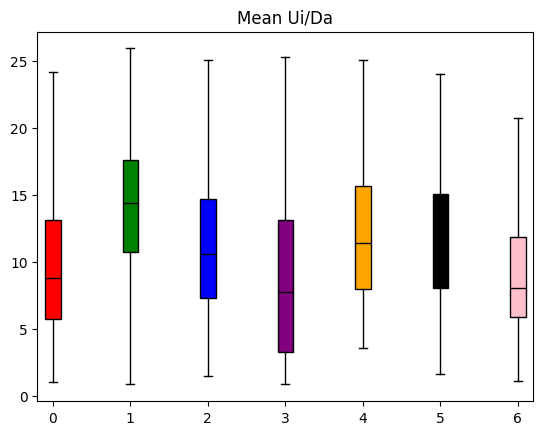

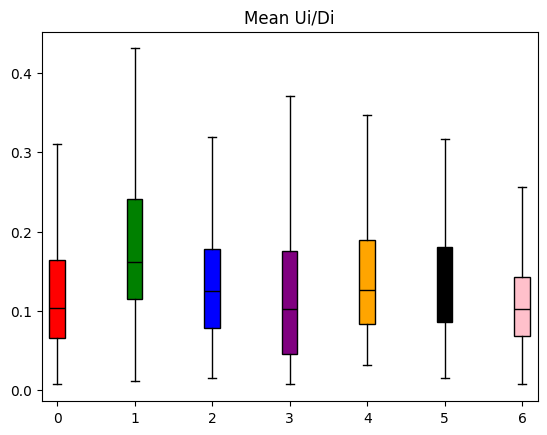

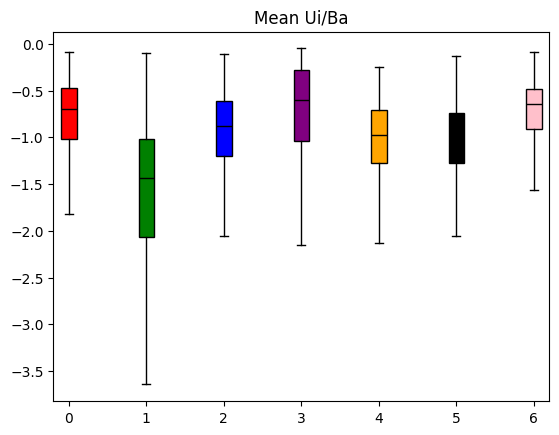

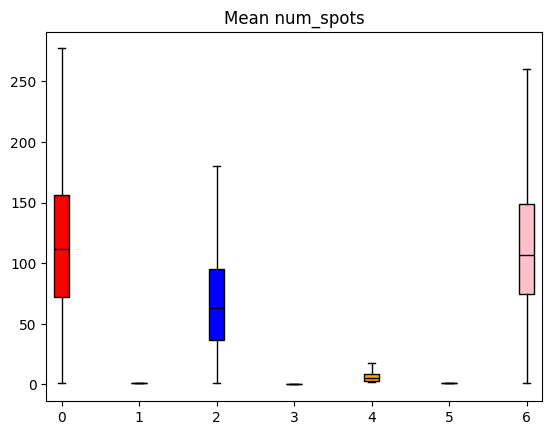

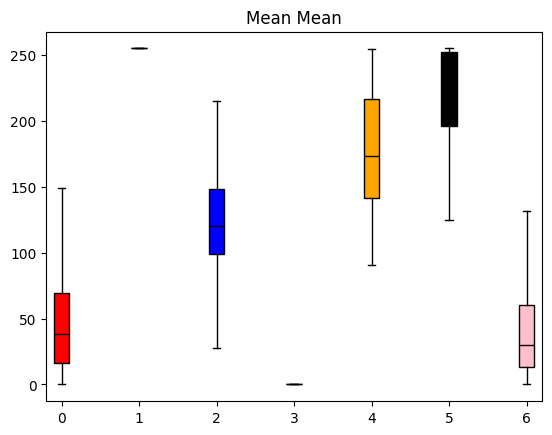

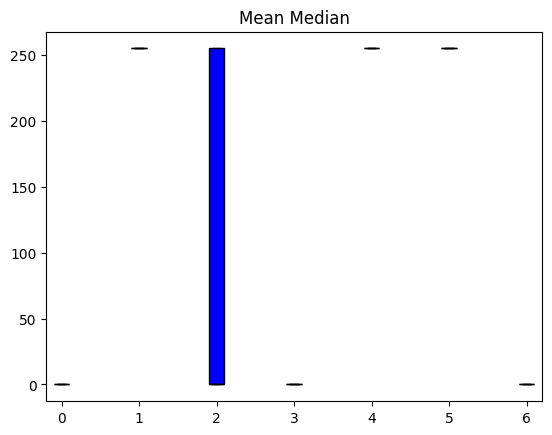

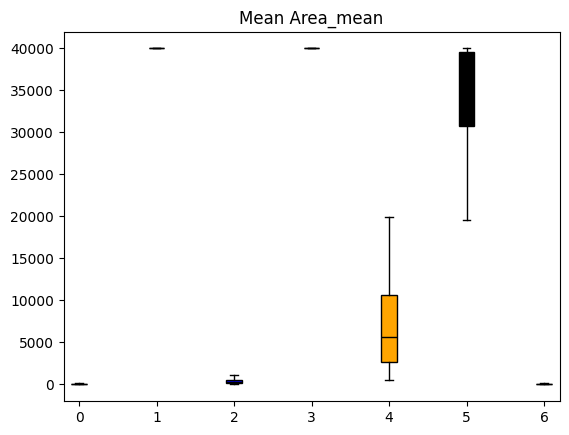

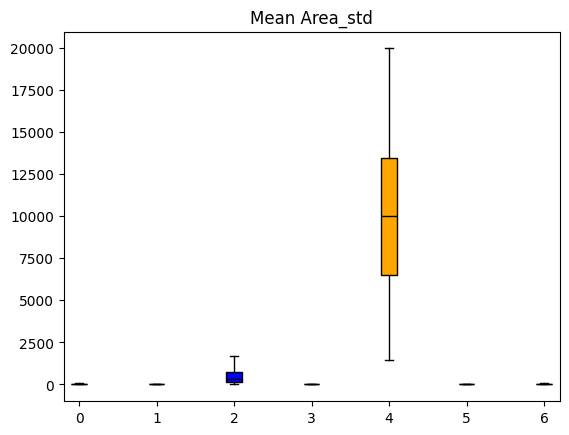

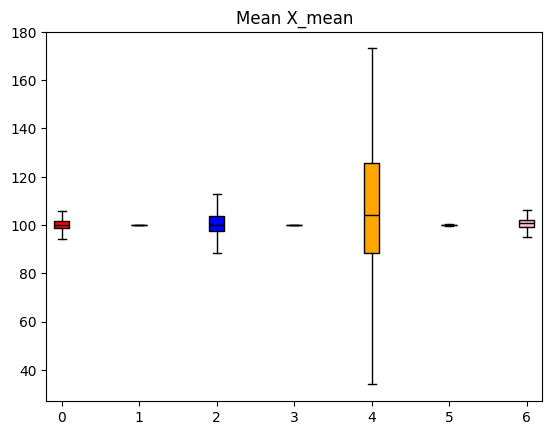

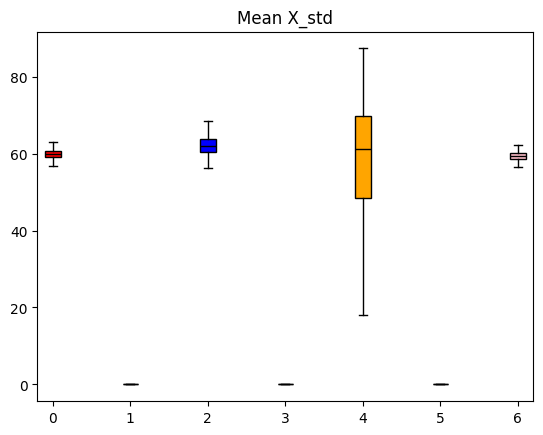

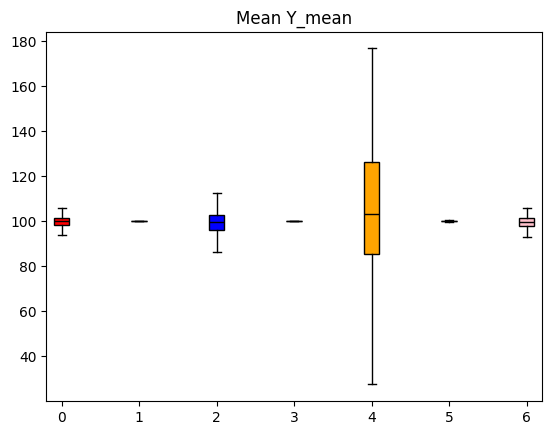

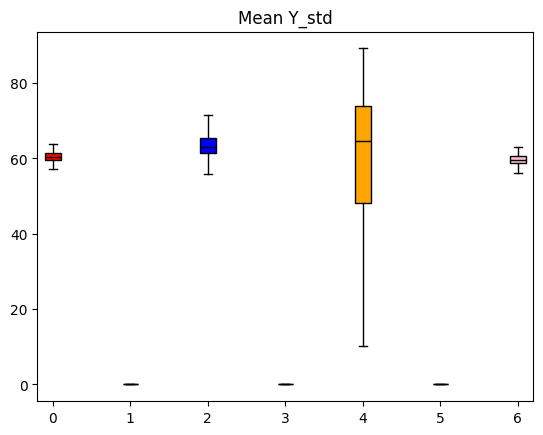

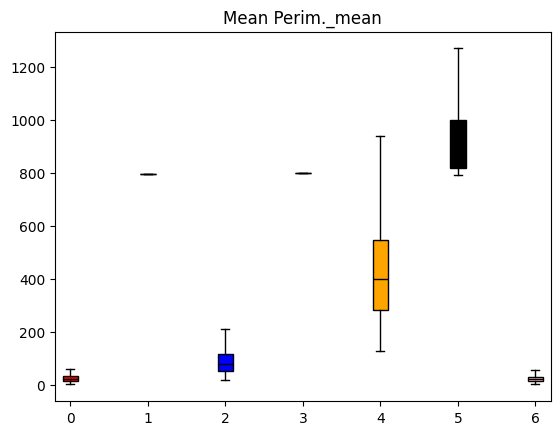

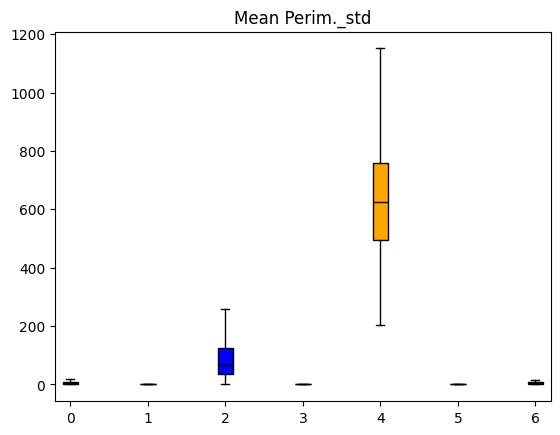

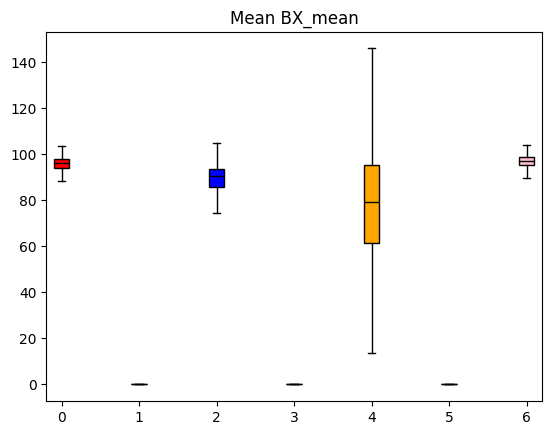

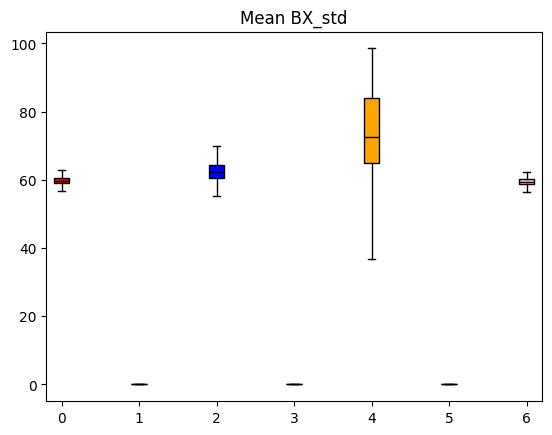

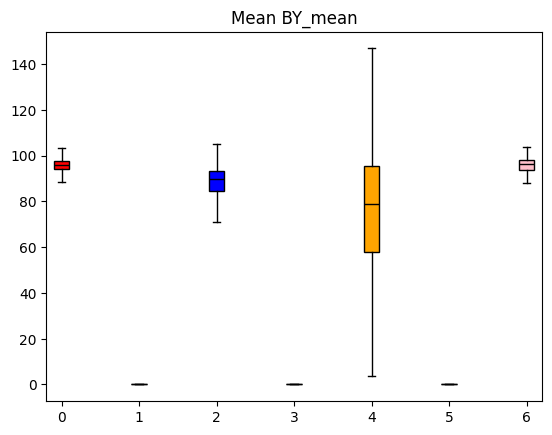

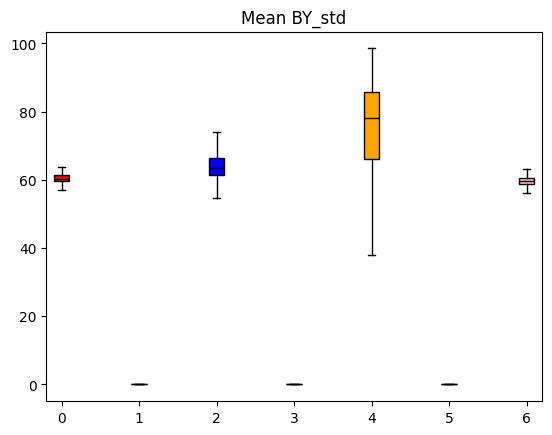

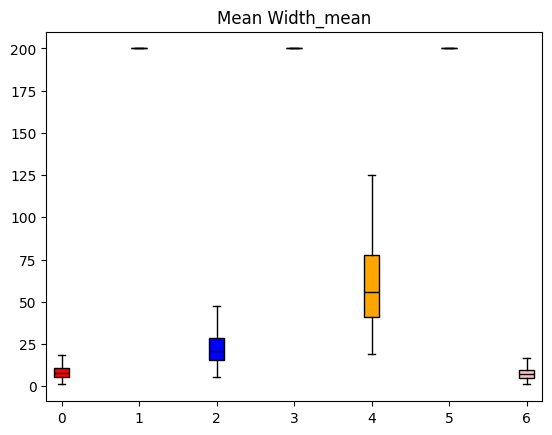

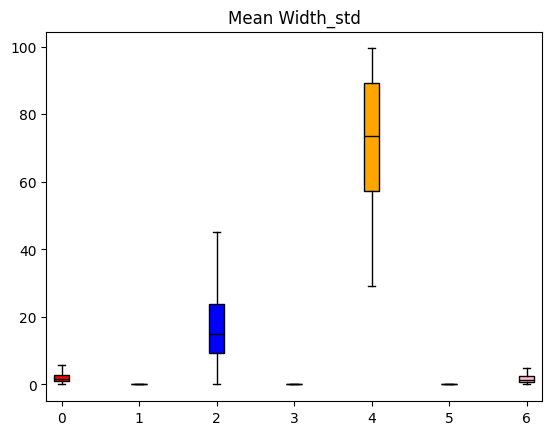

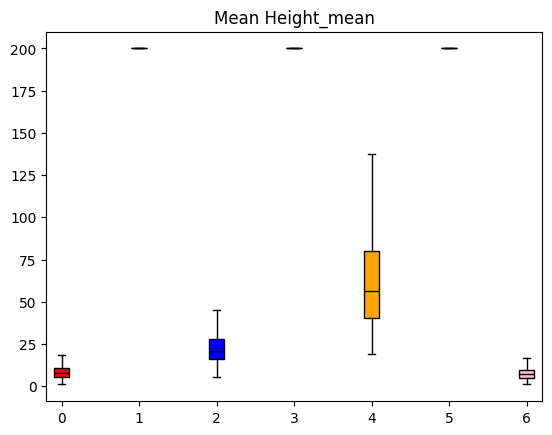

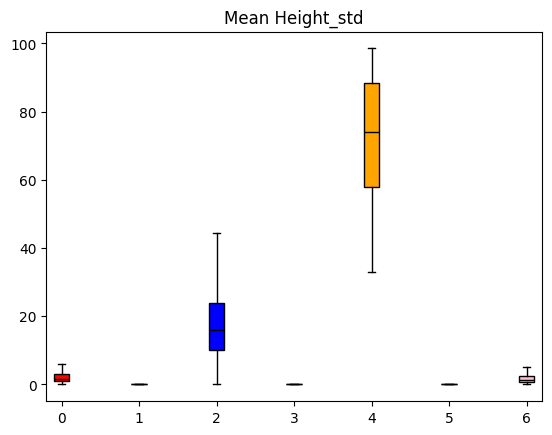

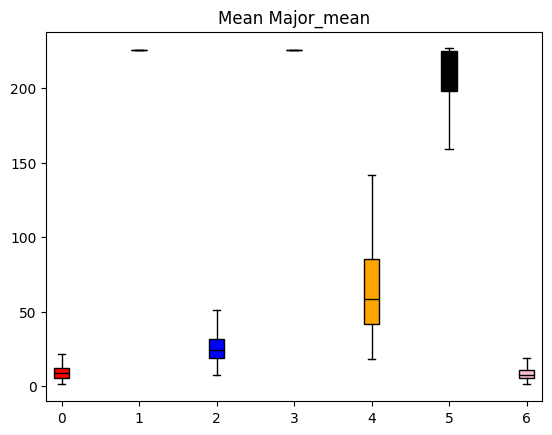

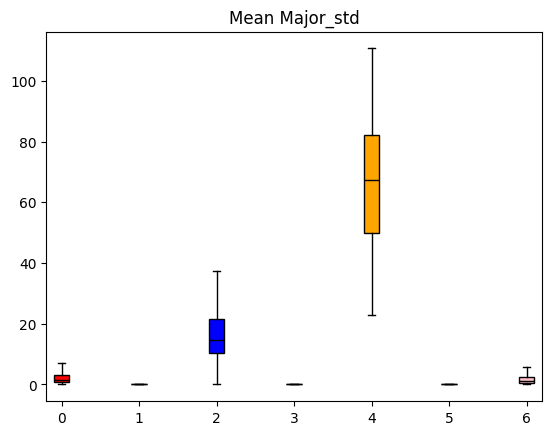

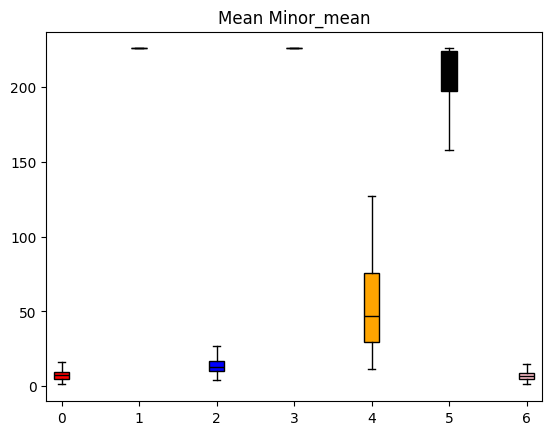

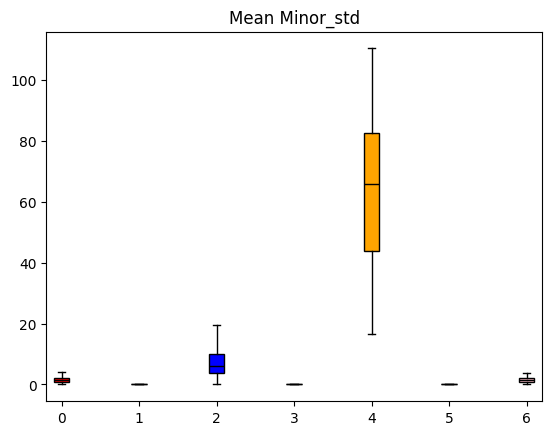

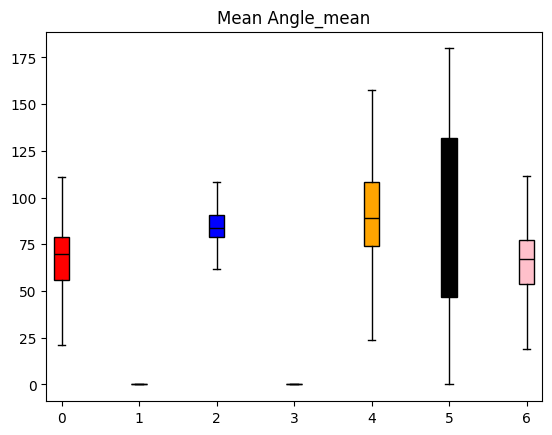

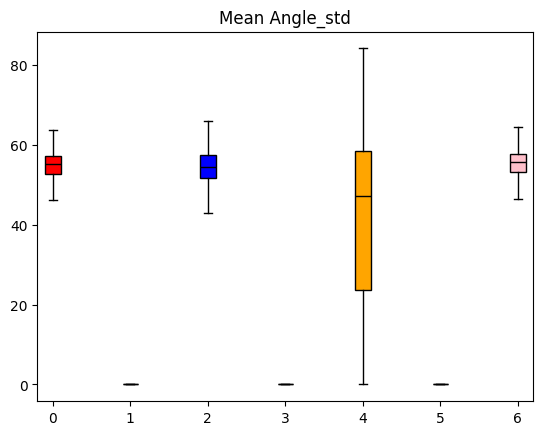

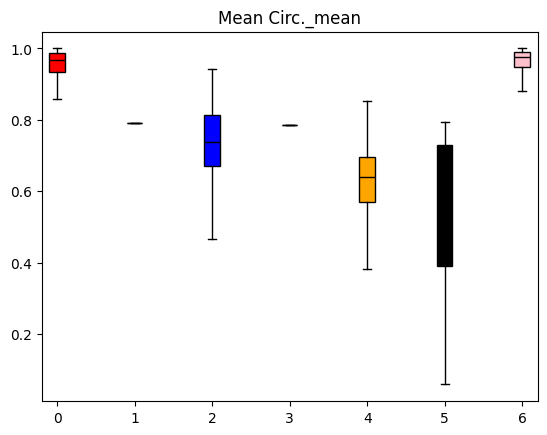

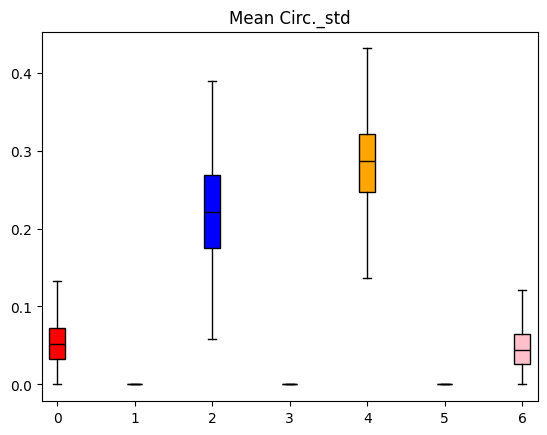

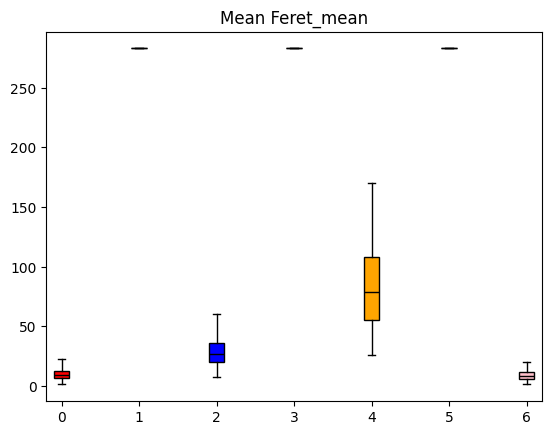

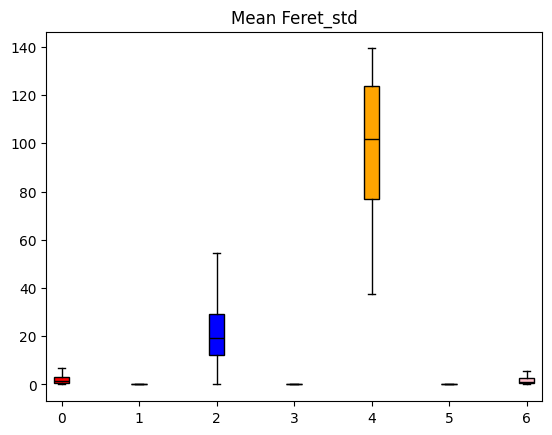

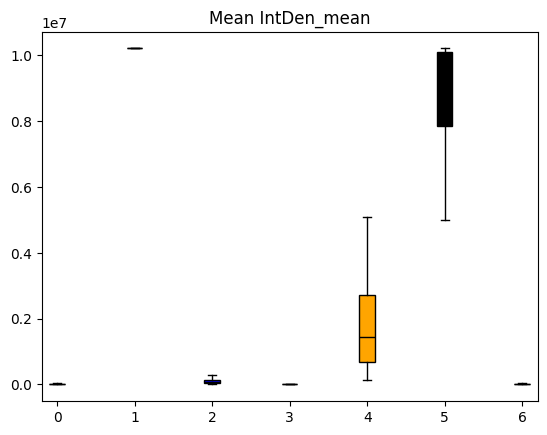

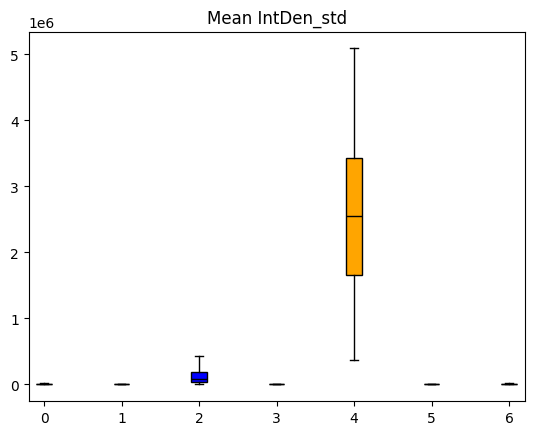

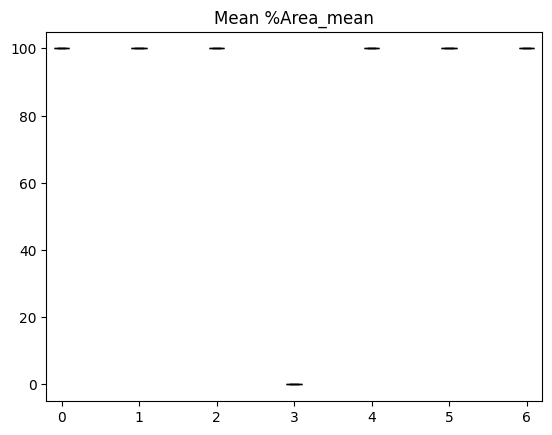

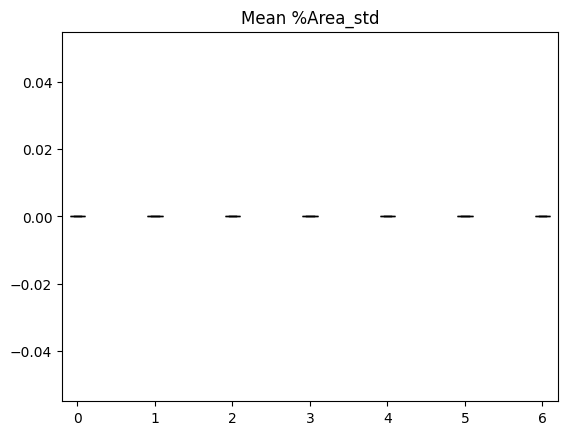

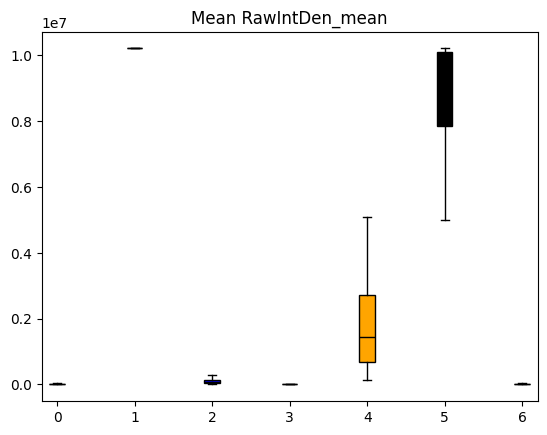

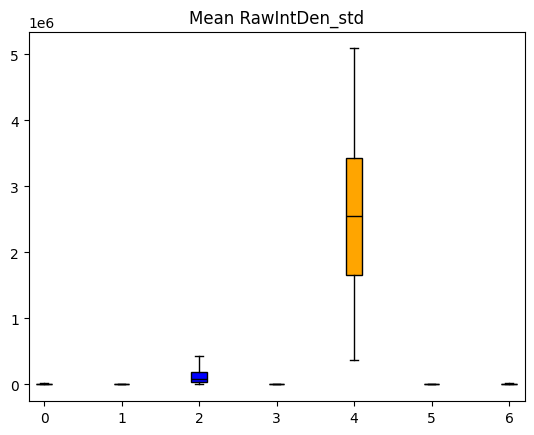

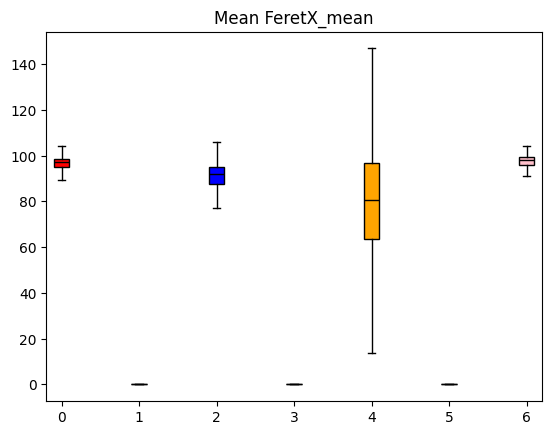

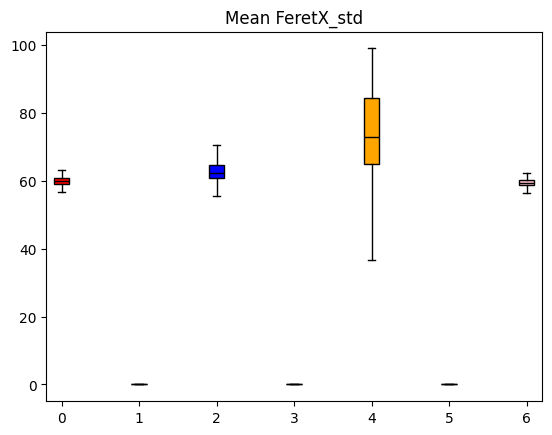

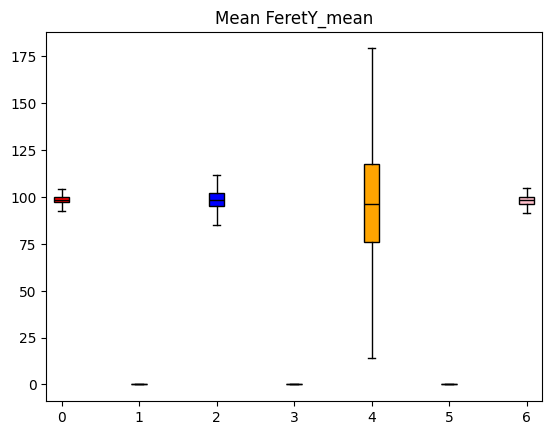

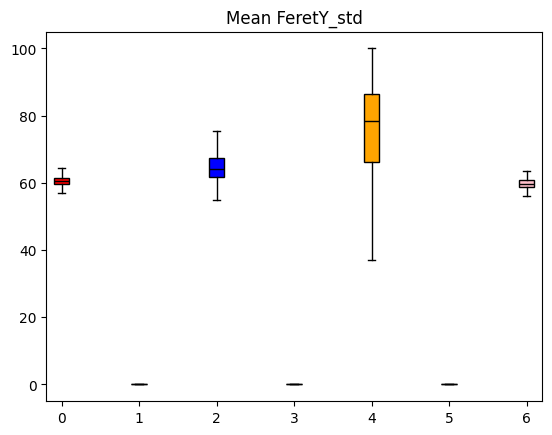

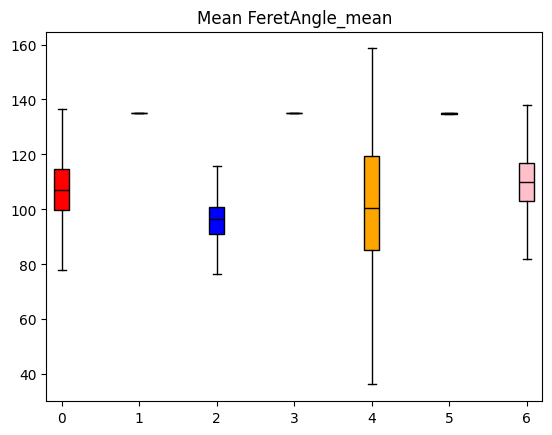

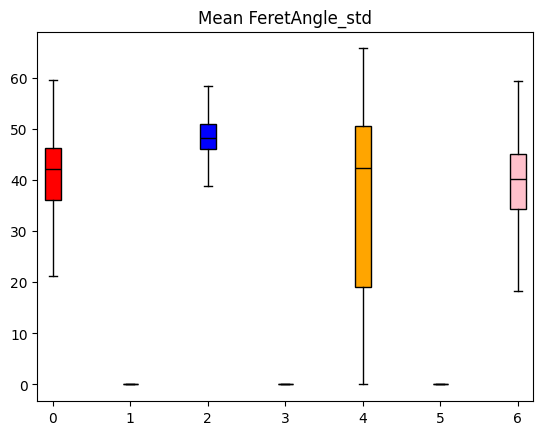

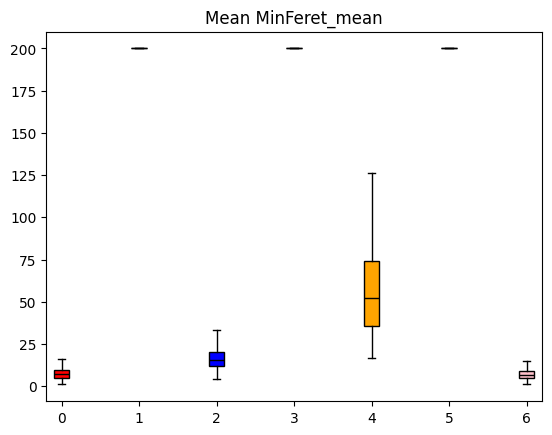

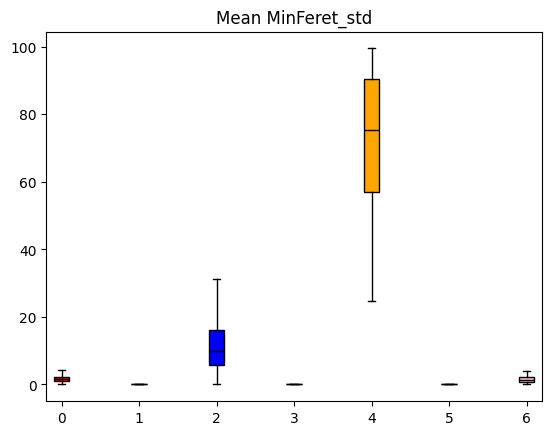

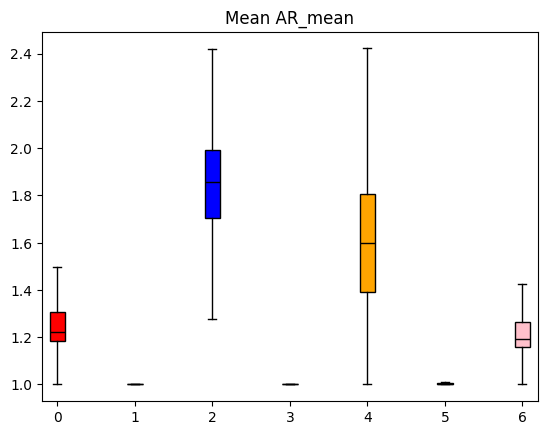

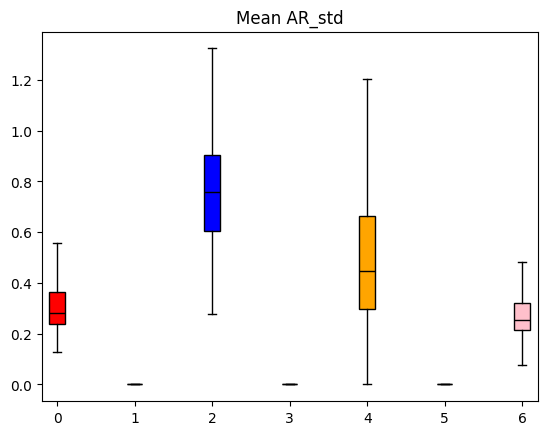

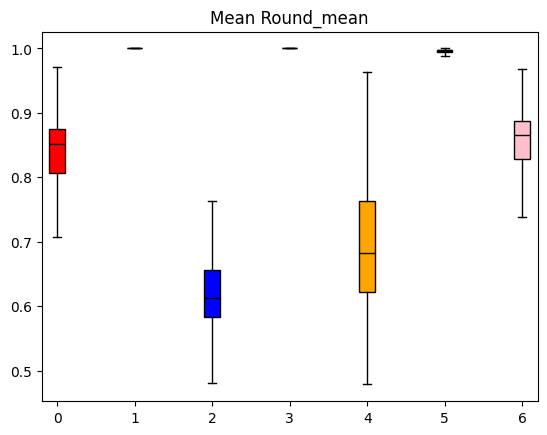

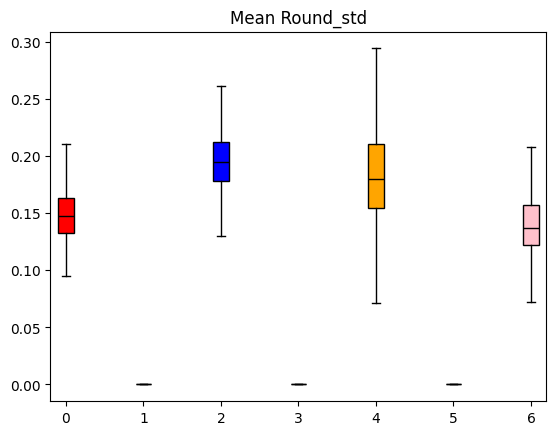

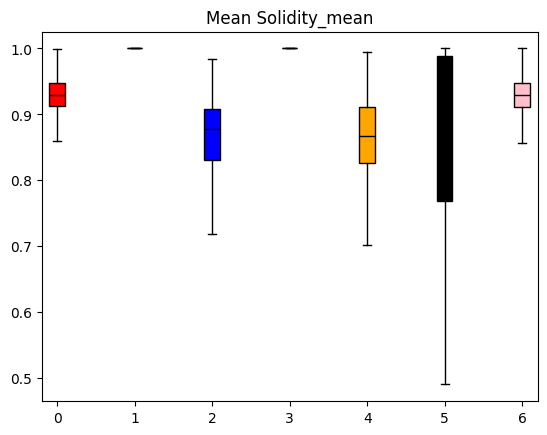

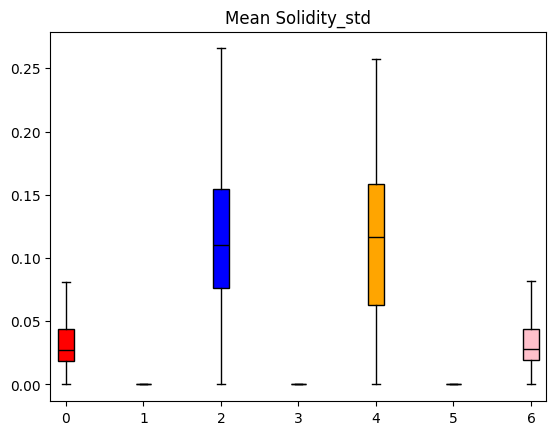

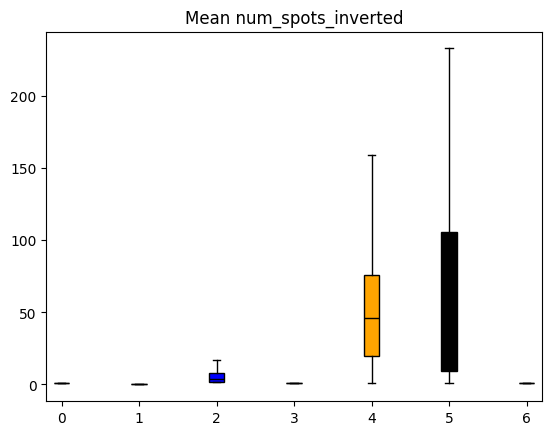

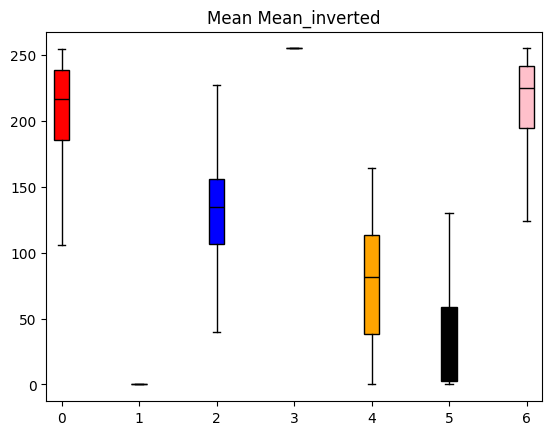

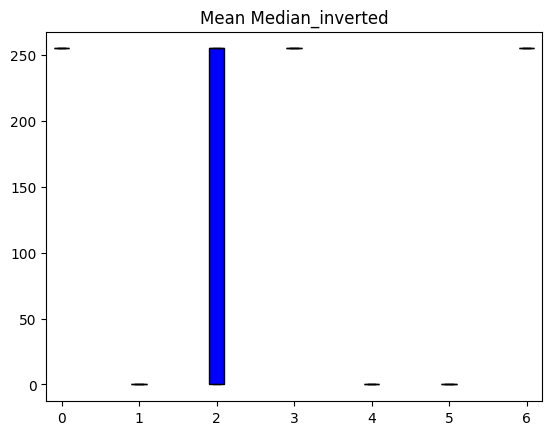

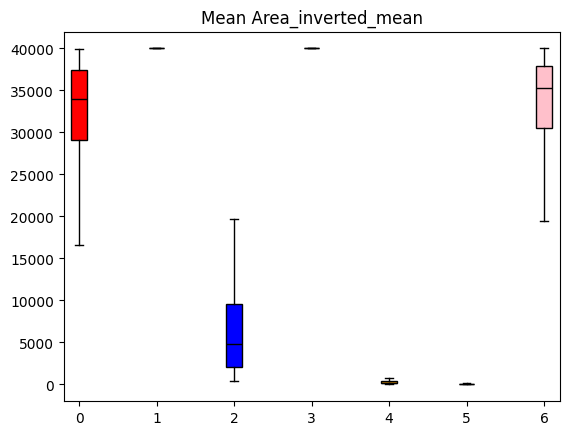

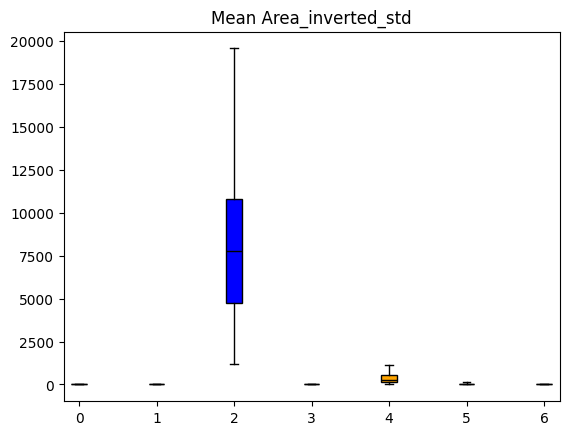

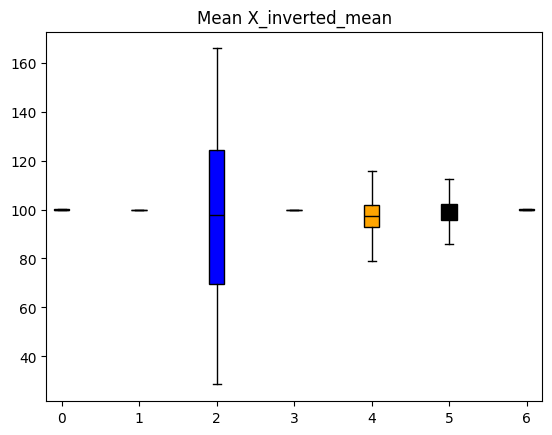

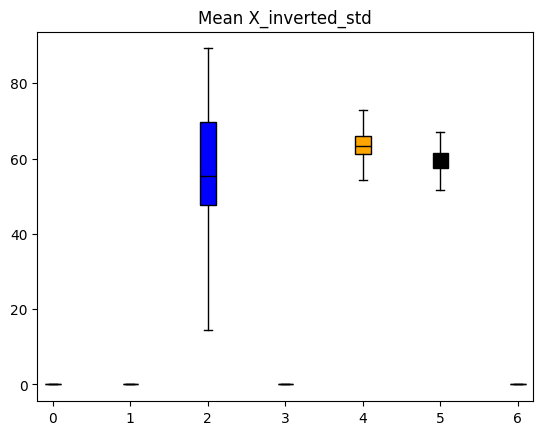

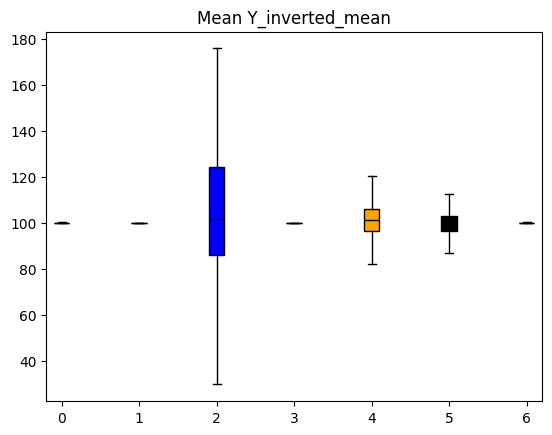

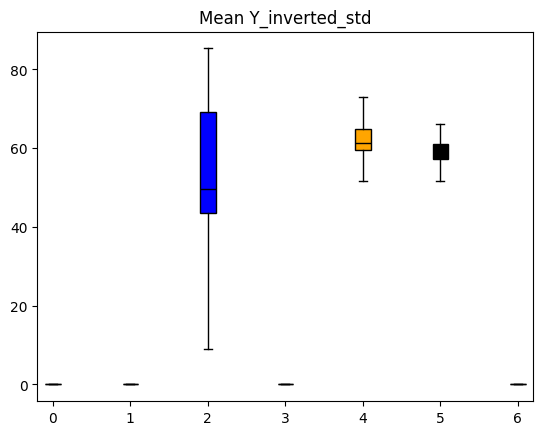

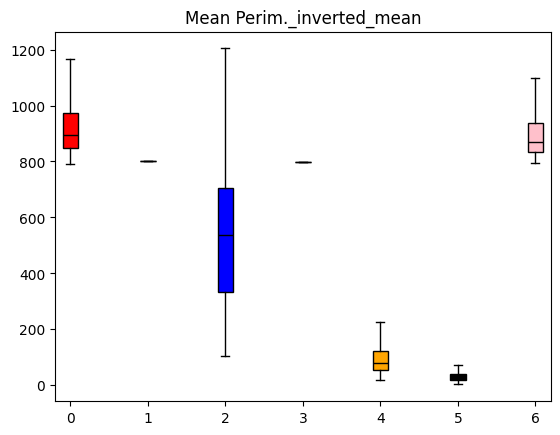

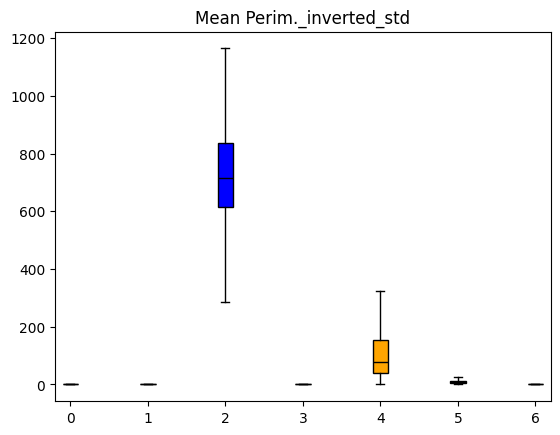

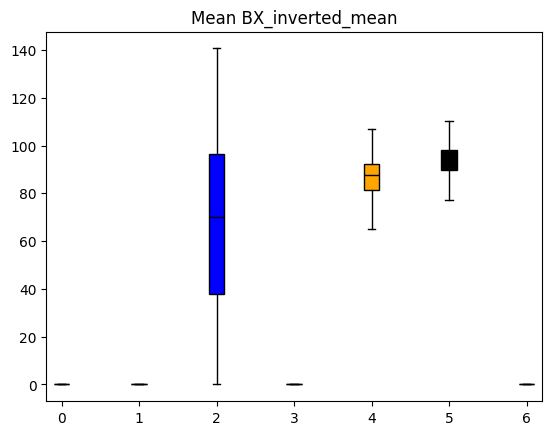

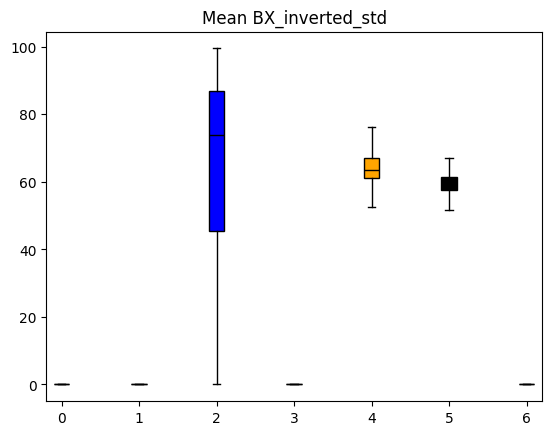

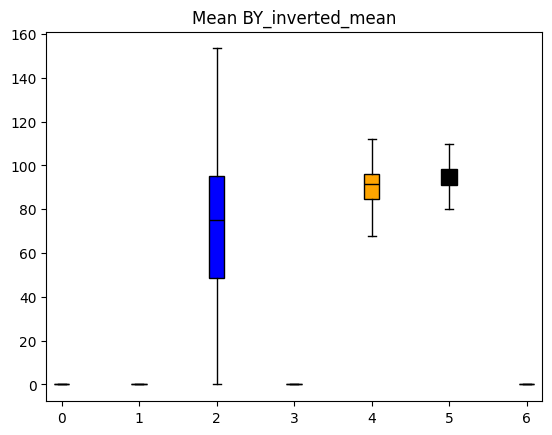

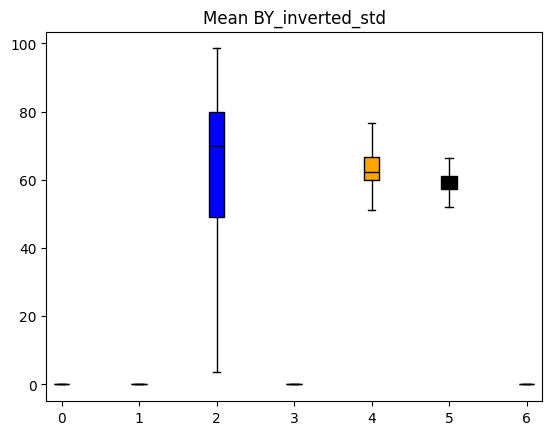

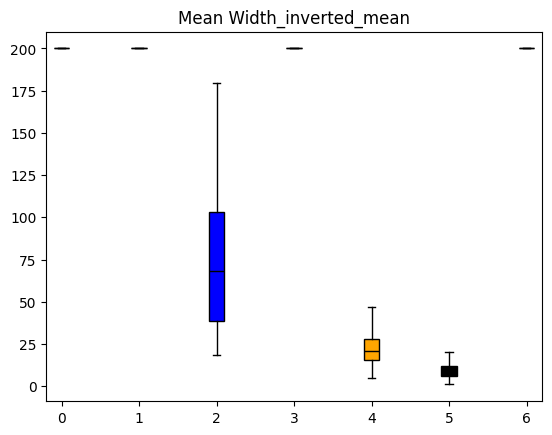

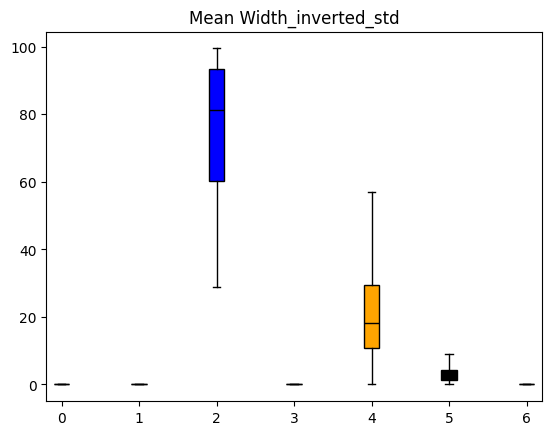

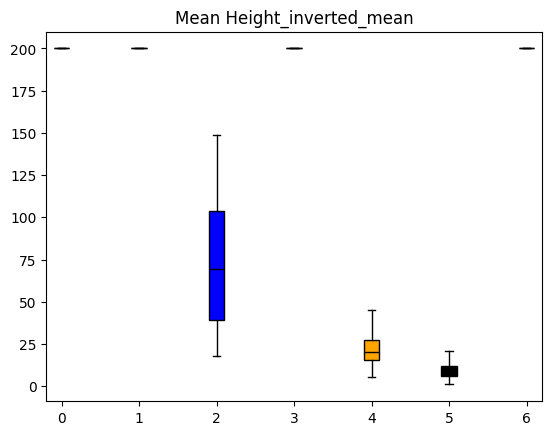

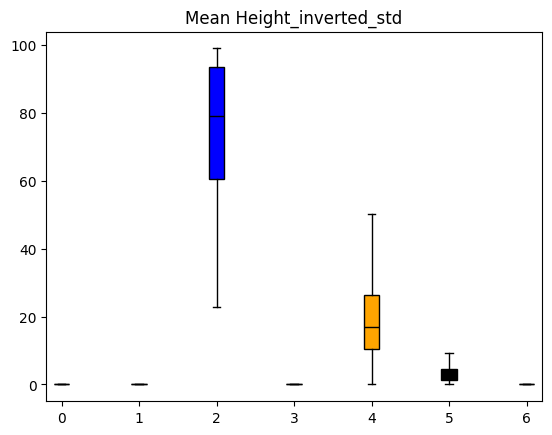

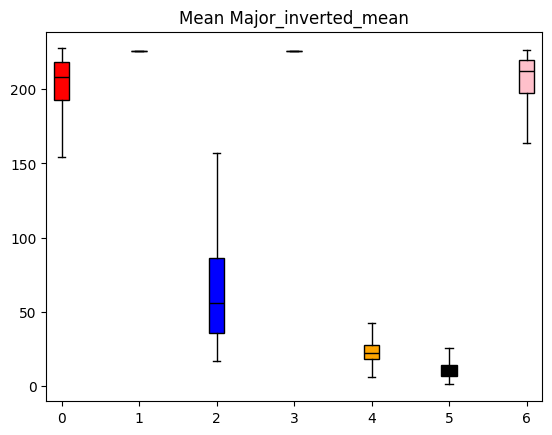

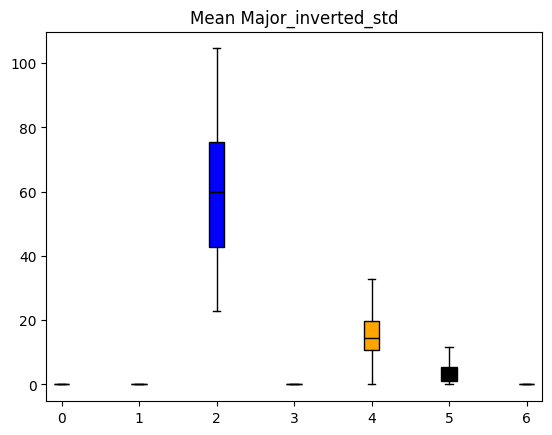

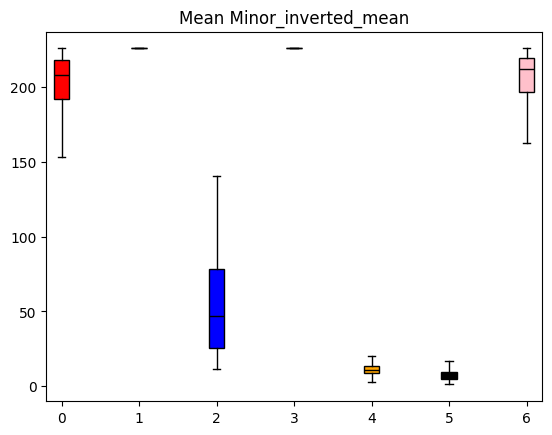

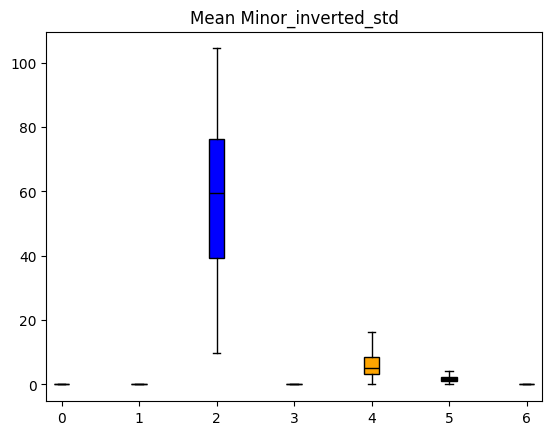

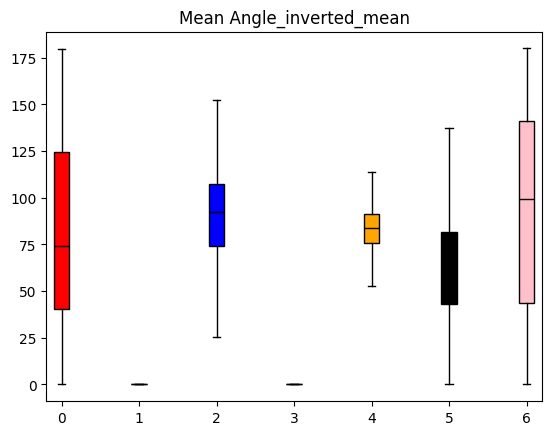

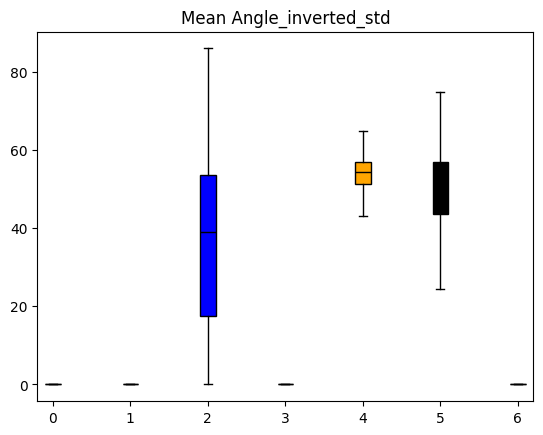

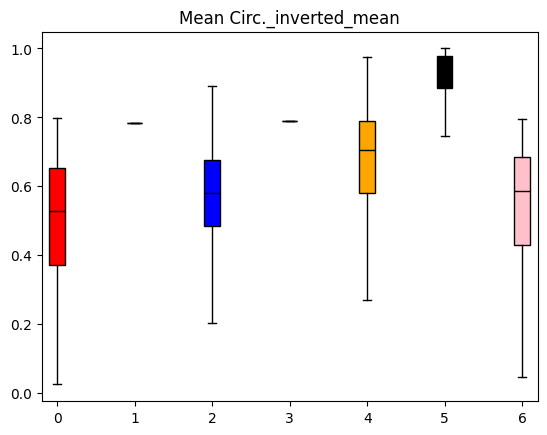

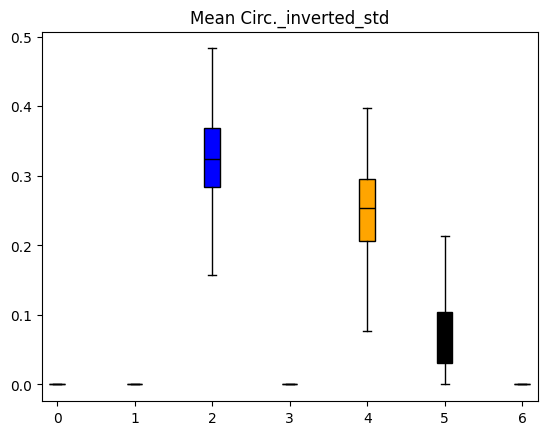

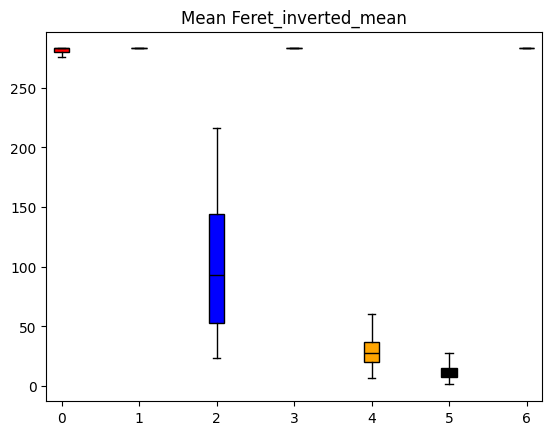

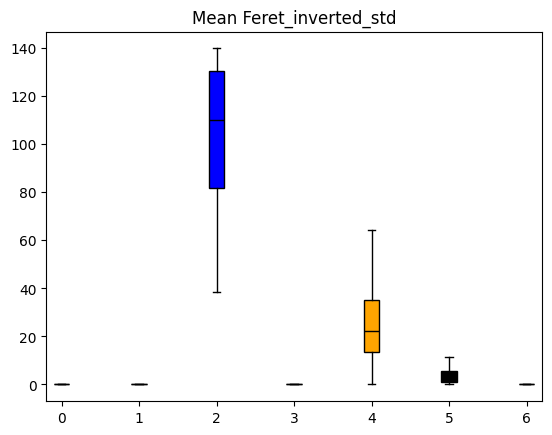

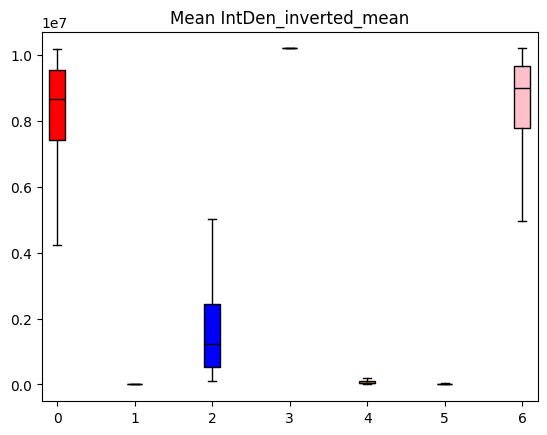

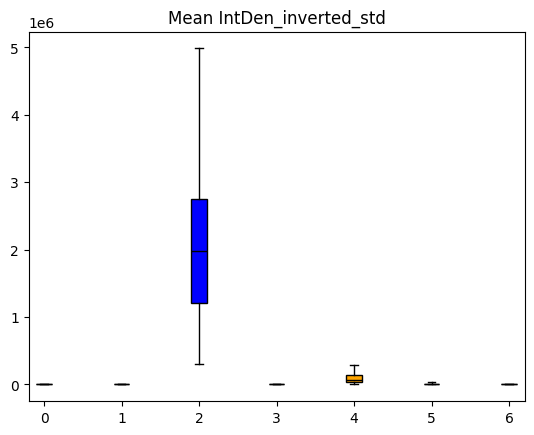

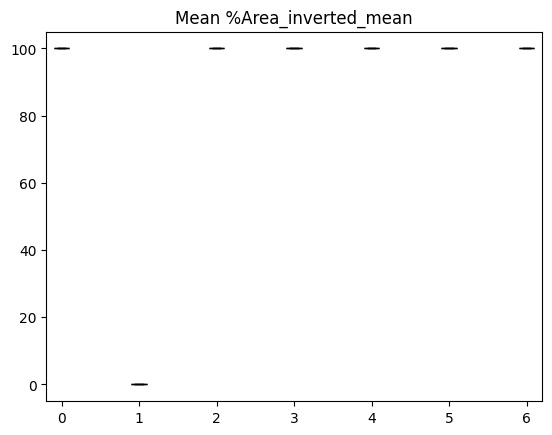

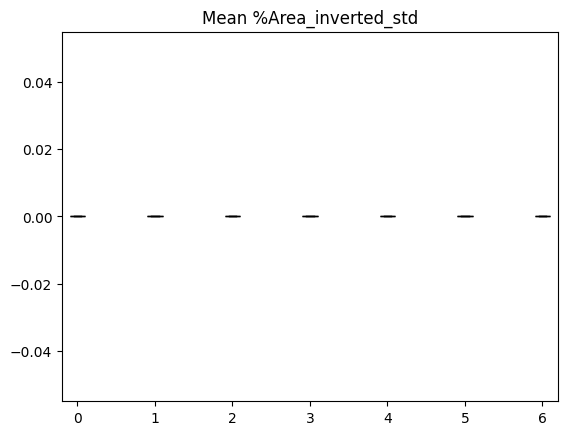

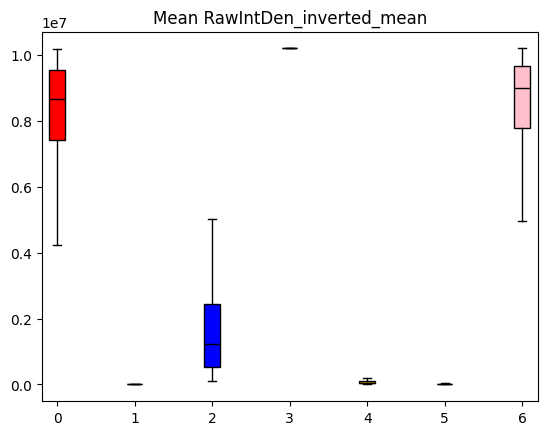

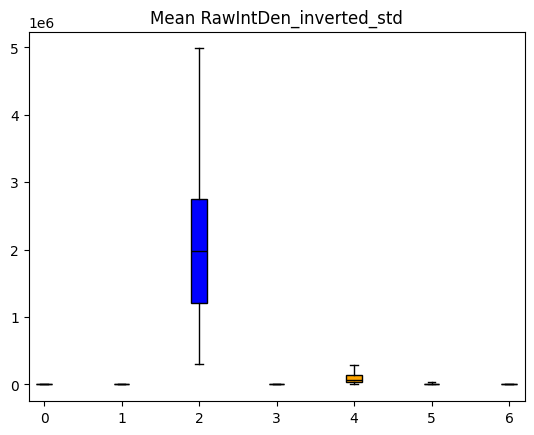

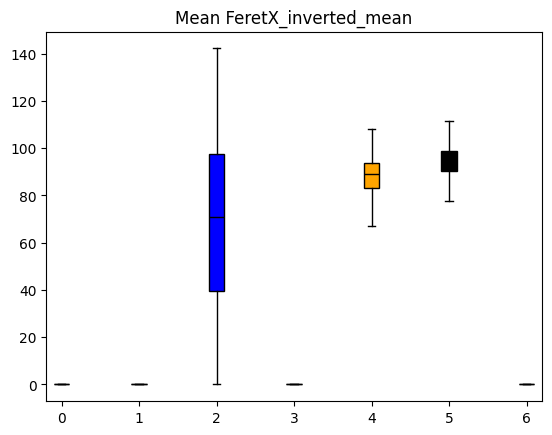

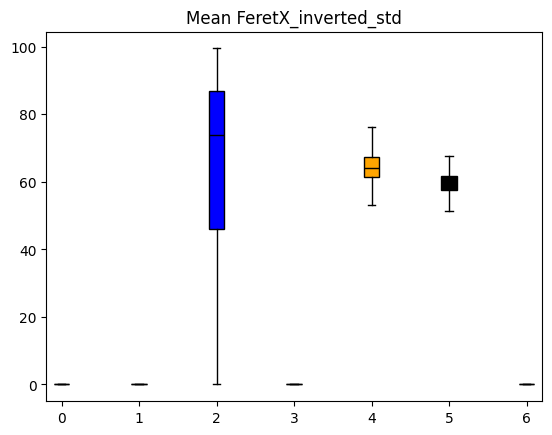

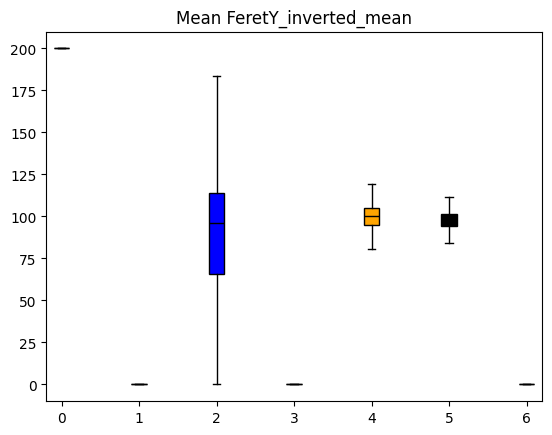

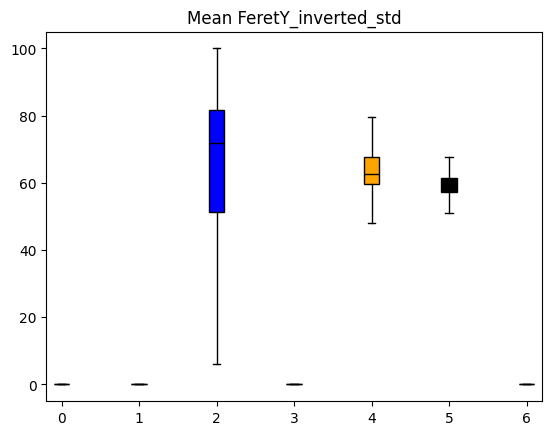

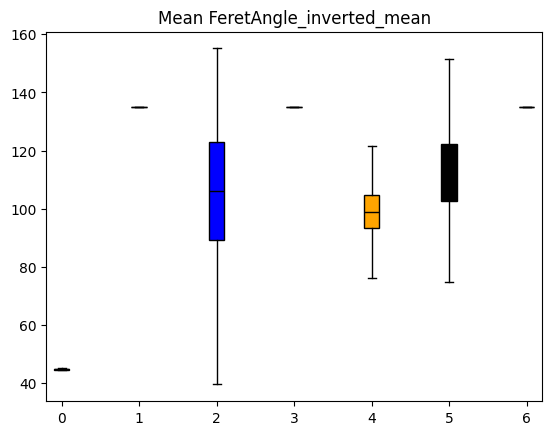

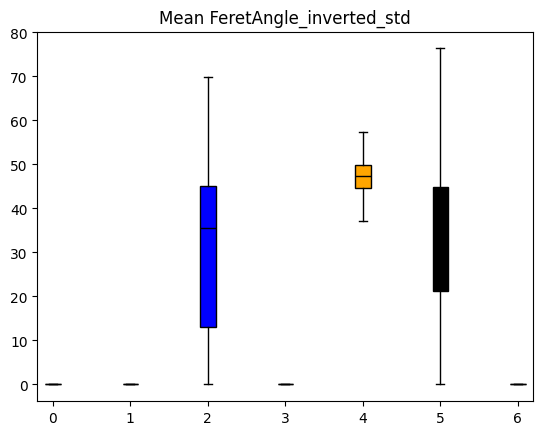

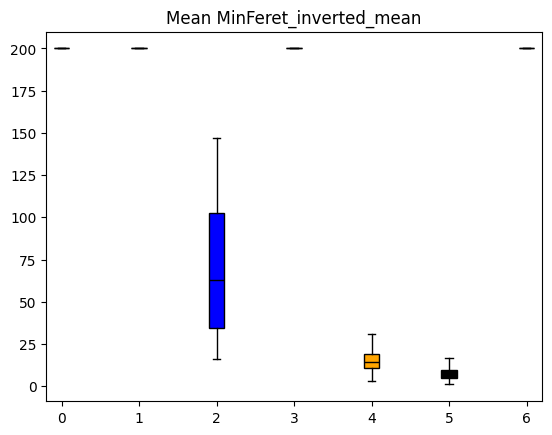

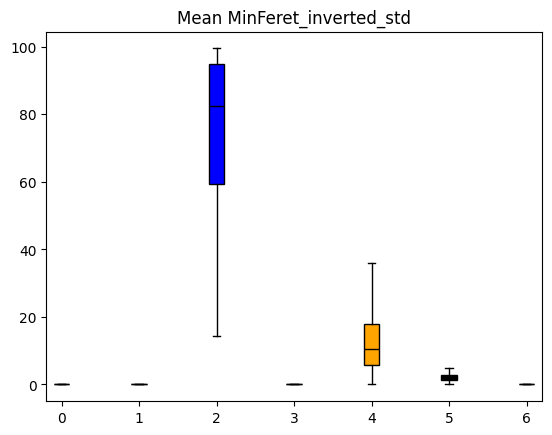

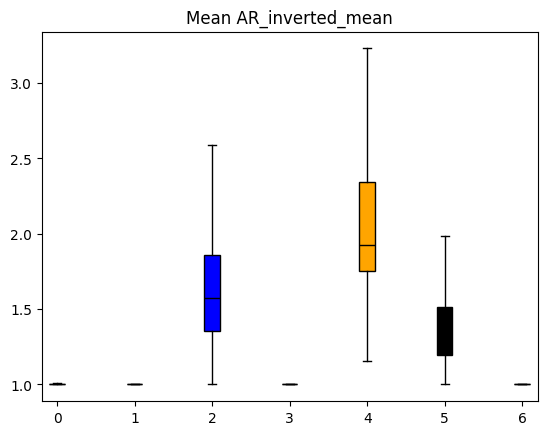

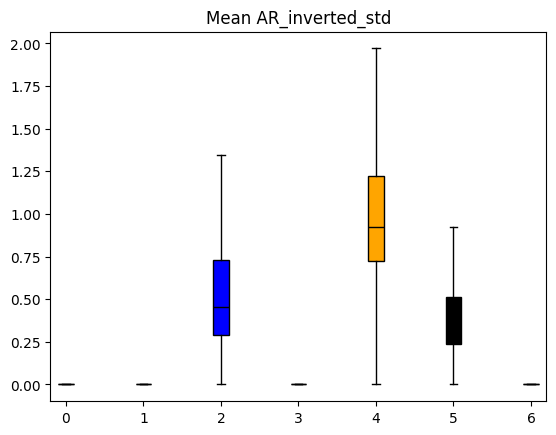

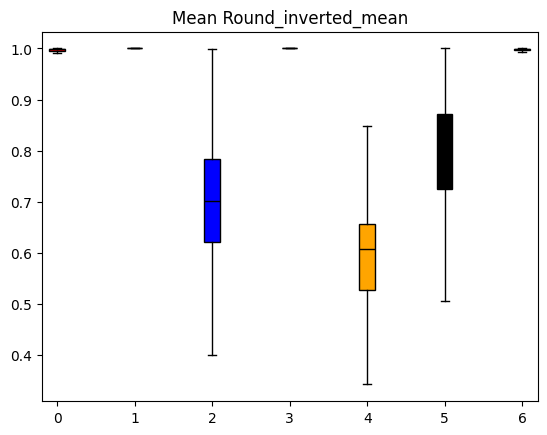

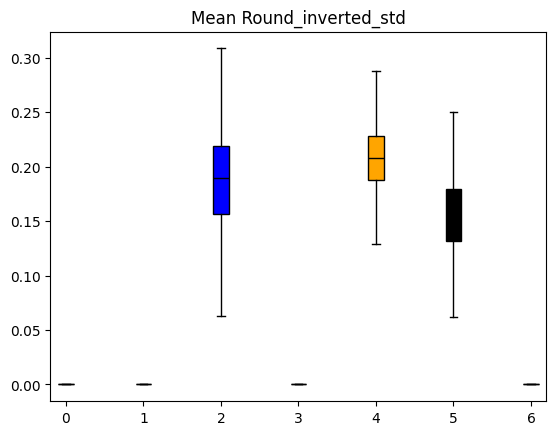

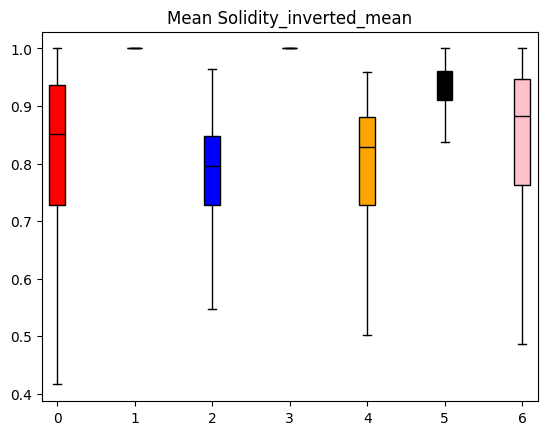

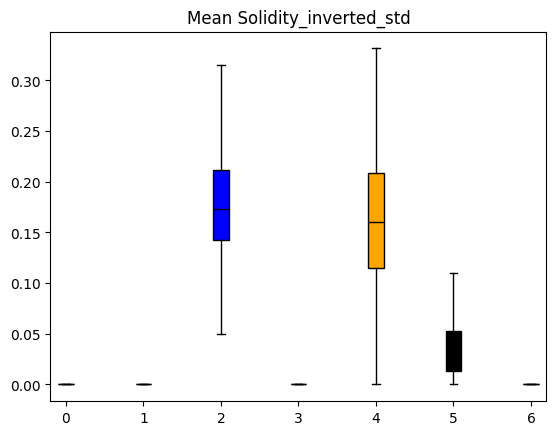

In [162]:
# print bar plots for each param based on class
feats = ["Ua","Ui","Ga","Gi","Da","Di","Ba",'Ua/Ui', 'Ua/Ga', 'Ua/Gi', 'Ua/Da', 'Ua/Di', 'Ua/Ba', 'Ga/Gi', 'Ga/Da',
       'Ga/Di', 'Ga/Ba', 'Gi/Da', 'Gi/Di', 'Gi/Ba', 'Da/Di', 'Da/Ba', 'Di/Ba',
       'Ui/Gi', 'Ui/Da', 'Ui/Di', 'Ui/Ba'] + list(feats_df.columns[13:111])

classes = np.arange(0,num_classes)# list of unique clusters

#class_dfs = [] # list of dfs for each cluster
rows = {}

# for j in ["Ua","Ui","Ga","Gi","Da","Di","Ba"]:
#     feats_df[j] = feats_df[j].astype(float)

for i in classes:
#   df = feats_df[feats_df["cluster"] == i]
#   for j in ["Ua","Ui","Ga","Gi","Da","Di","Ba"]:
#       feats_df[j] = feats_df[j].astype(float)
#       df_narrow[j] = df_narrow[j].astype(float)
#       df = df[((df[j] >= df_narrow[j].min()) & (df[j] <= df_narrow[j].max()))]
#   df.reset_index(inplace = True, drop = True)
#   class_dfs.append(df)
  rows[str(i)] = []


for i in range(len(feats)):
  fig, ax = plt.subplots()
  
  param = feats[i]
  data = []

  

  for i, df in enumerate(class_dfs):
    rows[str(i)] = df[param].values
    data.append(rows[str(i)])

  positions = np.arange(0, num_classes) * 2.5
  bp = ax.boxplot(data, widths=0.5, positions=positions, patch_artist=True, showfliers=False,
              medianprops=dict(color='black'))

  for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    
  ax.set(title = "Mean " + param)

  ax.set_xticklabels(['0','1','2','3','4','5','6'])

  plt.show()

In [163]:
feats_df.columns[-10:]

Index(['Gi/Di', 'Gi/Ba', 'Da/Di', 'Da/Ba', 'Di/Ba', 'Ui/Gi', 'Ui/Da', 'Ui/Di',
       'Ui/Ba', 'Ui/Ga'],
      dtype='object')

In [136]:
print(feats_df["Ua"])
#print(feats_df["Ua_scaled"])

0        0.011652
1        0.025122
2        0.014455
3        0.034475
4        0.025569
           ...   
39512    0.047659
39513    0.049658
39514    0.025269
39515    0.029474
39516    0.019996
Name: Ua, Length: 39517, dtype: float64


In [164]:
# scale each param so we can plot them next to each other
with open("data/unclassified_features_33770.pkl", 'rb') as f:
  df_narrow = pickle.load(f)

params = ["Ua","Ui","Ga","Gi","Da","Di","Ba"]

for j in params:
  feats_df[j] = feats_df[j].astype(float)
  df_narrow[j] = df_narrow[j].astype(float)
  param_df = feats_df[((feats_df[j] >= df_narrow[j].min()) & (feats_df[j] <= df_narrow[j].max()))]

params_df = param_df[params]



from sklearn.preprocessing import MinMaxScaler


for param in  params:
  sc = MinMaxScaler()
  param_arr = np.array(params_df[param]).reshape(-1,1)
  param_arr_scaled = sc.fit_transform(param_arr)
  feats_df[param + "_scaled"] = param_arr_scaled


feats = ['Ua_scaled', 'Ui_scaled', 'Ga_scaled',
        'Gi_scaled', 'Da_scaled', 'Di_scaled', 'Ba_scaled']

feats_extra = []

for i in feats:
  feats_extra.append(i + " mean")
  feats_extra.append(i + " min")
  feats_extra.append(i + " max")
  feats_extra.append(i + " std")

feats = feats_extra
print(len(feats))

classes = np.arange(0,num_classes)# list of unique clusters

class_dfs = [] # list of dfs for each cluster
rows = {}

for i in classes:
  df = feats_df[feats_df["cluster"] == i]
  for j in ["Ua","Ui","Ga","Gi","Da","Di","Ba"]:
      feats_df[j] = feats_df[j].astype(float)
      df_narrow[j] = df_narrow[j].astype(float)
      df = df[((df[j] >= df_narrow[j].min()) & (df[j] <= df_narrow[j].max()))]
  df.reset_index(inplace = True, drop = True)
  class_dfs.append(df)
  rows[str(i)] = []


for i in range(num_classes):
  df = class_dfs[i]
  for j in range(0,len(feats),4):
    mean_val = np.mean(np.array(df[feats[j][0:9]].astype(float)))
    rows[str(i)].append(mean_val)

    min_val = np.min(np.array(df[feats[j][0:9]].astype(float)))
    rows[str(i)].append(min_val)

    max_val = np.max(np.array(df[feats[j][0:9]].astype(float)))
    rows[str(i)].append(max_val)

    std = np.std(np.array(df[feats[j][0:9]].astype(float)))
    rows[str(i)].append(std)

    # print("Cluster " + str(i) + " avg " + feat + ": " + str(mean_val))


cluster_means_df = pd.DataFrame(rows)
# cluster_means_df["feats"] = feats
cluster_means_df = cluster_means_df.transpose()
cluster_means_df.columns = feats

cluster_means_df


28


,Ua_scaled mean,Ua_scaled min,Ua_scaled max,Ua_scaled std,Ui_scaled mean,Ui_scaled min,Ui_scaled max,Ui_scaled std,Ga_scaled mean,Ga_scaled min,Ga_scaled max,Ga_scaled std,Gi_scaled mean,Gi_scaled min,Gi_scaled max,Gi_scaled std,Da_scaled mean,Da_scaled min,Da_scaled max,Da_scaled std,Di_scaled mean,Di_scaled min,Di_scaled max,Di_scaled std,Ba_scaled mean,Ba_scaled min,Ba_scaled max,Ba_scaled std
0,0.535282,0.000170,0.999883,0.250979,0.431725,0.006080,0.998456,0.234139,0.503390,0.047693,0.996562,0.203723,0.540069,0.000477,1.000000,0.243899,0.499718,0.001172,0.999981,0.271431,0.508856,0.000054,0.999396,0.268132,0.439378,0.000000,0.995624,0.246703
1,0.385538,0.000000,1.000000,0.265362,0.649217,0.001357,1.000000,0.223319,0.663724,0.038978,1.000000,0.215938,0.422642,0.000126,0.999567,0.281330,0.501190,0.000005,1.000000,0.272947,0.496618,0.000000,0.999242,0.271665,0.619289,0.000721,1.000000,0.259914
2,0.559459,0.014521,0.995799,0.238540,0.505816,0.034954,0.998778,0.235121,0.624430,0.047766,0.999993,0.225377,0.439602,0.001581,1.000000,0.238272,0.491890,0.000000,0.998663,0.272645,0.527522,0.000841,0.999396,0.270901,0.477093,0.002843,0.983150,0.246010
3,0.577148,0.000725,0.999950,0.255860,0.386004,0.000000,0.999724,0.287991,0.259577,0.000000,0.999993,0.220513,0.569033,0.000000,0.999869,0.256705,0.517415,0.000165,0.999666,0.268644,0.447733,0.000133,0.998887,0.276195,0.438266,0.000541,0.999914,0.258082
4,0.535986,0.002660,0.997429,0.270198,0.536652,0.131119,0.998636,0.221120,0.603900,0.068864,0.999288,0.217926,0.440501,0.001750,0.999914,0.254010,0.484163,0.000365,0.991078,0.256914,0.549158,0.001980,0.998503,0.275913,0.487244,0.002816,0.989521,0.248922
5,0.581319,0.002266,0.993546,0.248104,0.519653,0.040955,0.997235,0.211533,0.644262,0.067900,0.999486,0.217764,0.369691,0.000959,0.998974,0.228804,0.477059,0.000434,0.999007,0.280850,0.521332,0.009713,1.000000,0.261419,0.506766,0.002523,0.998014,0.265632
6,0.519109,0.000170,0.999883,0.232305,0.401136,0.006080,0.999152,0.217423,0.489604,0.004264,0.999983,0.195701,0.535492,0.000477,0.999780,0.225951,0.484760,0.000292,0.999981,0.261795,0.496890,0.000054,0.999338,0.257536,0.443027,0.000000,0.998024,0.230887


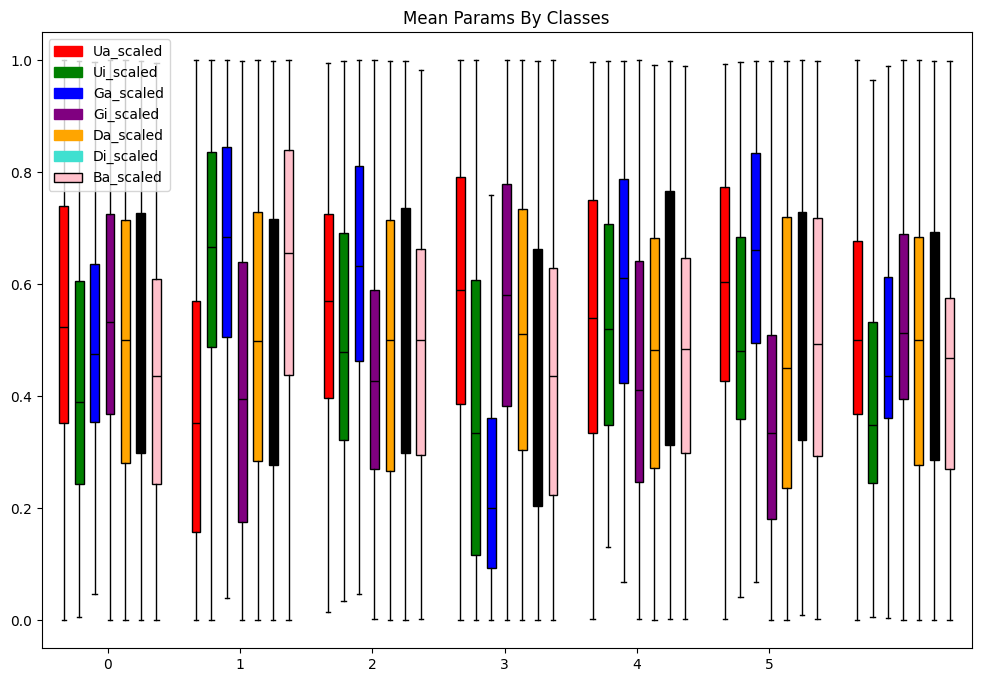

In [ ]:
# Do all 7 main params on the same plot

# print box plots for each param based on class

feats = ['Ua_scaled', 'Ui_scaled', 'Ga_scaled',
        'Gi_scaled', 'Da_scaled', 'Di_scaled', 'Ba_scaled']

classes = np.arange(0,num_classes)# list of unique clusters

# class_dfs = [] # list of dfs for each cluster

# for i in classes:
#   df = feats_df[feats_df["cluster"] == i]
#   for j in ["Ua","Ui","Ga","Gi","Da","Di","Ba"]:
#       feats_df[j] = feats_df[j].astype(float)
#       df_narrow[j] = df_narrow[j].astype(float)
#       df = df[((df[j] >= df_narrow[j].min()) & (df[j] <= df_narrow[j].max()))]
#   df.reset_index(inplace = True, drop = True)
#   class_dfs.append(df)


fig, ax = plt.subplots(figsize = (12,8))


for i, class_df in enumerate(class_dfs):
  positions = np.arange(len(feats)) * 0.35 + i*3
  data = []

  for feat in feats:
     df = class_df[feat]
     data.append(df)
     
  bp = ax.boxplot(data, widths=0.2, positions=positions, patch_artist=True, showfliers=False,
              medianprops=dict(color='black'))
  
  for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)


ax.set(title = "Mean Params By Classes")

leg = ax.legend(['Ua_scaled', 'Ui_scaled', 'Ga_scaled',
        'Gi_scaled', 'Da_scaled', 'Di_scaled', 'Ba_scaled'], loc="upper left")
leg = ax.get_legend()
leg.legend_handles[0].set_color('red')
leg.legend_handles[1].set_color('green')
leg.legend_handles[2].set_color('blue')
leg.legend_handles[3].set_color('purple')
leg.legend_handles[4].set_color('orange')
leg.legend_handles[5].set_color('turquoise')


ax.set_xticks([1,4,7,10,13,16])
ax.set_xticklabels(['0','1','2','3','4','5'])


plt.show()


In [166]:
feats_df.columns[13:112]

Index(['num_spots', 'Mean', 'Median', 'Area_mean', 'Area_std', 'X_mean',
       'X_std', 'Y_mean', 'Y_std', 'Perim._mean', 'Perim._std', 'BX_mean',
       'BX_std', 'BY_mean', 'BY_std', 'Width_mean', 'Width_std', 'Height_mean',
       'Height_std', 'Major_mean', 'Major_std', 'Minor_mean', 'Minor_std',
       'Angle_mean', 'Angle_std', 'Circ._mean', 'Circ._std', 'Feret_mean',
       'Feret_std', 'IntDen_mean', 'IntDen_std', '%Area_mean', '%Area_std',
       'RawIntDen_mean', 'RawIntDen_std', 'FeretX_mean', 'FeretX_std',
       'FeretY_mean', 'FeretY_std', 'FeretAngle_mean', 'FeretAngle_std',
       'MinFeret_mean', 'MinFeret_std', 'AR_mean', 'AR_std', 'Round_mean',
       'Round_std', 'Solidity_mean', 'Solidity_std', 'num_spots_inverted',
       'Mean_inverted', 'Median_inverted', 'Area_inverted_mean',
       'Area_inverted_std', 'X_inverted_mean', 'X_inverted_std',
       'Y_inverted_mean', 'Y_inverted_std', 'Perim._inverted_mean',
       'Perim._inverted_std', 'BX_inverted_mean', 'BX_

In [167]:
from sklearn.linear_model import LinearRegression

feat_1 = np.array(feats_df["num_spots"]).reshape(-1,1)
param_1 = np.array(feats_df["Ua"]).reshape(-1,1)
print(len(feat_1))

lin_reg=LinearRegression()
lin_reg.fit(feat_1,param_1)

33770


,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [168]:
from sklearn.linear_model import LinearRegression

#initiate linear regression model
model = LinearRegression()

#define predictor and response variables
feat_1 = np.array(feats_df["num_spots"]).reshape(-1,1)
param_1 = np.array(feats_df["Ua"]).reshape(-1,1)

#fit regression model
model.fit(param_1, feat_1)

#calculate R-squared of regression model
r_squared = model.score(param_1, feat_1)

#view R-squared value
print(r_squared)


0.026685643102544843


In [170]:
from sklearn.linear_model import LinearRegression

params = ["Ua","Ui","Ga","Gi","Da","Di","Ba",'Ua/Ui', 'Ua/Ga', 'Ua/Gi', 'Ua/Da', 'Ua/Di', 'Ua/Ba', 'Ga/Gi', 'Ga/Da',
       'Ga/Di', 'Ga/Ba', 'Gi/Da', 'Gi/Di', 'Gi/Ba', 'Da/Di', 'Da/Ba', 'Di/Ba',
       'Ui/Gi', 'Ui/Da', 'Ui/Di', 'Ui/Ba']
feats = list(feats_df.columns[13:111])


p_list = []
f_list = []
r2 = []

for param in params:
  for feat in feats:
    model = LinearRegression()

    #define predictor and response variables
    feat_1 = np.array(feats_df[feat]).reshape(-1,1)
    param_1 = np.array(feats_df[param]).reshape(-1,1)

    #fit regression model
    model.fit(param_1, feat_1)

    #calculate R-squared of regression model
    r_squared = model.score(param_1, feat_1)

    r2.append(r_squared)
    p_list.append(param)
    f_list.append(feat)

r2_dic = {"feat": f_list,"param":p_list,"r2":r2}

r2_df = pd.DataFrame(r2_dic)

r2_df.head()

,feat,param,r2
0,num_spots,Ua,0.026686
1,Mean,Ua,0.094981
2,Median,Ua,0.080573
3,Area_mean,Ua,0.008368
4,Area_std,Ua,0.000009


In [173]:
r2_sorted = r2_df.sort_values(by=['r2'], ascending = False)

r2_sorted[r2_sorted["feat"] == "Mean"]

,feat,param,r2
1569,Mean,Ga/Ba,0.312211
197,Mean,Ga,0.282301
785,Mean,Ua/Ga,0.277238
1373,Mean,Ga/Da,0.262831
2549,Mean,Ui/Ba,0.257136
1275,Mean,Ga/Gi,0.240016
2255,Mean,Ui/Gi,0.198591
99,Mean,Ui,0.197997
2353,Mean,Ui/Da,0.187867
687,Mean,Ua/Ui,0.153818


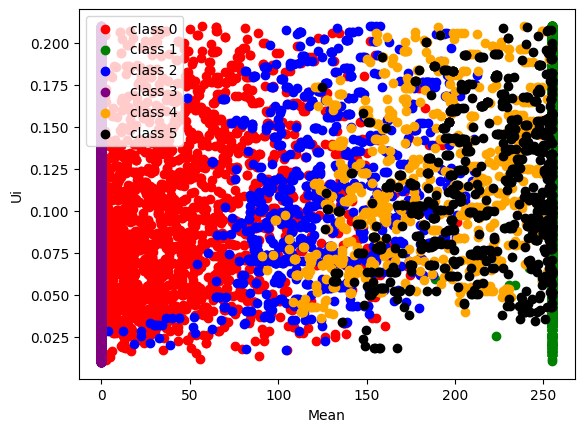

In [177]:
# plot the model predicted class in feature space

classes = np.arange(0,num_classes)# list of unique clusters

# class_dfs = [] # list of dfs for each cluster

# for i in classes:
#   df = feats_df[feats_df["cluster"] == i]
#   df.reset_index(inplace = True, drop = True)
#   class_dfs.append(df)


feat_1 = "Mean"

feat_2 = "Ui"

fig, ax = plt.subplots()

alpha = [1,1,1,1,1,1,1]
for j in classes:
  df = class_dfs[j]
  ax.scatter(df[feat_1], df[feat_2], c = colors[j], label = "class " + str(j), alpha = alpha[j])


leg = ax.legend(loc="upper left")

ax.set(xlabel = feat_1, ylabel = feat_2)
plt.show()


In [ ]:
# isolate individual param scans for comparison accross feature space

# with open("data/Images_Classified_KM_s42_cl6.pkl", 'rb') as f:
#   feats_df = pickle.load(f) # deserialize using load()

# with open("data/2024-08-012_imagej_feats_inverted_no_dfs_df.pkl", 'rb') as f:
#   feats_df = pickle.load(f) # deserialize using load()



In [ ]:
# feats_df.reset_index(inplace = True, drop = True)

In [178]:
feats_df[["Ua","Ui"]].iloc[0]

Ua    0.025122
Ui    0.063822
Name: 0, dtype: float64

In [ ]:
params = ["Ua","Ui","Ga","Gi","Da","Ba"]

prog = 0
ind_list = []
for i in range(0,feats_df.shape[0]-1):
  curr = np.array(feats_df[params].iloc[i])
  next = np.array(feats_df[params].iloc[i+1])
  if (curr == next).all():
    ind_list.append(i)

  if prog % 500 == 0:
    print(prog)
  prog += 1

0
500
1000
1500
2000
2500
3000
3500
4000
4500
5000
5500
6000
6500
7000
7500
8000
8500
9000
9500
10000
10500
11000
11500
12000
12500
13000
13500
14000
14500
15000
15500
16000
16500
17000
17500
18000
18500
19000
19500
20000
20500
21000
21500
22000
22500
23000
23500
24000
24500
25000
25500
26000
26500
27000
27500
28000
28500
29000
29500
30000
30500
31000
31500
32000
32500
33000
33500


In [182]:
print(len(ind_list))
print(ind_list)
print(feats_df.iloc[ind_list[0]])
print(feats_df.iloc[ind_list[1]])

# ua_only_scan = feats_df.iloc[ind_list[540:-3]]
# ua_only_scan.reset_index(inplace = True, drop = True)
# ui_only_scan = feats_df.iloc[ind_list[1081:-3]]
# ui_only_scan.reset_index(inplace = True, drop = True)
# ga_only_scan = feats_df.iloc[ind_list[54:-3]]
# ga_only_scan.reset_index(inplace = True, drop = True)
# gi_only_scan = feats_df.iloc[ind_list[216:-3]]
# gi_only_scan.reset_index(inplace = True, drop = True)
# da_only_scan = feats_df.iloc[ind_list[0:-3]]
# da_only_scan.reset_index(inplace = True, drop = True)
# di_only_scan = feats_df.iloc[ind_list[0:299]]
# di_only_scan.reset_index(inplace = True, drop = True)

# ba_only_scan = feats_df.iloc[ind_list[0:-3]]
# ba_only_scan.reset_index(inplace = True, drop = True)
# single_param_dic = {"Ua":ua_only_scan,"Ui":ui_only_scan,"Ga":ga_only_scan,"Gi":gi_only_scan,"Da":da_only_scan,"Di":di_only_scan,"Ba":ba_only_scan}

95
[8675, 8676, 8677, 8678, 8679, 8680, 8681, 8682, 8683, 8684, 8685, 8686, 8687, 8688, 8689, 8690, 8691, 8692, 8693, 8694, 8695, 8696, 8697, 8698, 8699, 8700, 8701, 8702, 8703, 8704, 8705, 8706, 8707, 8708, 8709, 8710, 8711, 8712, 8713, 8714, 8715, 8716, 8717, 8718, 8719, 8720, 8721, 8722, 8723, 8724, 8725, 8726, 8727, 8728, 8729, 8730, 8731, 8732, 8733, 8734, 8735, 8736, 8737, 8738, 8739, 8740, 8741, 8742, 8743, 8744, 8745, 8746, 8747, 8748, 8749, 8750, 8751, 8752, 8753, 8754, 8755, 8756, 8757, 8758, 8759, 8760, 8761, 8762, 8763, 8764, 8765, 8766, 16392, 28103, 33022]
Ua               0.03
Ui               0.07
Ga               0.08
Gi                0.1
Ba              -0.12
               ...   
Ga_scaled    0.366236
Gi_scaled    0.500009
Da_scaled    0.500274
Di_scaled    0.000889
Ba_scaled    0.499915
Name: 8675, Length: 143, dtype: object
Ua               0.03
Ui               0.07
Ga               0.08
Gi                0.1
Ba              -0.12
               ...   
Ga_scaled 

In [ ]:
# save single param dfs


# pickle_out = open("/content/drive/MyDrive/2024_Summer_Work_(Shared_Drive_Is_Full)/2024-08-28_single_param_scans.pkl","wb")
# pickle.dump(single_param_dic, pickle_out)
# pickle_out.close()

In [183]:
# load in the single param dfs

with open("data/single_param_scans.pkl", 'rb') as f:
  single_dic = pickle.load(f) # deserialize using load()

# # AAAA 
# with open("data/2024-08-30_imagej_feats_inverted_no_dfs_df.pkl", 'rb') as f:
#   feats_df2 = pickle.load(f) # deserialize using load()

# print(feats_df.shape)
# feats_df.head()

# print(feats_df2.shape)
# feats_df2.head()


In [ ]:
single_dic["Ua"].head(20)

In [185]:
feats_df[feats_df["path"]=="14754.png"]

,Ua,Ui,Ga,Gi,Ba,Da,Di,pattern,noise,path,seed,dir,feat_bool,num_spots,Mean,Median,Area_mean,Area_std,X_mean,X_std,Y_mean,Y_std,Perim._mean,Perim._std,BX_mean,BX_std,BY_mean,BY_std,Width_mean,Width_std,Height_mean,Height_std,Major_mean,Major_std,Minor_mean,Minor_std,Angle_mean,Angle_std,Circ._mean,Circ._std,Feret_mean,Feret_std,IntDen_mean,IntDen_std,%Area_mean,%Area_std,RawIntDen_mean,RawIntDen_std,FeretX_mean,FeretX_std,FeretY_mean,FeretY_std,FeretAngle_mean,FeretAngle_std,MinFeret_mean,MinFeret_std,AR_mean,AR_std,Round_mean,Round_std,Solidity_mean,Solidity_std,num_spots_inverted,Mean_inverted,Median_inverted,Area_inverted_mean,Area_inverted_std,X_inverted_mean,X_inverted_std,Y_inverted_mean,Y_inverted_std,Perim._inverted_mean,Perim._inverted_std,BX_inverted_mean,BX_inverted_std,BY_inverted_mean,BY_inverted_std,Width_inverted_mean,Width_inverted_std,Height_inverted_mean,Height_inverted_std,Major_inverted_mean,Major_inverted_std,Minor_inverted_mean,Minor_inverted_std,Angle_inverted_mean,Angle_inverted_std,Circ._inverted_mean,Circ._inverted_std,Feret_inverted_mean,Feret_inverted_std,IntDen_inverted_mean,IntDen_inverted_std,%Area_inverted_mean,%Area_inverted_std,RawIntDen_inverted_mean,RawIntDen_inverted_std,FeretX_inverted_mean,FeretX_inverted_std,FeretY_inverted_mean,FeretY_inverted_std,FeretAngle_inverted_mean,FeretAngle_inverted_std,MinFeret_inverted_mean,MinFeret_inverted_std,AR_inverted_mean,AR_inverted_std,Round_inverted_mean,Round_inverted_std,Solidity_inverted_mean,Solidity_inverted_std,pc1,pc2,cluster,pc3,Ua/Ui,Ua/Ga,Ua/Gi,Ua/Da,Ua/Di,Ua/Ba,Ga/Gi,Ga/Da,Ga/Di,Ga/Ba,Gi/Da,Gi/Di,Gi/Ba,Da/Di,Da/Ba,Di/Ba,Ui/Gi,Ui/Da,Ui/Di,Ui/Ba,Ui/Ga,Ua_scaled,Ui_scaled,Ga_scaled,Gi_scaled,Da_scaled,Di_scaled,Ba_scaled
9048,0.009253,0.07,0.08,0.1,-0.12,0.01,0.5,1,2,14754.png,14754,/content/Images3/,1,38,155.289,255,641.026316,710.10998,82.814789,55.026159,96.098553,60.940349,120.313974,114.527188,67.578947,51.600506,80.605263,61.373978,30.421053,21.298173,29.421053,21.364791,33.356947,20.573509,19.426368,10.597371,92.678026,60.553119,0.686947,0.263148,37.249605,26.473674,163461.710526,181078.044868,100.0,0.0,163461.710526,181078.044868,69.789474,52.259554,92.052632,63.816739,102.209974,51.551467,23.020026,15.650098,1.683553,0.595243,0.669237,0.222477,0.853526,0.117194,2,99.711,0,7820.5,7151.5,137.5425,42.3655,62.731,43.096,1087.72,827.754,77.5,77.5,0.0,0.0,122.5,77.5,123.5,76.5,90.1545,55.4545,77.7325,53.1855,141.027,1.458,0.0875,0.0365,171.3295,111.5135,1994227.5,1823632.5,100.0,0.0,1994227.5,1823632.5,81.5,81.5,0.0,0.0,131.6055,3.3945,121.9055,78.0945,1.263,0.151,0.803,0.096,0.3995,0.0075,16.423877,-2.336461,2,11.327976,0.132179,0.115657,0.092525,0.925253,0.018505,-0.077104,0.8,8.0,0.16,-0.666667,10.0,0.2,-0.833333,0.02,-0.083333,-4.166667,0.7,7.0,0.14,-0.583333,0.875,0.021254,0.299846,0.366236,0.500009,0.500274,0.198445,0.499915


In [201]:
# create a new dictionary containing the classes by searching

indices = {"Ua":[],"Ui":[],"Ga":[],"Gi":[],"Da":[],"Di":[],"Ba":[]}

for i in single_dic.keys():
    counter = 0
    print(i)
    df = single_dic[i]
    df.reset_index(inplace=True, drop=True)
    print(range(df.shape[0]))

    for j in range(df.shape[0]):
        path = df["path"][j]
        line = feats_df_large[feats_df_large["path"] == path]

        if line.empty:
            # print(f"⚠️ No match found for path: {path}")
            counter+=1
            continue
        indices[i].append(line.index[0])
    print(counter)


# AAAA
# for i in single_dic.keys():
#   print(i)
#   print(single_dic[i])
#   df = single_dic[i]
#   df.reset_index(inplace = True, drop = True)
#   print(range(df.shape[0]))
#   for j in range(df.shape[0]):
#     path = df["path"][j]
#     print(path)
#     line = feats_df[feats_df["path"] == path]
#     # print(feats_df[feats_df["path"]])
#     indices[i].append(line.index[0])


single_classes = {"Ua":None,"Ui":None,"Ga":None,"Gi":None,"Da":None,"Di":None,"Ba":None}

# print(feats_df.shape)
for i in indices.keys():
  ind_list = indices[i]
  df = feats_df_large.iloc[ind_list]
  df.reset_index(inplace = True, drop = True)
  single_classes[i] = df


Ua
range(0, 199)
0
Ui
range(0, 197)
0
Ga
range(0, 199)
0
Gi
range(0, 199)
0
Da
range(0, 99)
0
Di
range(0, 299)
0
Ba
range(0, 199)
0


In [226]:
feats_df.columns[13:-3]

Index(['num_spots', 'Mean', 'Median', 'Area_mean', 'Area_std', 'X_mean',
       'X_std', 'Y_mean', 'Y_std', 'Perim._mean', 'Perim._std', 'BX_mean',
       'BX_std', 'BY_mean', 'BY_std', 'Width_mean', 'Width_std', 'Height_mean',
       'Height_std', 'Major_mean', 'Major_std', 'Minor_mean', 'Minor_std',
       'Angle_mean', 'Angle_std', 'Circ._mean', 'Circ._std', 'Feret_mean',
       'Feret_std', 'IntDen_mean', 'IntDen_std', '%Area_mean', '%Area_std',
       'RawIntDen_mean', 'RawIntDen_std', 'FeretX_mean', 'FeretX_std',
       'FeretY_mean', 'FeretY_std', 'FeretAngle_mean', 'FeretAngle_std',
       'MinFeret_mean', 'MinFeret_std', 'AR_mean', 'AR_std', 'Round_mean',
       'Round_std', 'Solidity_mean', 'Solidity_std', 'num_spots_inverted',
       'Mean_inverted', 'Median_inverted', 'Area_inverted_mean',
       'Area_inverted_std', 'X_inverted_mean', 'X_inverted_std',
       'Y_inverted_mean', 'Y_inverted_std', 'Perim._inverted_mean',
       'Perim._inverted_std', 'BX_inverted_mean', 'BX_

In [202]:
single_classes["Ua"].head()

,Ua,Ui,Ga,Gi,Ba,Da,Di,pattern,noise,path,seed,dir,feat_bool,num_spots,Mean,Median,Area_mean,Area_std,X_mean,X_std,Y_mean,Y_std,Perim._mean,Perim._std,BX_mean,BX_std,BY_mean,BY_std,Width_mean,Width_std,Height_mean,Height_std,Major_mean,Major_std,Minor_mean,Minor_std,Angle_mean,Angle_std,Circ._mean,Circ._std,Feret_mean,Feret_std,IntDen_mean,IntDen_std,%Area_mean,%Area_std,RawIntDen_mean,RawIntDen_std,FeretX_mean,FeretX_std,FeretY_mean,FeretY_std,FeretAngle_mean,FeretAngle_std,MinFeret_mean,MinFeret_std,AR_mean,AR_std,Round_mean,Round_std,Solidity_mean,Solidity_std,num_spots_inverted,Mean_inverted,Median_inverted,Area_inverted_mean,Area_inverted_std,X_inverted_mean,X_inverted_std,Y_inverted_mean,Y_inverted_std,Perim._inverted_mean,Perim._inverted_std,BX_inverted_mean,BX_inverted_std,BY_inverted_mean,BY_inverted_std,Width_inverted_mean,Width_inverted_std,Height_inverted_mean,Height_inverted_std,Major_inverted_mean,Major_inverted_std,Minor_inverted_mean,Minor_inverted_std,Angle_inverted_mean,Angle_inverted_std,Circ._inverted_mean,Circ._inverted_std,Feret_inverted_mean,Feret_inverted_std,IntDen_inverted_mean,IntDen_inverted_std,%Area_inverted_mean,%Area_inverted_std,RawIntDen_inverted_mean,RawIntDen_inverted_std,FeretX_inverted_mean,FeretX_inverted_std,FeretY_inverted_mean,FeretY_inverted_std,FeretAngle_inverted_mean,FeretAngle_inverted_std,MinFeret_inverted_mean,MinFeret_inverted_std,AR_inverted_mean,AR_inverted_std,Round_inverted_mean,Round_inverted_std,Solidity_inverted_mean,Solidity_inverted_std,pc1,pc2,cluster
0,0.0067,0.07,0.08,0.1,-0.12,0.01,0.5,0,2,14735.png,14735,/content/Images3/,1,1,255.0,255,40000.0,0.0,100.0,0.0,100.0,0.0,797.657,0.0,0.0,0.0,0.0,0.0,200.0,0.0,200.0,0.0,225.676,0.0,225.676,0.0,0.0,0.0,0.79,0.0,282.843,0.0,10200000.0,0.0,100.0,0.0,10200000.0,0.0,0.0,0.0,0.0,0.0,135.0,0.0,200.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0,0.0,0,40000.0,0.0,100.0,0.0,100.0,0.0,800.0,0.0,0.0,0.0,0.0,0.0,200.0,0.0,200.0,0.0,225.676,0.0,225.676,0.0,0.0,0.0,0.785,0.0,282.843,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,135.0,0.0,200.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,-4.316102,-2.970861,1
1,0.006834343434343434,0.07,0.08,0.1,-0.12,0.01,0.5,0,2,14736.png,14736,/content/Images3/,1,1,255.0,255,40000.0,0.0,100.0,0.0,100.0,0.0,797.657,0.0,0.0,0.0,0.0,0.0,200.0,0.0,200.0,0.0,225.676,0.0,225.676,0.0,0.0,0.0,0.79,0.0,282.843,0.0,10200000.0,0.0,100.0,0.0,10200000.0,0.0,0.0,0.0,0.0,0.0,135.0,0.0,200.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0,0.0,0,40000.0,0.0,100.0,0.0,100.0,0.0,800.0,0.0,0.0,0.0,0.0,0.0,200.0,0.0,200.0,0.0,225.676,0.0,225.676,0.0,0.0,0.0,0.785,0.0,282.843,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,135.0,0.0,200.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,-4.316102,-2.970861,1
2,0.006968686868686869,0.07,0.08,0.1,-0.12,0.01,0.5,0,2,14737.png,14737,/content/Images3/,1,1,255.0,255,40000.0,0.0,100.0,0.0,100.0,0.0,797.657,0.0,0.0,0.0,0.0,0.0,200.0,0.0,200.0,0.0,225.676,0.0,225.676,0.0,0.0,0.0,0.79,0.0,282.843,0.0,10200000.0,0.0,100.0,0.0,10200000.0,0.0,0.0,0.0,0.0,0.0,135.0,0.0,200.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0,0.0,0,40000.0,0.0,100.0,0.0,100.0,0.0,800.0,0.0,0.0,0.0,0.0,0.0,200.0,0.0,200.0,0.0,225.676,0.0,225.676,0.0,0.0,0.0,0.785,0.0,282.843,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,135.0,0.0,200.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,-4.316102,-2.970861,1
3,0.007103030303030303,0.07,0.08,0.1,-0.12,0.01,0.5,0,2,14738.png,14738,/content/Images3/,1,1,255.0,255,40000.0,0.0,100.0,0.0,100.0,0.0,797.657,0.0,0.0,0.0,0.0,0.0,200.0,0.0,200.0,0.0,225.676,0.0,225.676,0.0,0.0,0.0,0.79,0.0,282.843,0.0,10200000.0,0.0,100.0,0.0,10200000.0,0.0,0.0,0.0,0.0,0.0,135.0,0.0,200.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0,0.0,0,40000.0,0.0,100.0,0.0,100.0,0.0,800.0,0.0,0.0,0.0,0.0,0.0,200.0,0.0,200.0,0.0,225.676,0.0,225.676,0.0,0.0,0.0,0.785,0.0,282.843,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,135.0,0.0,200.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,-4.316102,-2.970861,1
4,0.007237373737373738,0.07,0.08,0.1,-0.12,0.01,0.5,0,2,14739.png,14739,/content/Images3/,1,1,255.0,255,40000.0,0.0,100.0,0.0,100.0,0.0,797.657,0.0

Ua = 0.0067, Ui = 0.03585858585858586, Ga = 0.0552, Gi = 0.017, Da = 0.0, Di = 0.143, Ba = -0.030700000000000005, 

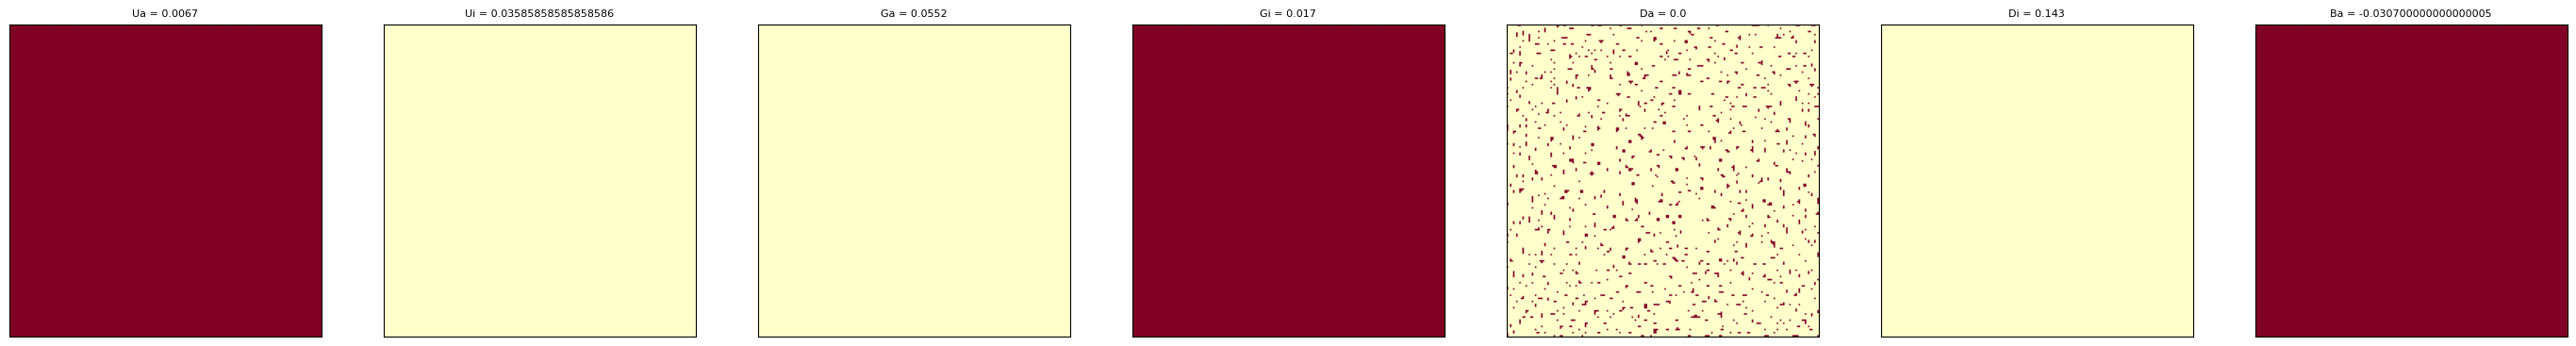

Ua = 0.006834343434343434, Ui = 0.03671717171717172, Ga = 0.055905050505050506, Gi = 0.01809090909090909, Da = 0.0012121212121212121, Di = 0.15155555555555555, Ba = -0.031854545454545455, 

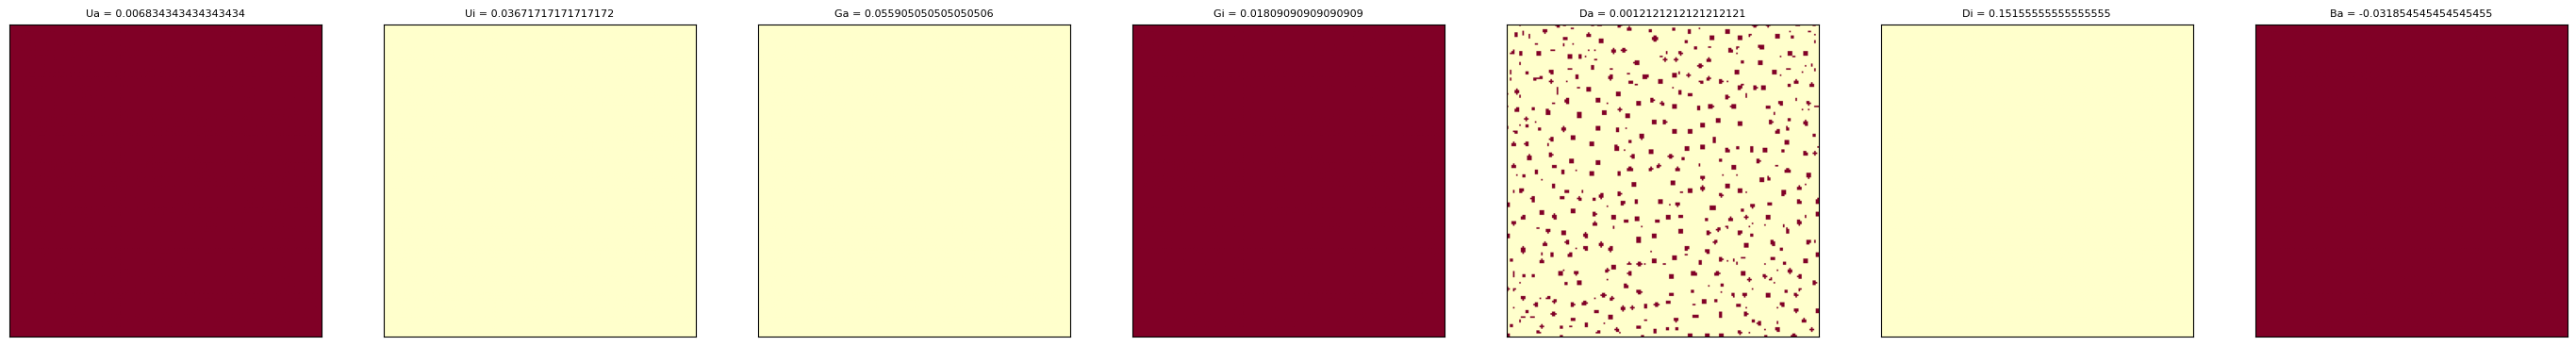

Ua = 0.006968686868686869, Ui = 0.03757575757575758, Ga = 0.056610101010101006, Gi = 0.019181818181818182, Da = 0.0015151515151515152, Di = 0.1601111111111111, Ba = -0.03300909090909092, 

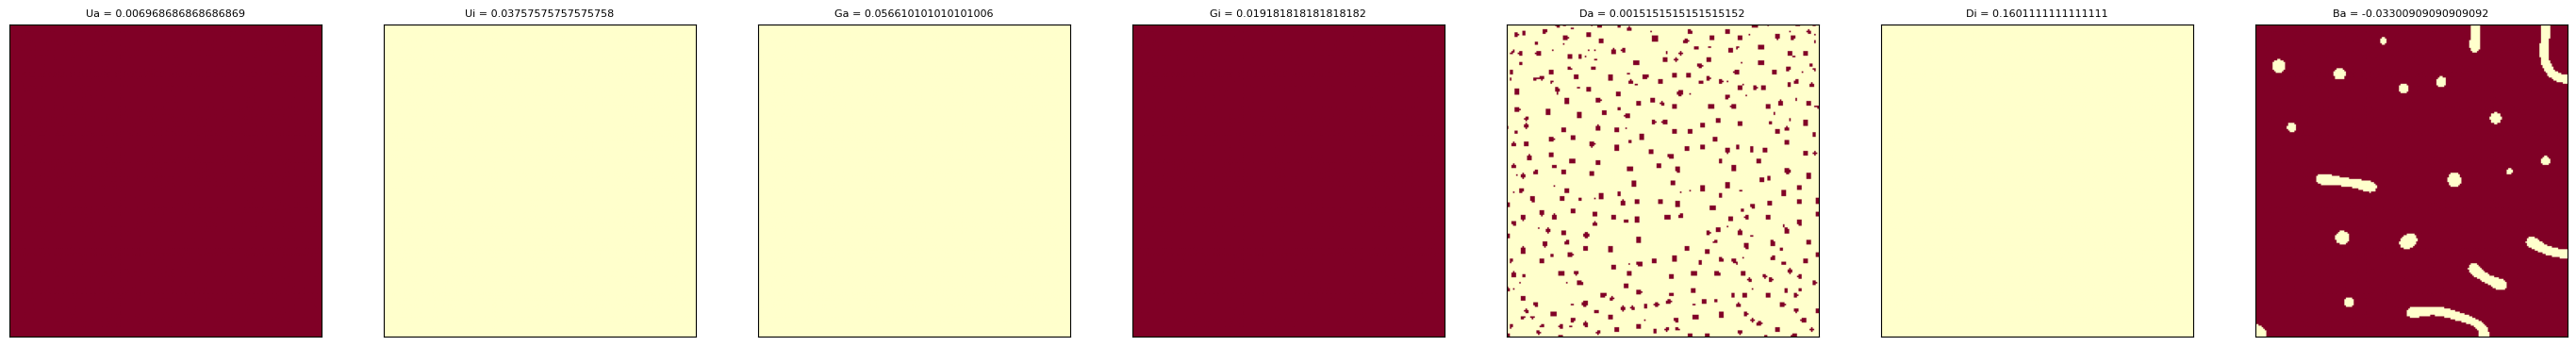

Ua = 0.007103030303030303, Ui = 0.03843434343434344, Ga = 0.05731515151515151, Gi = 0.020272727272727276, Da = 0.0018181818181818182, Di = 0.16866666666666666, Ba = -0.03416363636363637, 

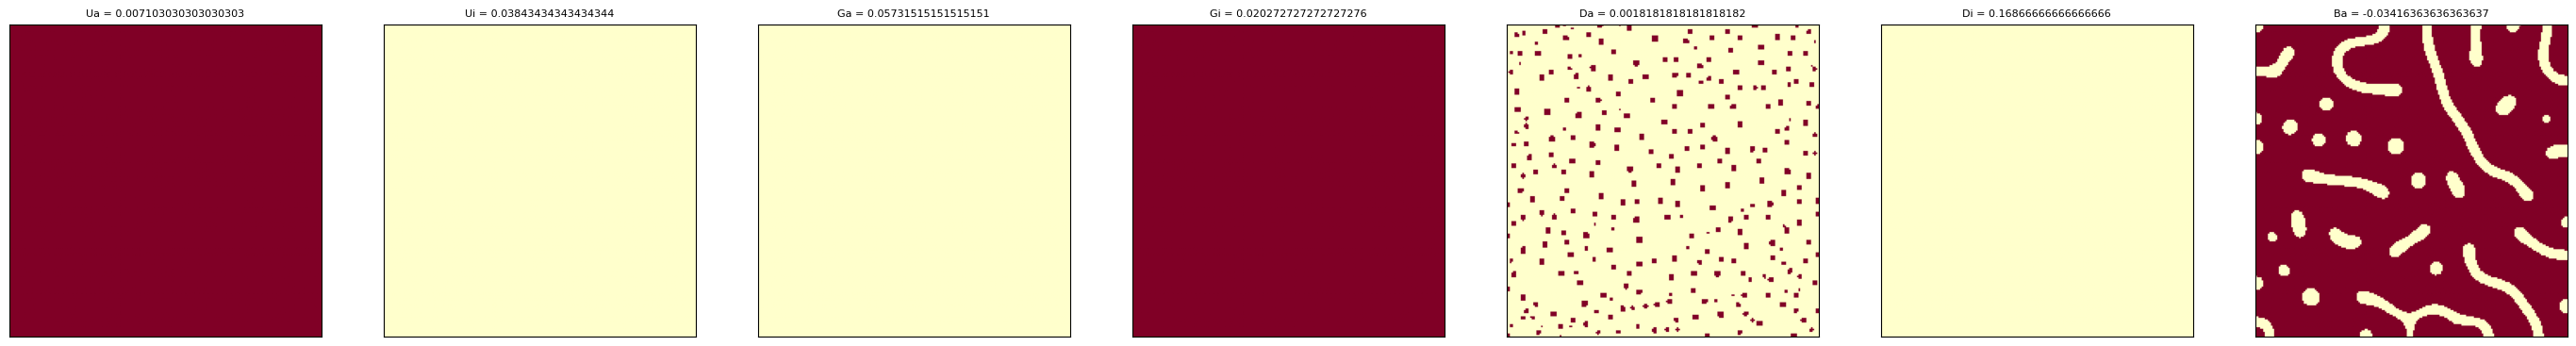

Ua = 0.007237373737373738, Ui = 0.039292929292929296, Ga = 0.05802020202020202, Gi = 0.021363636363636366, Da = 0.002121212121212121, Di = 0.17722222222222223, Ba = -0.03531818181818183, 

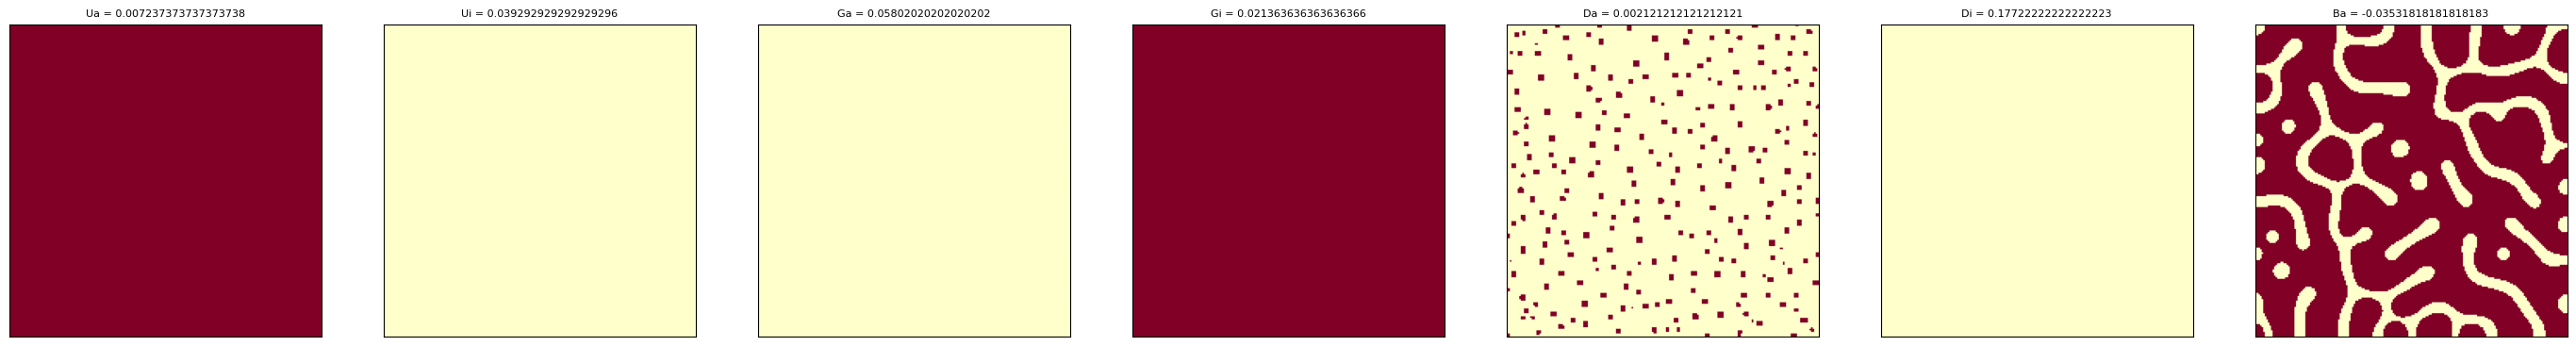

In [ ]:
#sort all the dfs
for i in single_classes.keys():
  df = single_classes[i]
  df[["Ua","Ui","Ga","Gi","Da","Di","Ba"]] = df[["Ua","Ui","Ga","Gi","Da","Di","Ba"]].astype(float)
  df = df.sort_values(by = i)
  single_classes[i] = df

# print out random images from clusters

num_imgs = 5

for i in range(num_imgs):
  fig, ax = plt.subplots(1,7)
  for j in range(7):
    params = ["Ua","Ui","Ga","Gi","Da","Di","Ba"]
    df = single_classes[params[j]]
    path = df["dir"][i] + df["path"][i]
    img = np.array(Image.open(path[1:]))
    ax[j].imshow(img, cmap = "YlOrRd", vmin = 0, vmax = 255)
    ax[j].set_title(str(params[j]) + " = "+ str(df[params[j]][i]), fontsize = 8)
    print(str(params[j]) + " = "+ str(df[params[j]][i]), end=", ")
    ax[j].get_xaxis().set_visible(False)
    ax[j].get_yaxis().set_visible(False)
   
  fig.set_figwidth(5*7)
  fig.set_figheight(5)
  plt.show()

In [ ]:
#plot every image in all the dfs

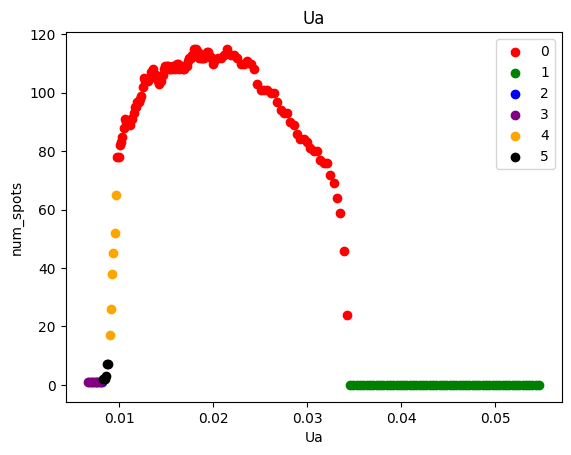

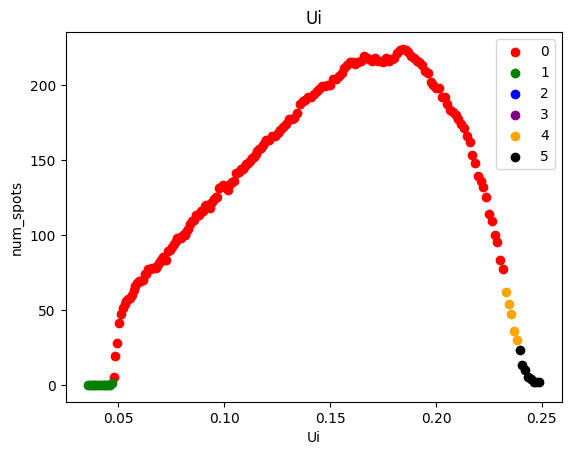

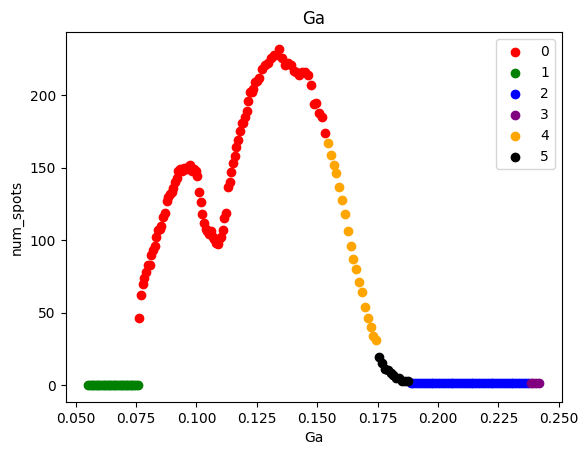

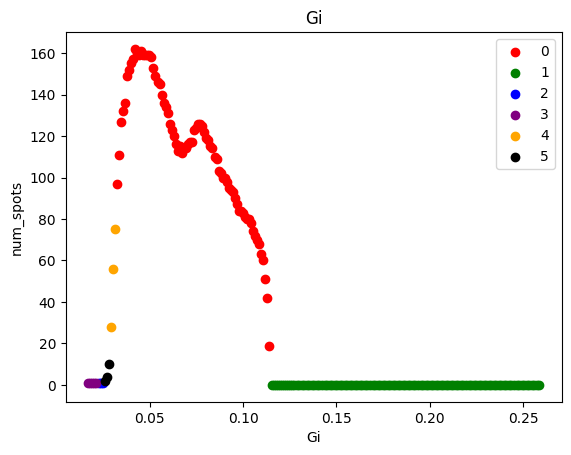

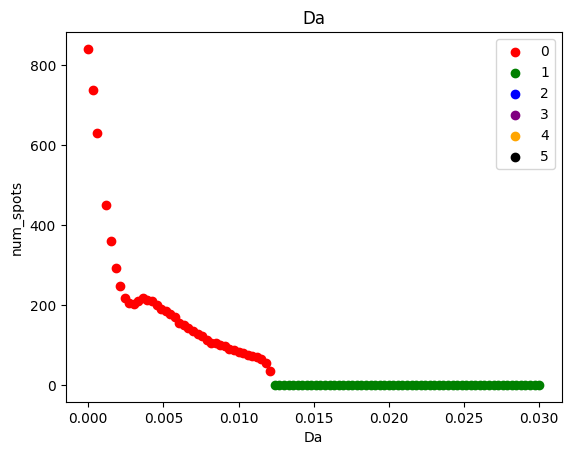

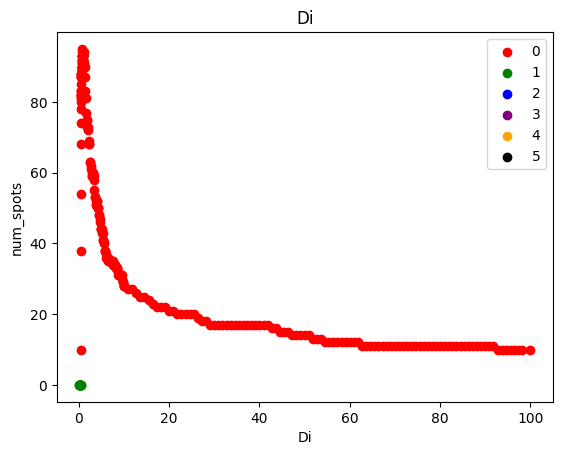

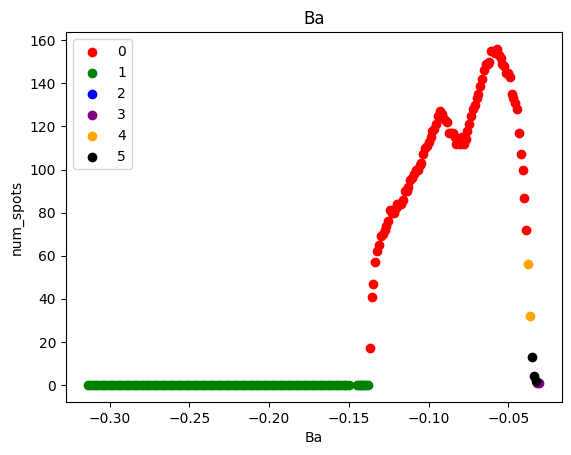

In [ ]:
# plot some dependencies

keys = list(single_classes.keys())
# feat_1 = "Ua"
feat_2 = "num_spots"

# iterate through params
for i in range(7):
  fig, ax = plt.subplots()
  # iterate through classes
  for j in range(6):

    # pull up the dataframe for the specific class
    df = single_classes[keys[i]]
    df = df[df["cluster"] == j]
    df.reset_index(inplace = True, drop = True)


    x = df[keys[i]].astype(float)
    y = df[feat_2].astype(float)

    ax.scatter(x,y, color = colors[j])
  ax.legend([0,1,2,3,4,5,6])
  ax.set(title = keys[i], xlabel = keys[i], ylabel = feat_2)
  plt.show()


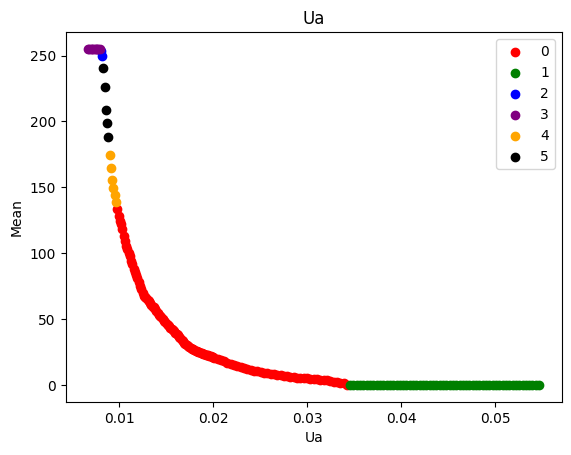

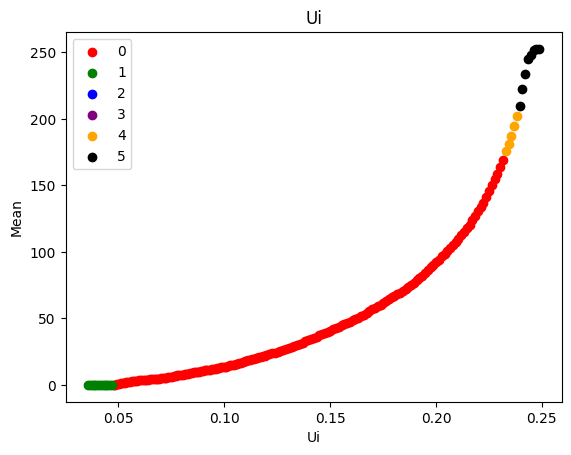

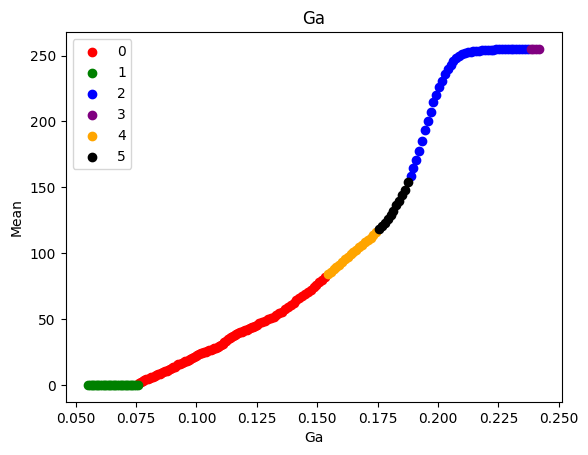

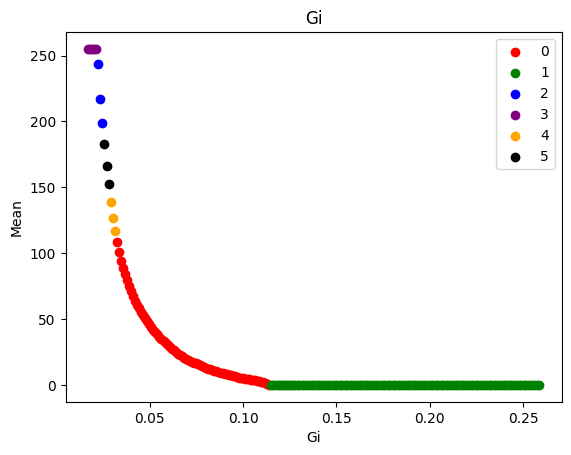

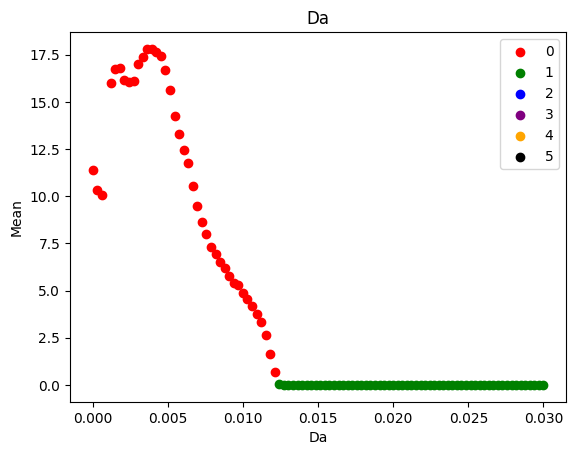

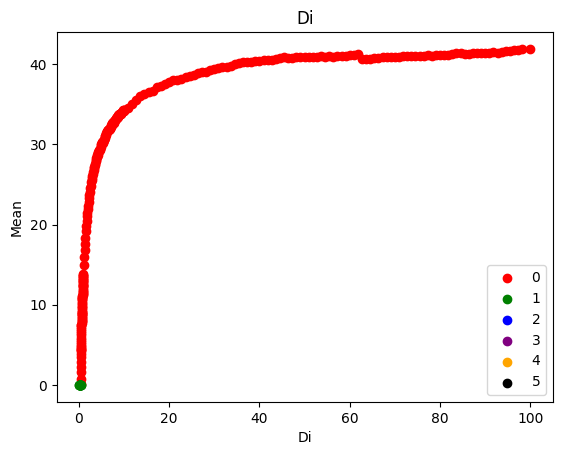

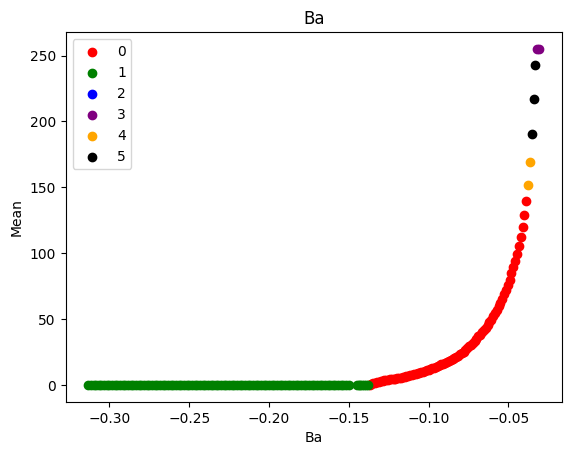

In [ ]:
# plot some dependencies

keys = list(single_classes.keys())
# feat_1 = "Ua"
feat_2 = "Mean"

# iterate through params
for i in range(7):
  fig, ax = plt.subplots()
  # iterate through classes
  for j in range(6):

    # pull up the dataframe for the specific class
    df = single_classes[keys[i]]
    df = df[df["cluster"] == j]
    df.reset_index(inplace = True, drop = True)


    x = df[keys[i]].astype(float)
    y = df[feat_2].astype(float)

    ax.scatter(x,y, color = colors[j])
  ax.legend([0,1,2,3,4,5,6])
  ax.set(title = keys[i], xlabel = keys[i], ylabel = feat_2)
  plt.show()


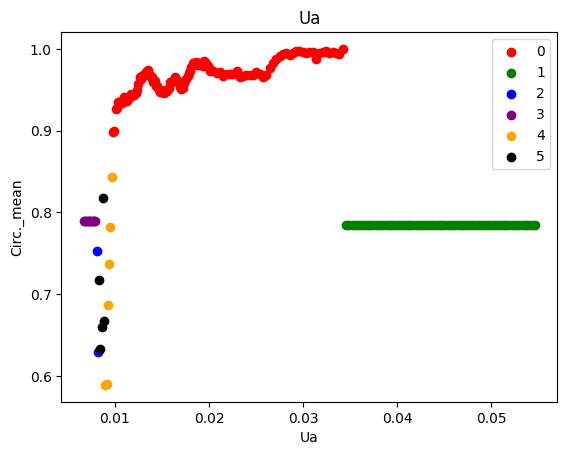

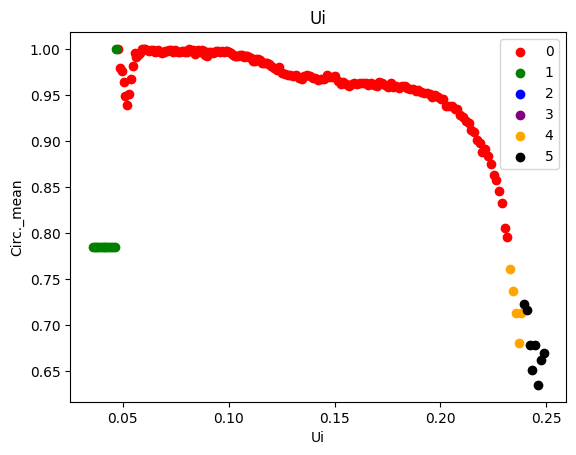

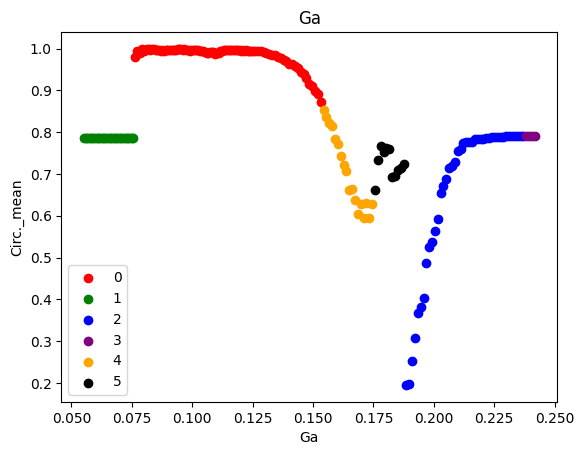

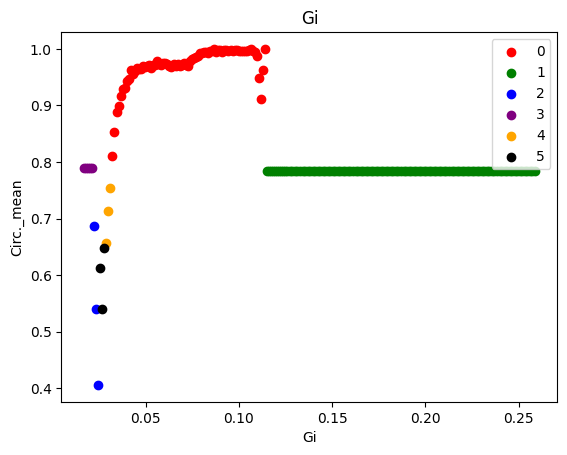

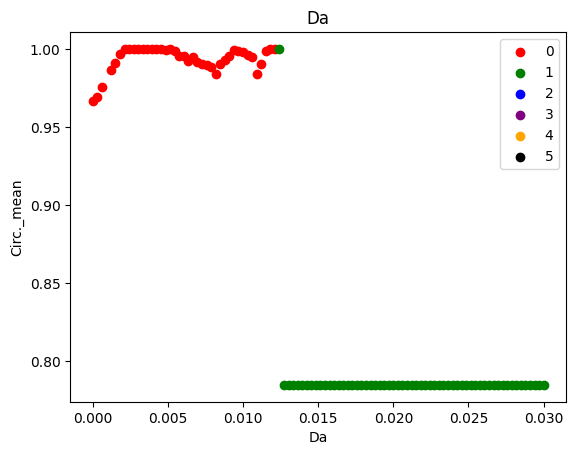

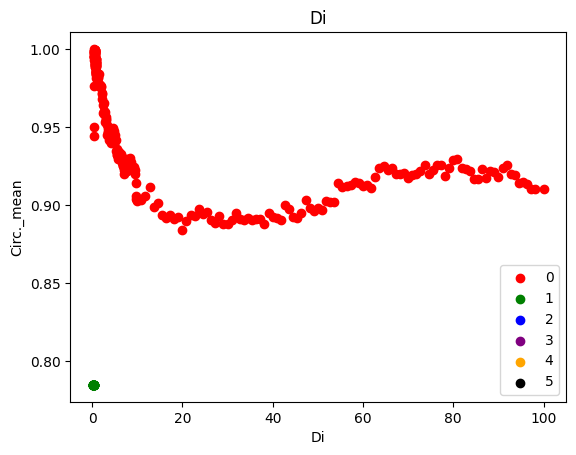

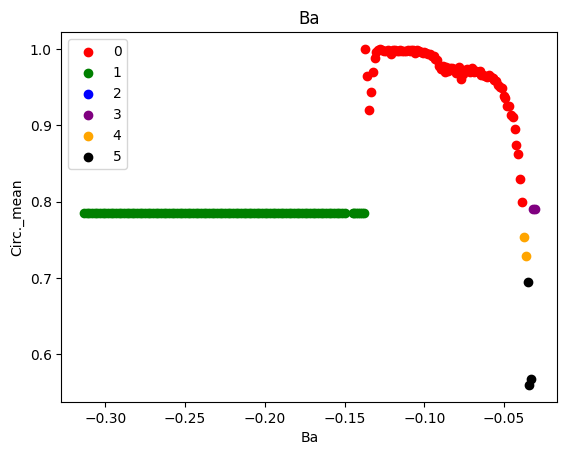

In [ ]:
# plot some dependencies

keys = list(single_classes.keys())
# feat_1 = "Ua"
feat_2 = "Circ._mean"

# iterate through params
for i in range(7):
  fig, ax = plt.subplots()
  # iterate through classes
  for j in range(6):

    # pull up the dataframe for the specific class
    df = single_classes[keys[i]]
    df = df[df["cluster"] == j]
    df.reset_index(inplace = True, drop = True)


    x = df[keys[i]].astype(float)
    y = df[feat_2].astype(float)

    ax.scatter(x,y, color = colors[j])
  ax.legend([0,1,2,3,4,5,6])
  ax.set(title = keys[i], xlabel = keys[i], ylabel = feat_2)
  plt.show()


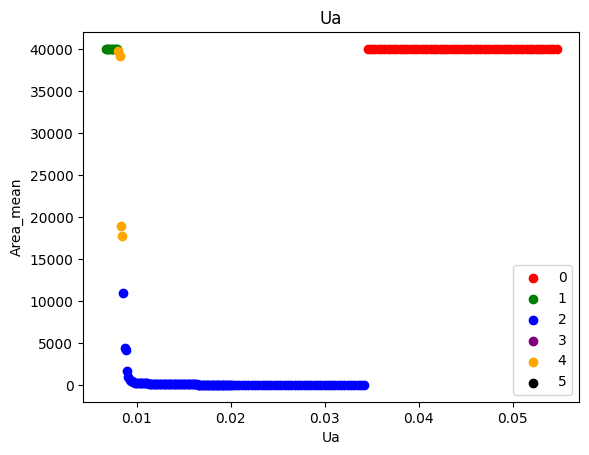

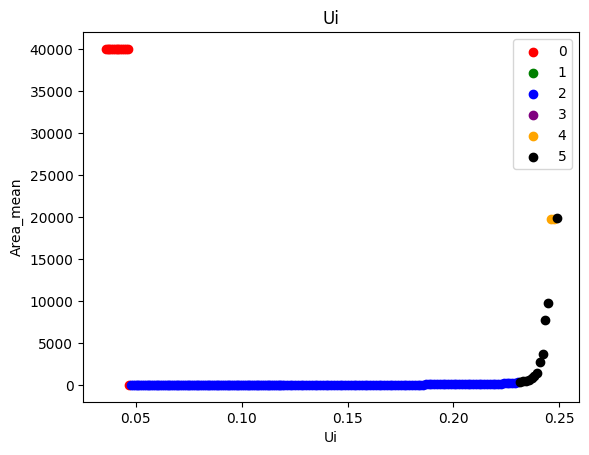

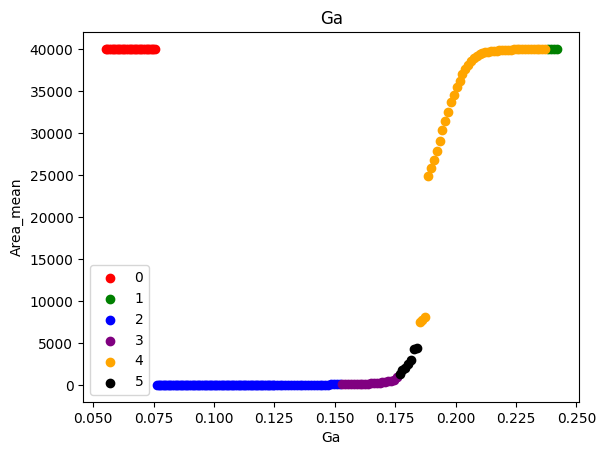

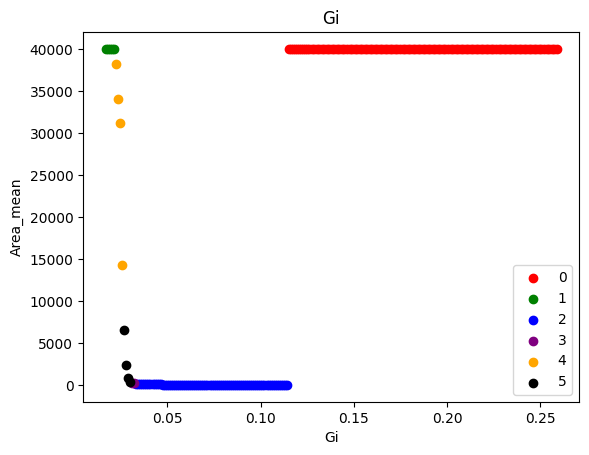

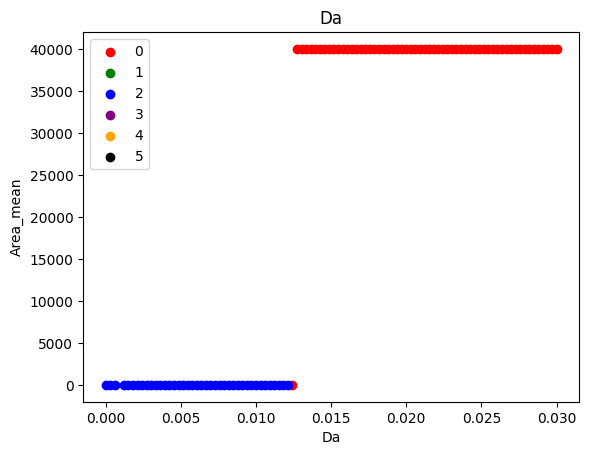

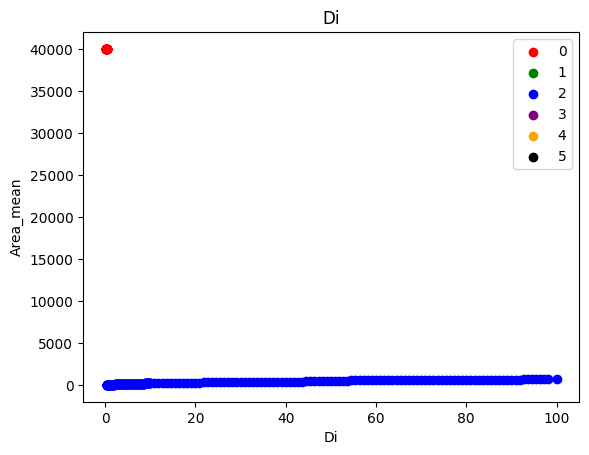

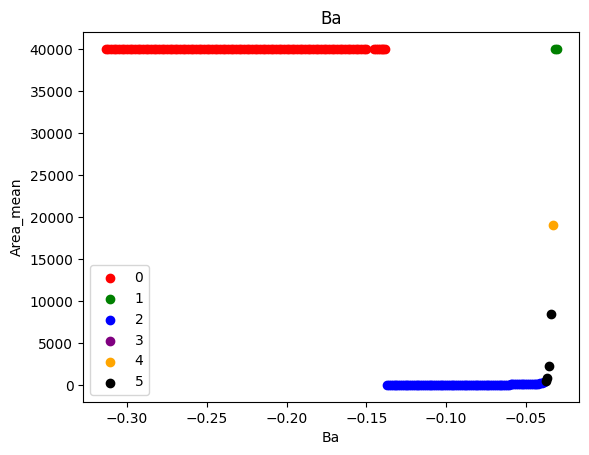

In [ ]:
# plot some dependencies

keys = list(single_classes.keys())
# feat_1 = "Ua"
feat_2 = "Area_mean"

# iterate through params
for i in range(7):
  fig, ax = plt.subplots()
  # iterate through classes
  for j in range(6):

    # pull up the dataframe for the specific class
    df = single_classes[keys[i]]
    df = df[df["pred_class"] == j]
    df.reset_index(inplace = True, drop = True)


    x = df[keys[i]].astype(float)
    y = df[feat_2].astype(float)

    ax.scatter(x,y, color = colors[j])
  ax.legend([0,1,2,3,4,5,6])
  ax.set(title = keys[i], xlabel = keys[i], ylabel = feat_2)
  plt.show()


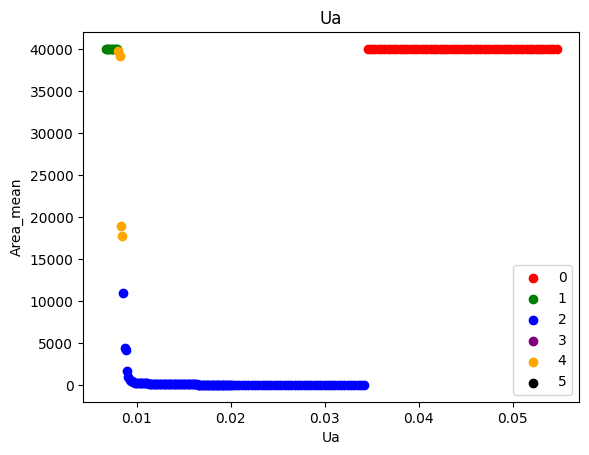

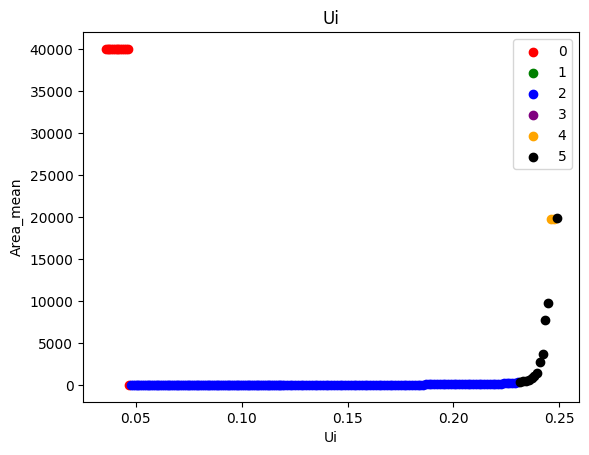

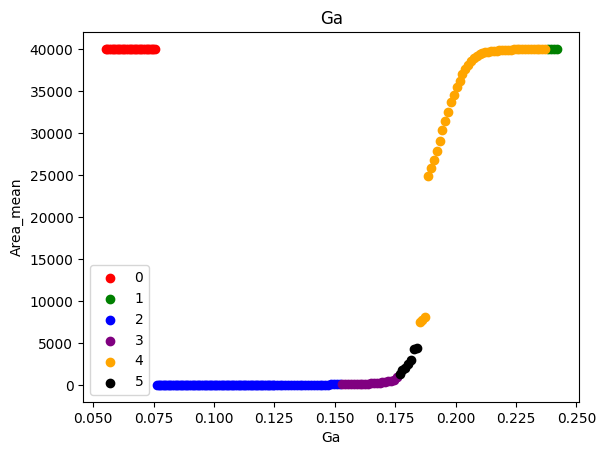

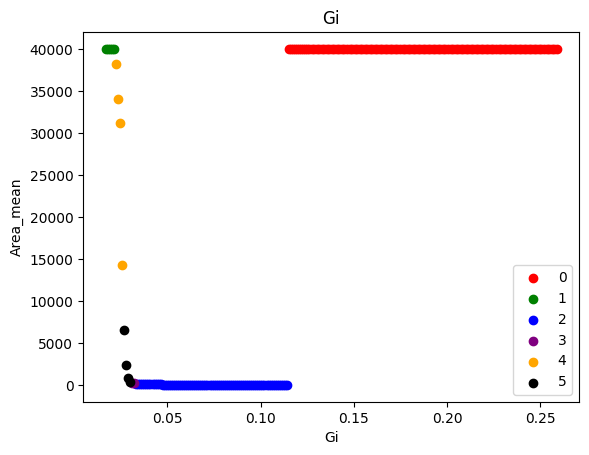

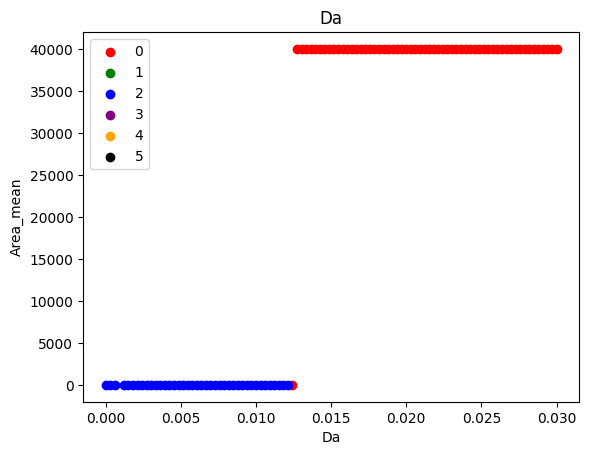

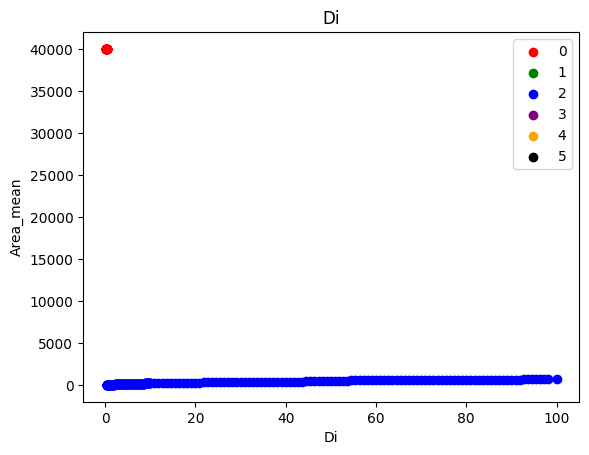

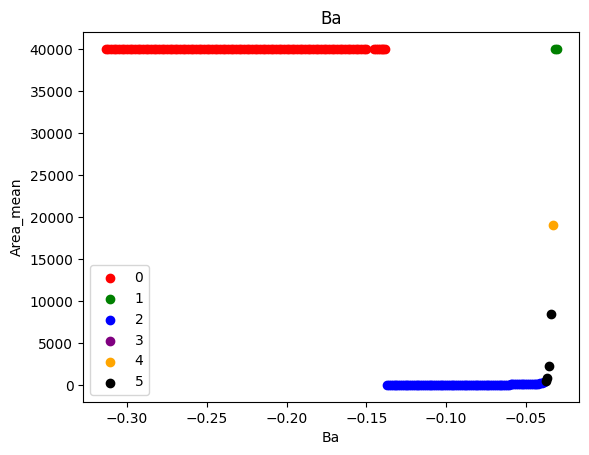

In [ ]:
# plot some dependencies

keys = list(single_classes.keys())
# feat_1 = "Ua"
feat_2 = "Area_mean"

# iterate through params
for i in range(7):
  fig, ax = plt.subplots()
  # iterate through classes
  for j in range(6):

    # pull up the dataframe for the specific class
    df = single_classes[keys[i]]
    df = df[df["pred_class"] == j]
    df.reset_index(inplace = True, drop = True)


    x = df[keys[i]].astype(float)
    y = df[feat_2].astype(float)

    ax.scatter(x,y, color = colors[j])
  ax.legend([0,1,2,3,4,5,6])
  ax.set(title = keys[i], xlabel = keys[i], ylabel = feat_2)
  plt.show()


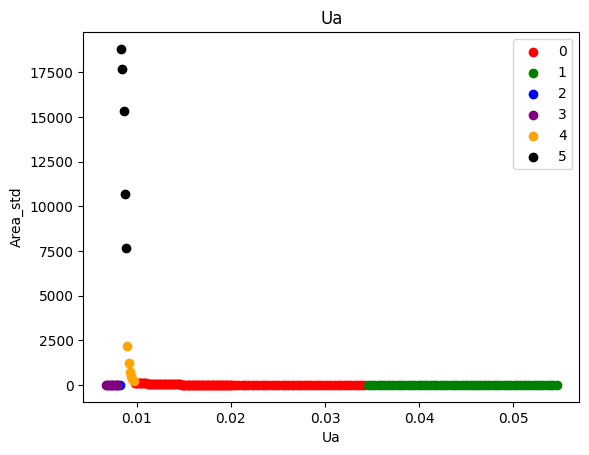

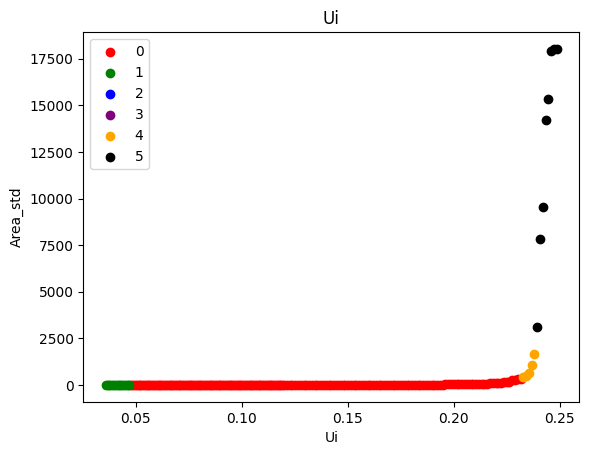

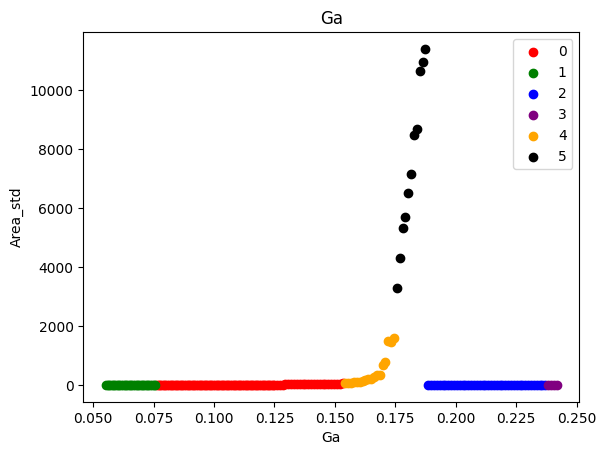

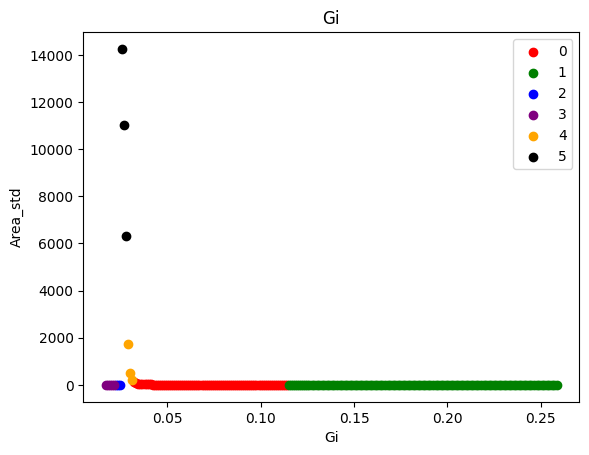

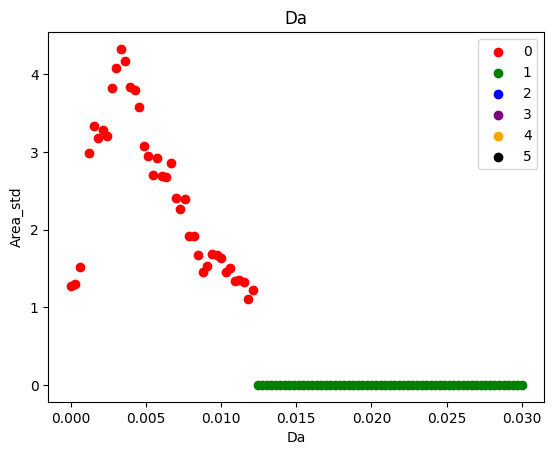

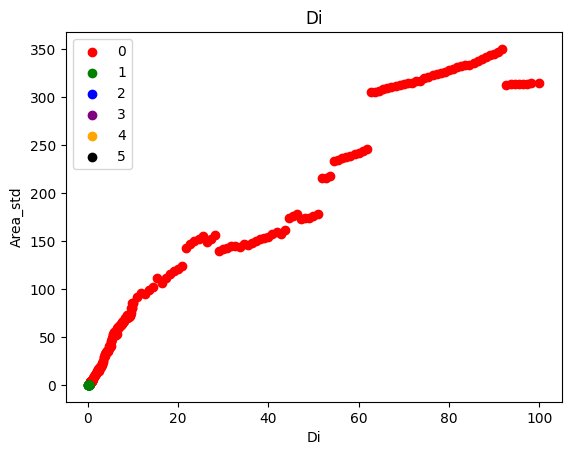

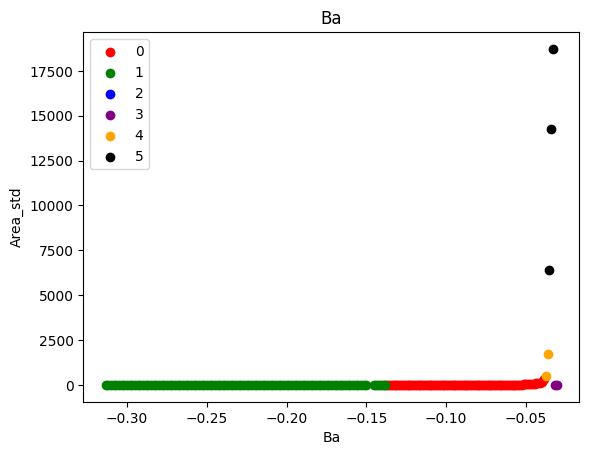

In [ ]:
# plot some dependencies

keys = list(single_classes.keys())
# feat_1 = "Ua"
feat_2 = "Area_std"

# iterate through params
for i in range(7):
  fig, ax = plt.subplots()
  # iterate through classes
  for j in range(6):

    # pull up the dataframe for the specific class
    df = single_classes[keys[i]]
    df = df[df["cluster"] == j]
    df.reset_index(inplace = True, drop = True)


    x = df[keys[i]].astype(float)
    y = df[feat_2].astype(float)

    ax.scatter(x,y, color = colors[j])
  ax.legend([0,1,2,3,4,5,6])
  ax.set(title = keys[i], xlabel = keys[i], ylabel = feat_2)
  plt.show()


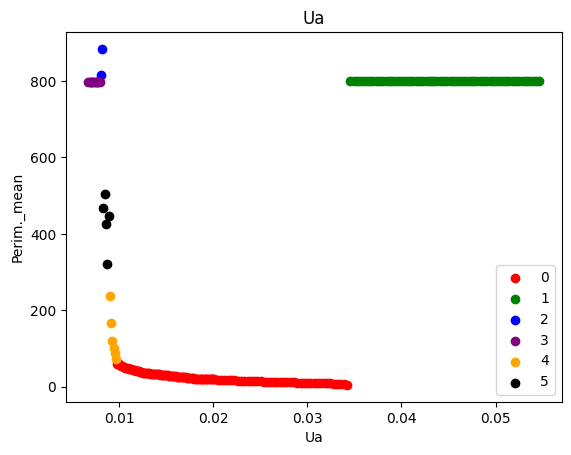

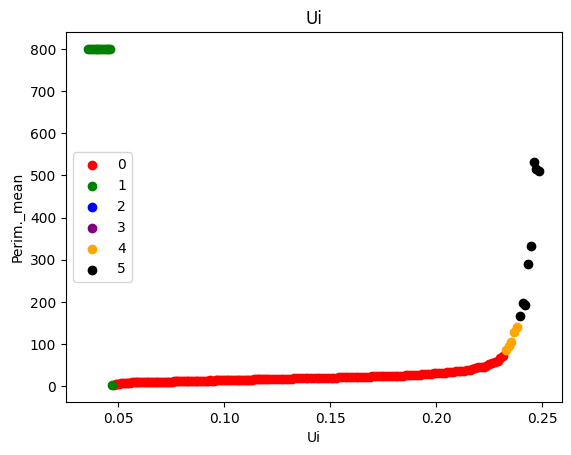

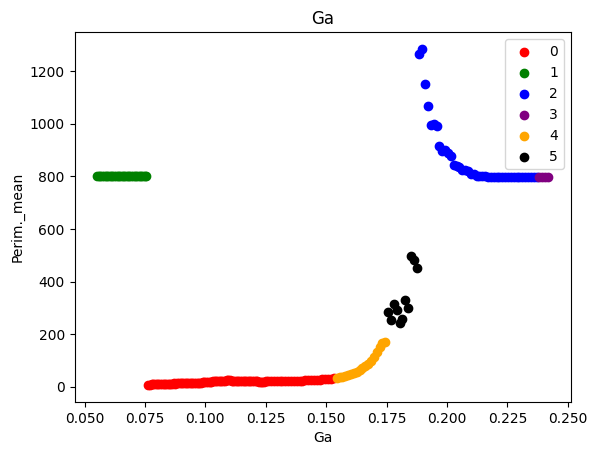

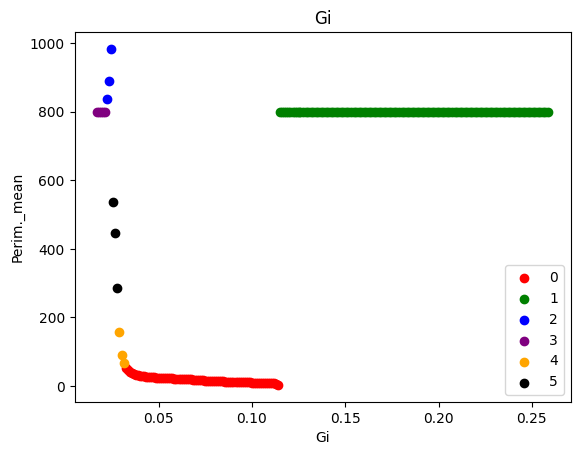

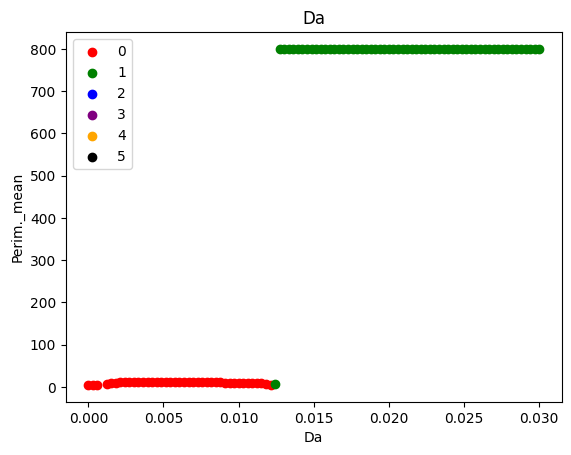

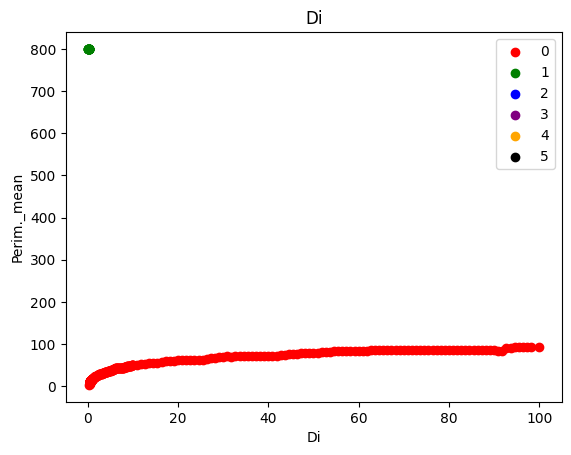

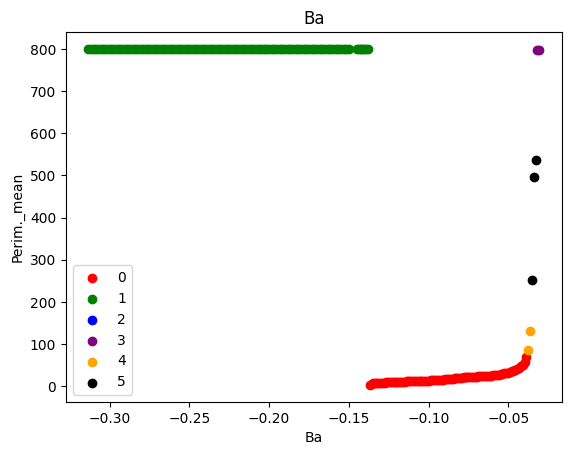

In [ ]:
# plot some dependencies

keys = list(single_classes.keys())
# feat_1 = "Ua"
feat_2 = "Perim._mean"

# iterate through params
for i in range(7):
  fig, ax = plt.subplots()
  # iterate through classes
  for j in range(6):

    # pull up the dataframe for the specific class
    df = single_classes[keys[i]]
    df = df[df["cluster"] == j]
    df.reset_index(inplace = True, drop = True)


    x = df[keys[i]].astype(float)
    y = df[feat_2].astype(float)

    ax.scatter(x,y, color = colors[j])
  ax.legend([0,1,2,3,4,5,6])
  ax.set(title = keys[i], xlabel = keys[i], ylabel = feat_2)
  plt.show()
